<a href="https://colab.research.google.com/github/anfalear/notasestinferencial/blob/main/Mision2_ProcessMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Misión 2 - Process Mining**

Análisis de datos Intermedio
Talento Tech Bucaramanga

Integrantes:



Andrés Fabián Leal Archila





# **Ejercicio 1: Caso HELP DESK simulado**

Introducción: Análisis de Procesos con PM4Py - Caso Help Desk

Objetivo del taller: Este taller tiene como propósito simular un proceso realista, que se analiza usando técnicas de minería de procesos identificando patrones, anomalías, cuellos de botella y la generación propuestas de mejora con base en datos.
Contexto del caso: Una empresa tiene un sistema de mesa de ayuda que recibe tickets de soporte técnico. Estos tickets atraviesan distintas etapas: recepción, diagnóstico, resolución, o en algunos casos, escalamiento o cancelación. Se trabajará con un registro simulado de 1000 casos (trazas), y deberá analizarlo con PM4Py en Python.

Metodología:

Preparación del entorno: Para la preparación del entorno se seguirán las siguientes instrucciones:
Instalar PM4Py y bibliotecas necesarias.
Ejecutar el código de simulación, lo cual se realiza en la siguiente celda donde se obtienen las simulaciones y las gráficas solicitadas.


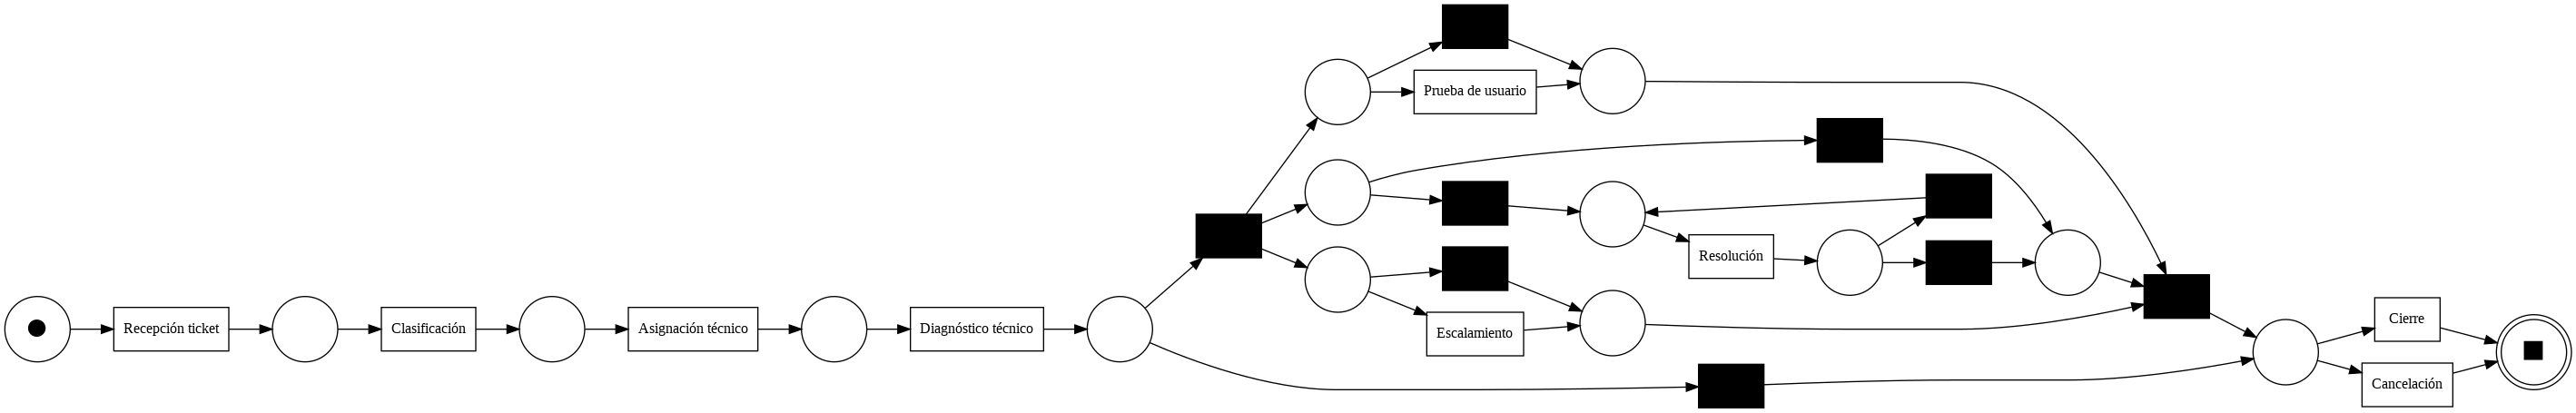

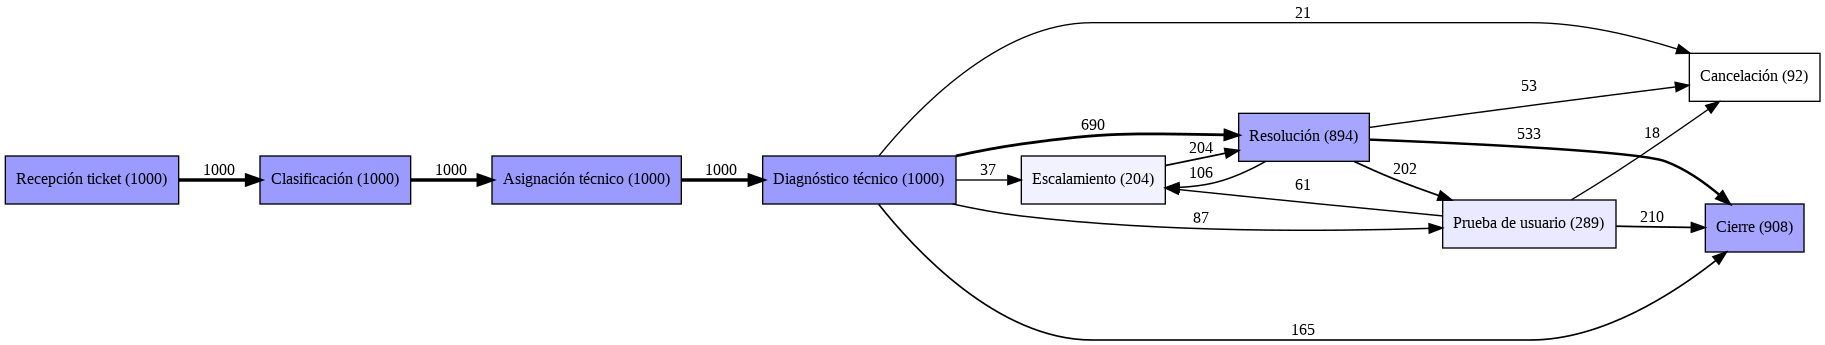


📊 Estadísticas del proceso Help Desk:

1. Actividades de inicio: {'Recepción ticket': 1000}
2. Actividades de fin: {'Cierre': 908, 'Cancelación': 92}
3. Total de tickets: 1000
4. Frecuencia de actividades:
   - Recepción ticket: 1000
   - Clasificación: 1000
   - Asignación técnico: 1000
   - Diagnóstico técnico: 1000
   - Cierre: 908
   - Resolución: 894
   - Prueba de usuario: 289
   - Escalamiento: 204
   - Cancelación: 92

5. Principales variantes:
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Resolución', 'Cierre'): 329 tickets
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Cierre'): 165 tickets
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Resolución', 'Prueba de usuario', 'Cierre'): 147 tickets
   - ('Recepción ticket', 'Clasificación', 'Asignación técnico', 'Diagnóstico técnico', 'Resolución', 'Escalamiento', 'Resolución', 'Cierre'): 106 tickets
   - 

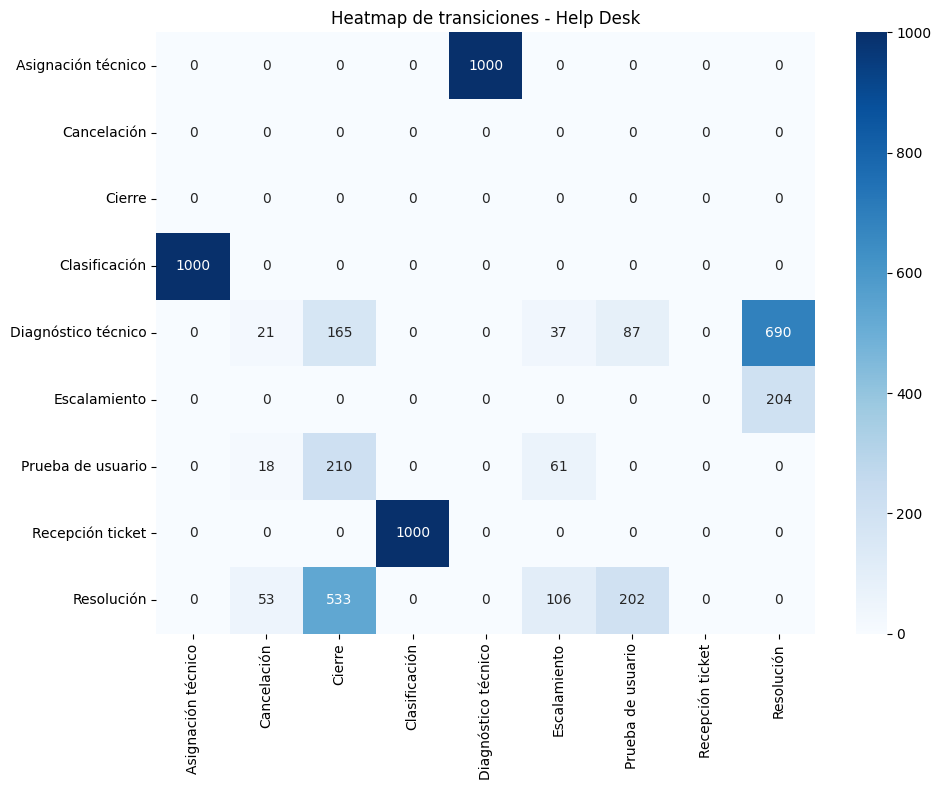

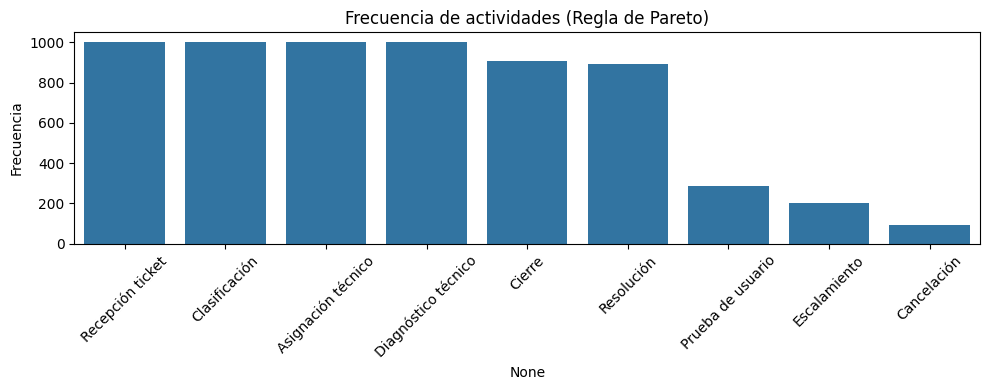

In [ ]:
!pip install pm4py

import pandas as pd
import random
from datetime import datetime, timedelta
from pm4py.convert import convert_to_event_log
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_vis
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.statistics.start_activities.log.get import get_start_activities
from pm4py.statistics.end_activities.log.get import get_end_activities
from pm4py.statistics.traces.generic.log import case_statistics
from pm4py.statistics.attributes.log import get as attr_stats
from pm4py.algo.discovery.dfg import algorithm as dfg
from pm4py.visualization.dfg import visualizer as dfg_vis

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter

# ---------------------------
# PARTE 1: Simulación del proceso
# ---------------------------

n_cases = 1000
start_date = datetime(2025, 1, 1)

activities = [
    "Recepción ticket",
    "Clasificación",
    "Asignación técnico",
    "Diagnóstico técnico",
    "Resolución",
    "Prueba de usuario",
    "Cierre",
    "Escalamiento",
    "Cancelación"
]

data = []
for i in range(n_cases):
    case_id = f"Ticket_{i+1}"
    current_time = start_date
    trace = ["Recepción ticket", "Clasificación", "Asignación técnico", "Diagnóstico técnico"]

    if random.random() < 0.7:
        trace.append("Resolución")

    if random.random() < 0.3:
        trace.append("Prueba de usuario")

    # Decisión de finalización
    if random.random() < 0.1:
        trace.append("Cancelación")
    elif random.random() < 0.2:
        trace.append("Escalamiento")
        trace.append("Resolución")
        trace.append("Cierre")
    else:
        trace.append("Cierre")

    for activity in trace:
        data.append([case_id, activity, current_time])
        current_time += timedelta(minutes=random.randint(10, 60))

df = pd.DataFrame(data, columns=["case:concept:name", "concept:name", "time:timestamp"])
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

# ---------------------------
# PARTE 2: Procesamiento con PM4Py
# ---------------------------
log = convert_to_event_log(df)

# Modelo con Inductive Miner
tree = inductive_miner.apply(log)
net, im, fm = pt_converter.apply(tree)
pn_vis.view(pn_vis.apply(net, im, fm))

# DFG
dfg_result = dfg.apply(log)
dfg_vis.view(dfg_vis.apply(dfg_result, log=log))

# ---------------------------
# PARTE 3: Estadísticas del proceso
# ---------------------------
print("\n📊 Estadísticas del proceso Help Desk:\n")
print("1. Actividades de inicio:", get_start_activities(log))
print("2. Actividades de fin:", get_end_activities(log))
print("3. Total de tickets:", len(log))

activity_freq = attr_stats.get_attribute_values(log, "concept:name")
print("4. Frecuencia de actividades:")
for act, freq in sorted(activity_freq.items(), key=lambda x: -x[1]):
    print(f"   - {act}: {freq}")

variants = case_statistics.get_variant_statistics(log)
print("\n5. Principales variantes:")
for var in sorted(variants, key=lambda x: x['count'], reverse=True)[:5]:
    print(f"   - {var['variant']}: {var['count']} tickets")

# Casos largos, cortos y promedio
case_descriptions = case_statistics.get_cases_description(log)
desc_df = pd.DataFrame([
    {"case_id": cid, "duration_sec": d.get("caseDuration", 0)}
    for cid, d in case_descriptions.items()
])
desc_df["events"] = df.groupby("case:concept:name").size().values
desc_df["duration_min"] = desc_df["duration_sec"] / 60

print("\n6. Ticket más largo:", desc_df.sort_values(by="events", ascending=False).iloc[0].to_dict())
print("7. Ticket más corto:", desc_df.sort_values(by="events", ascending=True).iloc[0].to_dict())
print(f"8. Promedio de eventos por ticket: {desc_df['events'].mean():.2f}")

# Escalamiento y cancelación
escalados = [t.attributes["concept:name"] for t in log if any(e["concept:name"] == "Escalamiento" for e in t)]
cancelados = [t.attributes["concept:name"] for t in log if any(e["concept:name"] == "Cancelación" for e in t)]
print(f"9. Tickets escalados: {len(escalados)} ({len(escalados)/n_cases*100:.1f}%)")
print(f"10. Tickets cancelados: {len(cancelados)} ({len(cancelados)/n_cases*100:.1f}%)")

# ---------------------------
# PARTE 4: Visualizaciones
# ---------------------------

# Diagrama de Gantt
gantt_data = []
for trace in log[:5]:
    cid = trace.attributes["concept:name"]
    for i in range(len(trace)):
        start = trace[i]["time:timestamp"]
        end = trace[i+1]["time:timestamp"] if i+1 < len(trace) else start + timedelta(minutes=30)
        gantt_data.append({"Task": cid, "Activity": trace[i]["concept:name"], "Start": start, "Finish": end})
gantt_df = pd.DataFrame(gantt_data)
fig = px.timeline(gantt_df, x_start="Start", x_end="Finish", y="Task", color="Activity",
                  title="Diagrama de Gantt - Primeros 5 Tickets")
fig.update_yaxes(autorange="reversed")
fig.show()

# Heatmap de transiciones
transitions = Counter()
for trace in log:
    for i in range(len(trace) - 1):
        a1, a2 = trace[i]["concept:name"], trace[i+1]["concept:name"]
        transitions[(a1, a2)] += 1
act_set = sorted(set([a for a, b in transitions] + [b for a, b in transitions]))
matrix = pd.DataFrame(0, index=act_set, columns=act_set)
for (a1, a2), count in transitions.items():
    matrix.loc[a1, a2] = count
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Heatmap de transiciones - Help Desk")
plt.tight_layout()
plt.show()

# Pareto
act_df = pd.DataFrame.from_dict(activity_freq, orient="index", columns=["Frecuencia"])
act_df = act_df.sort_values(by="Frecuencia", ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(x=act_df.index, y=act_df["Frecuencia"])
plt.title("Frecuencia de actividades (Regla de Pareto)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Guardar CSV
df.to_csv('helpdesk_process_log.csv', index=False)



# Parte 1: Análisis del Log

Objetivo:

Entender cómo se componen las trazas simuladas.



1.   ¿Cuántos casos (tickets) hay en total?

2. ¿Qué actividades se repiten en la mayoría de los casos?

3. ¿Qué porcentaje de casos contiene la actividad "Escalamiento"?

4. ¿Cuántos casos finalizan en Cierre? ¿Cuántos casos finalizan en Cancelación? ¿Cuántos casos finalizan en Escalamiento seguido de cierre?

5. ¿Cuál es la actividad que más veces se repite en un mismo caso?




In [ ]:
# Análisis de Process Mining
from collections import Counter, defaultdict

def analyze_process_log(log):
    """
    Análisis completo del log de procesos
    """
    print("=" * 60)
    print("ANÁLISIS DE PROCESS MINING: Parte 1: Análisis del LOG")
    print("=" * 60)

    # Pregunta 1: Total de casos
    print("\n1. ¿Cuántos casos (tickets) hay en total?")
    total_cases = len(log)
    print(f"   Total de tickets: {total_cases}")

    print("-" * 50)

    # Pregunta 2: Actividades más repetidas
    print("\n2. ¿Qué actividades se repiten en la mayoría de los casos?")

    # Contar todas las actividades
    all_activities = []
    for trace in log:
        all_activities.extend([event["concept:name"] for event in trace])

    activity_freq = Counter(all_activities)

    print("\nFrecuencia de actividades (ordenada):")
    for activity, freq in activity_freq.most_common():
        print(f"   - {activity}: {freq}")

    # Actividades con mayor frecuencia
    max_freq = max(activity_freq.values())
    most_frequent = [act for act, freq in activity_freq.items() if freq == max_freq]

    print(f"\nActividades más repetidas (frecuencia: {max_freq}):")
    for activity in most_frequent:
        print(f"   - {activity}")

    print("-" * 50)

    # Pregunta 3: Porcentaje de casos con "Escalamiento"
    print("\n3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?")

    escalamiento_cases = sum(1 for trace in log
                           if any(event["concept:name"] == "Escalamiento" for event in trace))

    escalamiento_percentage = (escalamiento_cases / total_cases) * 100
    print(f"   Casos con 'Escalamiento': {escalamiento_cases} ({escalamiento_percentage:.1f}%)")

    print("-" * 50)

    # Pregunta 4: Análisis de finalización de casos
    print("\n4. Análisis de finalización de casos:")

    # Contar actividades finales
    end_activities = Counter(trace[-1]["concept:name"] for trace in log)

    cierre_count = end_activities.get("Cierre", 0)
    cancelacion_count = end_activities.get("Cancelación", 0)

    print(f"   - Casos que finalizan en 'Cierre': {cierre_count}")
    print(f"   - Casos que finalizan en 'Cancelación': {cancelacion_count}")

    # Contar "Escalamiento" seguido de "Cierre"
    escalamiento_cierre = 0
    for trace in log:
        activities = [event["concept:name"] for event in trace]
        for i in range(len(activities) - 1):
            if activities[i] == "Escalamiento" and activities[i + 1] == "Cierre":
                escalamiento_cierre += 1
                break  # Solo contar una vez por caso

    print(f"   - Casos con 'Escalamiento' seguido de 'Cierre': {escalamiento_cierre}")

    print("-" * 50)

    # Pregunta 5: Actividad que más se repite en un mismo caso
    print("\n5. ¿Cuál es la actividad que más veces se repite en un mismo caso?")

    max_repetitions_per_case = {}

    for trace in log:
        # Contar actividades en este caso específico
        case_activities = Counter(event["concept:name"] for event in trace)

        # Encontrar la actividad más repetida en este caso
        most_repeated_activity = case_activities.most_common(1)[0]
        activity_name, count = most_repeated_activity

        # Actualizar el máximo global si es necesario
        if activity_name not in max_repetitions_per_case:
            max_repetitions_per_case[activity_name] = count
        else:
            max_repetitions_per_case[activity_name] = max(
                max_repetitions_per_case[activity_name], count
            )

    # Encontrar la actividad con mayor repetición máxima
    max_repetition_count = max(max_repetitions_per_case.values())
    most_repeated_activities = [
        act for act, count in max_repetitions_per_case.items()
        if count == max_repetition_count
    ]

    print(f"   Máximo de repeticiones en un caso: {max_repetition_count}")
    print("   Actividades que alcanzan este máximo:")
    for activity in most_repeated_activities:
        print(f"   - {activity}")

    # Información adicional útil
    print("\n" + "-" * 50)
    print("INFORMACIÓN ADICIONAL:")
    print(f"   - Actividades únicas en el log: {len(activity_freq)}")
    print(f"   - Promedio de eventos por caso: {len(all_activities) / total_cases:.1f}")

    # Mostrar distribución de longitudes de casos
    case_lengths = [len(trace) for trace in log]
    print(f"   - Caso más corto: {min(case_lengths)} eventos")
    print(f"   - Caso más largo: {max(case_lengths)} eventos")
    print(f"   - Longitud promedio: {sum(case_lengths) / len(case_lengths):.1f} eventos")

# Ejemplo de uso (descomenta si tienes el log cargado):
analyze_process_log(log)

ANÁLISIS DE PROCESS MINING: Parte 1: Análisis del LOG

1. ¿Cuántos casos (tickets) hay en total?
   Total de tickets: 1000
--------------------------------------------------

2. ¿Qué actividades se repiten en la mayoría de los casos?

Frecuencia de actividades (ordenada):
   - Recepción ticket: 1000
   - Clasificación: 1000
   - Asignación técnico: 1000
   - Diagnóstico técnico: 1000
   - Cierre: 908
   - Resolución: 894
   - Prueba de usuario: 289
   - Escalamiento: 204
   - Cancelación: 92

Actividades más repetidas (frecuencia: 1000):
   - Recepción ticket
   - Clasificación
   - Asignación técnico
   - Diagnóstico técnico
--------------------------------------------------

3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?
   Casos con 'Escalamiento': 204 (20.4%)
--------------------------------------------------

4. Análisis de finalización de casos:
   - Casos que finalizan en 'Cierre': 908
   - Casos que finalizan en 'Cancelación': 92
   - Casos con 'Escalamiento'

6. ¿Cuáles son las 3 variantes más frecuentes?:

#  Parte 2: Análisis de variantes de proceso
Objetivo:

Identificar patrones comunes y desviaciones.

In [ ]:
from datetime import timedelta
from collections import Counter, defaultdict

def analyze_variants_manual(log):
    """
    Análisis de variantes sin dependencias específicas de PM4Py
    """

    print("=" * 60)
    print("Parte 2: Análisis de variantes de proceso")
    print("=" * 60)

    # Extraer variantes manualmente
    variants_dict = {}

    for trace in log:
        # Crear tupla de actividades para esta traza
        activities = tuple(event['concept:name'] for event in trace)

        if activities not in variants_dict:
            variants_dict[activities] = []
        variants_dict[activities].append(trace)

    # Convertir a formato con conteos
    variant_counts = []
    for variant_tuple, traces in variants_dict.items():
        variant_counts.append({
            'variant': variant_tuple,
            'count': len(traces),
            'traces': traces
        })

    # Ordenar por frecuencia
    sorted_variants = sorted(variant_counts, key=lambda x: x['count'], reverse=True)

    print(f"Total de variantes encontradas: {len(variant_counts)}")
    print(f"Total de casos en el log: {len(log)}")

    # Pregunta 6: 3 variantes más frecuentes
    print("\n6. ¿Cuáles son las 3 variantes más frecuentes?")

    top_3_variants = sorted_variants[:3]

    print("\nLas 3 variantes más frecuentes son:")
    for i, var_info in enumerate(top_3_variants, 1):
        variant_activities = " → ".join(var_info['variant'])
        print(f"   {i}. {variant_activities}")
        print(f"      Frecuencia: {var_info['count']} tickets ({var_info['count']/len(log)*100:.1f}%)")

    print("-" * 50)

    # Pregunta 7: Diferencias entre variantes
    print("\n7. ¿Cuál es la diferencia entre estas variantes?")

    if len(top_3_variants) >= 3:
        print("\nAnálisis detallado de diferencias:")

        # Comparar cada par de variantes
        comparisons = [(0, 1), (0, 2), (1, 2)]
        comparison_names = [("Primera", "Segunda"), ("Primera", "Tercera"), ("Segunda", "Tercera")]

        for (i, j), (name_i, name_j) in zip(comparisons, comparison_names):
            var1 = list(top_3_variants[i]['variant'])
            var2 = list(top_3_variants[j]['variant'])

            print(f"\n {name_i} variante vs {name_j} variante:")
            print(f"   {name_i}: {' → '.join(var1)}")
            print(f"   {name_j}: {' → '.join(var2)}")

            # Encontrar diferencias
            set1, set2 = set(var1), set(var2)
            only_in_var1 = set1 - set2
            only_in_var2 = set2 - set1
            common = set1 & set2

            if only_in_var1:
                print(f"   • Solo en {name_i}: {', '.join(only_in_var1)}")
            if only_in_var2:
                print(f"   • Solo en {name_j}: {', '.join(only_in_var2)}")

            # Analizar orden si tienen las mismas actividades
            if not only_in_var1 and not only_in_var2:
                if var1 == var2:
                    print("   •  Variantes idénticas")
                else:
                    print("   •  Mismas actividades, diferente orden")
                    # Mostrar diferencias de posición
                    for k, (act1, act2) in enumerate(zip(var1, var2)):
                        if act1 != act2:
                            print(f"     - Posición {k+1}: '{act1}' vs '{act2}'")

            print(f"   • Actividades comunes: {len(common)}/{max(len(var1), len(var2))}")

    print("-" * 50)

    # Pregunta 8: Variantes con más pasos
    print("\n8. ¿Alguna variante contiene más pasos que otras? ¿Por qué?")

    print("\nAnálisis de longitud de variantes:")
    variant_lengths = []

    for i, var_info in enumerate(top_3_variants, 1):
        length = len(var_info['variant'])
        variant_lengths.append((i, length, var_info['count']))
        activities = " → ".join(var_info['variant'])
        print(f"   Variante {i}: {length} pasos")
        print(f"   ({activities})")
        print(f"   Frecuencia: {var_info['count']} casos\n")

    # Estadísticas de longitud
    lengths = [x[1] for x in variant_lengths]
    min_length, max_length = min(lengths), max(lengths)
    avg_length = sum(lengths) / len(lengths)

    print(f" Estadísticas de longitud:")
    print(f"   • Mínimo: {min_length} pasos")
    print(f"   • Máximo: {max_length} pasos")
    print(f"   • Promedio: {avg_length:.1f} pasos")

    if max_length > min_length:
        longest_variants = [x for x in variant_lengths if x[1] == max_length]
        shortest_variants = [x for x in variant_lengths if x[1] == min_length]

        print(f"\n Explicación de las diferencias:")
        print(f"   • Variante(s) más larga(s): {[f'Variante {x[0]}' for x in longest_variants]} ({max_length} pasos)")
        print(f"   • Variante(s) más corta(s): {[f'Variante {x[0]}' for x in shortest_variants]} ({min_length} pasos)")
        print(f"   • Diferencia: {max_length - min_length} pasos adicionales")

        print("\n Razones de las diferencias:")
        print("   • Caminos alternativos: algunos casos siguen rutas más complejas")
        print("   • Actividades opcionales: pruebas adicionales, validaciones")
        print("   • Escalamientos: casos que requieren intervención especializada")
        print("   • Puntos de decisión: diferentes criterios de finalización")

    print("-" * 50)

    # Pregunta 9: Tiempo promedio de duración
    print("\n9. ¿Cuál es el tiempo promedio de duración de estas 3 variantes?")

    variant_durations = calculate_variant_durations_manual(top_3_variants)

    print("\nTiempos promedio por variante:")
    for i, (var_info, duration_info) in enumerate(zip(top_3_variants, variant_durations), 1):
        activities = " → ".join(var_info['variant'])
        print(f"\n   Variante {i}:")
        print(f"   {activities}")

        if duration_info['avg_minutes'] is not None:
            print(f"     Duración promedio: {duration_info['avg_minutes']:.1f} minutos")
            print(f"    Casos analizados: {duration_info['count']}")
            if duration_info['min_minutes'] is not None and duration_info['max_minutes'] is not None:
                print(f"    Rango: {duration_info['min_minutes']:.1f} - {duration_info['max_minutes']:.1f} minutos")
        else:
            print("    No se pudieron calcular los tiempos (faltan timestamps)")

    print("-" * 50)

    # Pregunta 10: Análisis de cancelaciones
    print("\n10. ¿Qué se puede decir de las variantes con cancelación?")

    analyze_cancellation_variants_manual(variant_counts, len(log))

    print("=" * 60)


def calculate_variant_durations_manual(top_variants):
    """
    Calcula duraciones manualmente sin dependencias externas
    """
    durations = []

    for var_info in top_variants:
        total_seconds = 0
        valid_count = 0
        min_duration = float('inf')
        max_duration = 0

        for trace in var_info['traces']:
            try:
                start_time = trace[0]['time:timestamp']
                end_time = trace[-1]['time:timestamp']

                # Calcular duración
                if hasattr(start_time, 'timestamp') and hasattr(end_time, 'timestamp'):
                    # Si son objetos datetime
                    duration_seconds = (end_time - start_time).total_seconds()
                else:
                    # Si son strings, intentar parsear
                    from datetime import datetime
                    if isinstance(start_time, str):
                        start_time = datetime.fromisoformat(start_time.replace('Z', '+00:00'))
                    if isinstance(end_time, str):
                        end_time = datetime.fromisoformat(end_time.replace('Z', '+00:00'))
                    duration_seconds = (end_time - start_time).total_seconds()

                duration_minutes = duration_seconds / 60
                total_seconds += duration_seconds
                valid_count += 1

                min_duration = min(min_duration, duration_minutes)
                max_duration = max(max_duration, duration_minutes)

            except (KeyError, IndexError, ValueError, TypeError):
                continue

        if valid_count > 0:
            avg_minutes = total_seconds / 60 / valid_count
            durations.append({
                'avg_minutes': avg_minutes,
                'count': valid_count,
                'min_minutes': min_duration,
                'max_minutes': max_duration
            })
        else:
            durations.append({
                'avg_minutes': None,
                'count': 0,
                'min_minutes': None,
                'max_minutes': None
            })

    return durations


def analyze_cancellation_variants_manual(all_variants, total_cases):
    """
    Análisis manual de variantes con cancelación
    """
    # Filtrar variantes con cancelación
    cancellation_variants = [
        var for var in all_variants
        if "Cancelación" in var["variant"]
    ]

    if not cancellation_variants:
        print(" No se encontraron variantes con cancelación.")
        return

    total_cancelled = sum(var["count"] for var in cancellation_variants)
    cancellation_percentage = (total_cancelled / total_cases) * 100

    print(f"\n Resumen general de cancelaciones:")
    print(f"   • Total de casos cancelados: {total_cancelled}")
    print(f"   • Porcentaje del total: {cancellation_percentage:.1f}%")
    print(f"   • Variantes con cancelación: {len(cancellation_variants)}")

    # Analizar actividades que preceden a cancelación
    print(f"\n ¿Qué actividades preceden a la cancelación?")

    preceding_activities = defaultdict(int)
    cancellation_positions = defaultdict(int)

    for var in cancellation_variants:
        variant_sequence = var["variant"]
        for i, activity in enumerate(variant_sequence):
            if activity == "Cancelación":
                # Registrar posición de cancelación
                cancellation_positions[i] += var["count"]

                # Registrar actividad previa (si existe)
                if i > 0:
                    preceding_activity = variant_sequence[i - 1]
                    preceding_activities[preceding_activity] += var["count"]
                else:
                    preceding_activities["[INICIO]"] += var["count"]
                break

    print("   Actividades previas a cancelación:")
    for activity, count in sorted(preceding_activities.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / total_cancelled) * 100
        print(f"   • {activity}: {count} casos ({percentage:.1f}%)")

    # Analizar en qué paso ocurren las cancelaciones
    print(f"\n ¿En qué paso del proceso ocurren las cancelaciones?")
    for position, count in sorted(cancellation_positions.items()):
        percentage = (count / total_cancelled) * 100
        step_name = "inicial" if position == 0 else f"paso {position + 1}"
        print(f"   • Cancelación en {step_name}: {count} casos ({percentage:.1f}%)")

    # Mostrar las variantes de cancelación más frecuentes
    print(f"\n Top 5 variantes de cancelación:")
    sorted_cancellations = sorted(cancellation_variants, key=lambda x: x['count'], reverse=True)

    for i, var in enumerate(sorted_cancellations[:5], 1):
        activities = " → ".join(var['variant'])
        percentage = (var['count'] / total_cancelled) * 100
        print(f"   {i}. {activities}")
        print(f"      {var['count']} casos ({percentage:.1f}% de cancelaciones)")

    # Análisis de patrones
    print(f"\n Patrones identificados:")

    # Cancelaciones tempranas vs tardías
    early_threshold = 3
    early_cancellations = sum(
        var["count"] for var in cancellation_variants
        if len(var["variant"]) <= early_threshold
    )
    late_cancellations = total_cancelled - early_cancellations

    print(f"   • Cancelaciones tempranas (≤{early_threshold} pasos): {early_cancellations} ({early_cancellations/total_cancelled*100:.1f}%)")
    print(f"   • Cancelaciones tardías (>{early_threshold} pasos): {late_cancellations} ({late_cancellations/total_cancelled*100:.1f}%)")

    # Cancelaciones con escalamiento
    escalated_cancellations = sum(
        var["count"] for var in cancellation_variants
        if "Escalamiento" in var["variant"]
    )

    if escalated_cancellations > 0:
        print(f"   • Casos escalados que terminan en cancelación: {escalated_cancellations}")
        print(f"     ({escalated_cancellations/total_cancelled*100:.1f}% de las cancelaciones)")
        print("      Esto podría indicar problemas en el proceso de escalamiento")

    # Cancelaciones después de resolución (casos problemáticos)
    resolution_cancellations = sum(
        var["count"] for var in cancellation_variants
        if "Resolución" in var["variant"]
    )

    if resolution_cancellations > 0:
        print(f"   • Cancelaciones después de resolución: {resolution_cancellations}")
        print(f"     ({resolution_cancellations/total_cancelled*100:.1f}% de las cancelaciones)")
        print("      Casos que se resolvieron pero luego se cancelaron")


# Ejemplo de uso:
analyze_variants_manual(log)

Parte 2: Análisis de variantes de proceso
Total de variantes encontradas: 12
Total de casos en el log: 1000

6. ¿Cuáles son las 3 variantes más frecuentes?

Las 3 variantes más frecuentes son:
   1. Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Resolución → Cierre
      Frecuencia: 329 tickets (32.9%)
   2. Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Cierre
      Frecuencia: 165 tickets (16.5%)
   3. Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Resolución → Prueba de usuario → Cierre
      Frecuencia: 147 tickets (14.7%)
--------------------------------------------------

7. ¿Cuál es la diferencia entre estas variantes?

Análisis detallado de diferencias:

 Primera variante vs Segunda variante:
   Primera: Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico → Resolución → Cierre
   Segunda: Recepción ticket → Clasificación → Asignación técnico → Diagnóstico técnico

# Parte 3: Detección de cuellos de botella
Objetivo:

Detectar los pasos del proceso donde se acumulan tiempos.

In [ ]:
print("=" * 60)
print("Parte 3: Detección de cuellos de botella")
print("=" * 60)

# ===================================================================
# PREGUNTA 11: ¿Cuál es el par de actividades con mayor duración promedio?
# ===================================================================
print("\n11. ¿Cuál es el par de actividades con mayor duración promedio?")

# Calcular el tiempo entre cada par de actividades consecutivas
activity_durations = {}

for trace in log:
    for i in range(len(trace) - 1):
        act1 = trace[i]['concept:name']
        act2 = trace[i+1]['concept:name']
        time1 = trace[i]['time:timestamp']
        time2 = trace[i+1]['time:timestamp']
        pair = (act1, act2)
        duration = (time2 - time1).total_seconds() / 60  # Duración en minutos

        if pair not in activity_durations:
            activity_durations[pair] = []
        activity_durations[pair].append(duration)

# Calcular la duración promedio para cada par
average_activity_durations = {}
for pair, durations in activity_durations.items():
    average_activity_durations[pair] = sum(durations) / len(durations)

# Encontrar el par con la mayor duración promedio
max_duration_pair = max(average_activity_durations, key=average_activity_durations.get)
max_average_duration = average_activity_durations[max_duration_pair]

print(f"\n El par de actividades con mayor duración promedio es:")
print(f"   '{max_duration_pair[0]}' → '{max_duration_pair[1]}'")
print(f"   Duración promedio: {max_average_duration:.2f} minutos")

# Mostrar top 5 para contexto
print(f"\n Top 5 pares con mayor duración promedio:")
sorted_avg_durations = sorted(average_activity_durations.items(), key=lambda item: item[1], reverse=True)
for i, (pair, avg_duration) in enumerate(sorted_avg_durations[:5], 1):
    print(f"   {i}. '{pair[0]}' → '{pair[1]}': {avg_duration:.2f} minutos")

# ===================================================================
# PREGUNTA 12: Tiempos específicos entre actividades
# ===================================================================
print("\n12. ¿Cuál es el tiempo promedio entre 'Asignación técnico' y 'Diagnóstico técnico'? ¿Y entre 'Diagnóstico técnico' y 'Resolución'?")

# Buscar las transiciones específicas
transiciones_especificas = [
    ("Asignación técnico", "Diagnóstico técnico"),
    ("Diagnóstico técnico", "Resolución")
]

print("\n Tiempos promedio de las transiciones solicitadas:")
for transicion in transiciones_especificas:
    if transicion in average_activity_durations:
        duracion = average_activity_durations[transicion]
        print(f"   - '{transicion[0]}' → '{transicion[1]}': {duracion:.2f} minutos")
    else:
        print(f"   - '{transicion[0]}' → '{transicion[1]}': No se encontraron datos suficientes")

# ===================================================================
# PREGUNTA 13: Relaciones más frecuentes según el heatmap
# ===================================================================
print("\n13. ¿Qué relaciones entre actividades son más frecuentes según el heatmap?")

# Analizar la matriz del heatmap (debe estar previamente generada)
try:
    if 'matrix' in locals() and not matrix.empty:
        # Convertir la matriz del heatmap a formato largo para análisis
        stacked_matrix = matrix.stack().reset_index()
        stacked_matrix.columns = ['Actividad_Origen', 'Actividad_Destino', 'Frecuencia']

        # Filtrar transiciones con frecuencia > 0
        transiciones_validas = stacked_matrix[stacked_matrix['Frecuencia'] > 0]

        # Ordenar por frecuencia descendente
        transiciones_ordenadas = transiciones_validas.sort_values('Frecuencia', ascending=False)

        print(f"\n Top 5 relaciones más frecuentes según el heatmap:")
        for i, (_, row) in enumerate(transiciones_ordenadas.head(5).iterrows(), 1):
            print(f"   {i}. '{row['Actividad_Origen']}' → '{row['Actividad_Destino']}': {int(row['Frecuencia'])} veces")

        if not transiciones_ordenadas.empty:
            top_row = transiciones_ordenadas.iloc[0]
            print(f"\n Según el heatmap, la relación más frecuente es:")
            print(f"   '{top_row['Actividad_Origen']}' → '{top_row['Actividad_Destino']}' con {int(top_row['Frecuencia'])} ocurrencias")

            # Información adicional sobre la matriz
            total_transiciones = transiciones_validas['Frecuencia'].sum()
            porcentaje_top = (top_row['Frecuencia'] / total_transiciones) * 100
            print(f"   Representa el {porcentaje_top:.1f}% de todas las transiciones")
        else:
            print("    No se encontraron transiciones en la matriz del heatmap")
    else:
        print("    La matriz del heatmap no está disponible o está vacía")
        print("    Asegúrate de haber ejecutado el código que genera la matriz del heatmap previamente")

except NameError:
    print("    La variable 'matrix' no está definida")
    print("    Debes ejecutar primero el código que genera el heatmap y su matriz")

# ===================================================================
# PREGUNTA 14: Actividades al final de casos largos
# ===================================================================
print("\n14. Actividades que aparecen más al final de los casos con duración larga")

# Calcular duración de cada caso
case_durations = {}
for trace in log:
    case_id = trace.attributes["concept:name"]
    if len(trace) > 0:
        # Ordenar eventos por tiempo
        sorted_events = sorted(list(trace), key=lambda x: x['time:timestamp'])
        start_time = sorted_events[0]['time:timestamp']
        end_time = sorted_events[-1]['time:timestamp']
        duration_minutes = (end_time - start_time).total_seconds() / 60
        case_durations[case_id] = duration_minutes

# Definir casos largos (cuartil superior - 75%)
if case_durations:
    durations = list(case_durations.values())
    threshold = sorted(durations)[int(len(durations) * 0.75)]
    casos_largos = [case_id for case_id, duration in case_durations.items() if duration >= threshold]

    print(f"\n Casos largos definidos: duración ≥ {threshold:.2f} minutos ({len(casos_largos)} casos)")

    # Contar actividades finales en casos largos
    from collections import Counter
    actividades_finales = Counter()

    for trace in log:
        case_id = trace.attributes["concept:name"]
        if case_id in casos_largos and len(trace) > 0:
            # Obtener la última actividad
            sorted_events = sorted(list(trace), key=lambda x: x['time:timestamp'])
            last_activity = sorted_events[-1]["concept:name"]
            actividades_finales[last_activity] += 1

    print(f"\n Top 5 actividades más frecuentes al final de casos largos:")
    for i, (activity, count) in enumerate(actividades_finales.most_common(5), 1):
        porcentaje = (count / len(casos_largos)) * 100
        print(f"   {i}. '{activity}': {count} veces ({porcentaje:.1f}%)")

    if actividades_finales:
        top_activity, top_count = actividades_finales.most_common(1)[0]
        print(f"\n La actividad más común al final de casos largos es '{top_activity}' ({top_count} veces)")
else:
    print("    No se pudieron calcular las duraciones de los casos")

Parte 3: Detección de cuellos de botella

11. ¿Cuál es el par de actividades con mayor duración promedio?

 El par de actividades con mayor duración promedio es:
   'Diagnóstico técnico' → 'Escalamiento'
   Duración promedio: 38.41 minutos

 Top 5 pares con mayor duración promedio:
   1. 'Diagnóstico técnico' → 'Escalamiento': 38.41 minutos
   2. 'Diagnóstico técnico' → 'Prueba de usuario': 37.69 minutos
   3. 'Diagnóstico técnico' → 'Cancelación': 36.86 minutos
   4. 'Prueba de usuario' → 'Escalamiento': 35.93 minutos
   5. 'Escalamiento' → 'Resolución': 35.78 minutos

12. ¿Cuál es el tiempo promedio entre 'Asignación técnico' y 'Diagnóstico técnico'? ¿Y entre 'Diagnóstico técnico' y 'Resolución'?

 Tiempos promedio de las transiciones solicitadas:
   - 'Asignación técnico' → 'Diagnóstico técnico': 34.73 minutos
   - 'Diagnóstico técnico' → 'Resolución': 34.59 minutos

13. ¿Qué relaciones entre actividades son más frecuentes según el heatmap?

 Top 5 relaciones más frecuentes según el

#  Parte 4: Visualización del flujo del proceso

 Objetivo:

Interpretar la dinámica del proceso usando modelos visuales.

Parte 4: Visualización del flujo del proceso
Pregunta 15: Analiza el modelo de Petri net: ¿Qué rutas paralelas existen? ¿Dónde hay decisiones condicionales?
Descubriendo el árbol de proceso...
Árbol de proceso descubierto.

## Análisis Estructural del Modelo de Proceso (basado en el Árbol de Proceso):

  🔀 **Decisión Condicional (XOR / Elección) Identificada:**
     Se elige una de las siguientes rutas en el modelo:
     - Opción 1: τ (silencioso)
     - Opción 2: (+: Prueba de usuario, Resolución, Escalamiento)

    🚦 **Ruta Paralela (AND) Identificada:**
       Las siguientes ramas se ejecutan en paralelo en el modelo:
       - Rama 1: (X: Prueba de usuario)
       - Rama 2: (X: Resolución)
       - Rama 3: (X: Escalamiento)

      🔀 **Decisión Condicional (XOR / Elección) Identificada:**
         Se elige una de las siguientes rutas en el modelo:
         - Opción 1: τ (silencioso)
         - Opción 2: Prueba de usuario

      🔀 **Decisión Condicional (XOR / Elección) Identificada:*

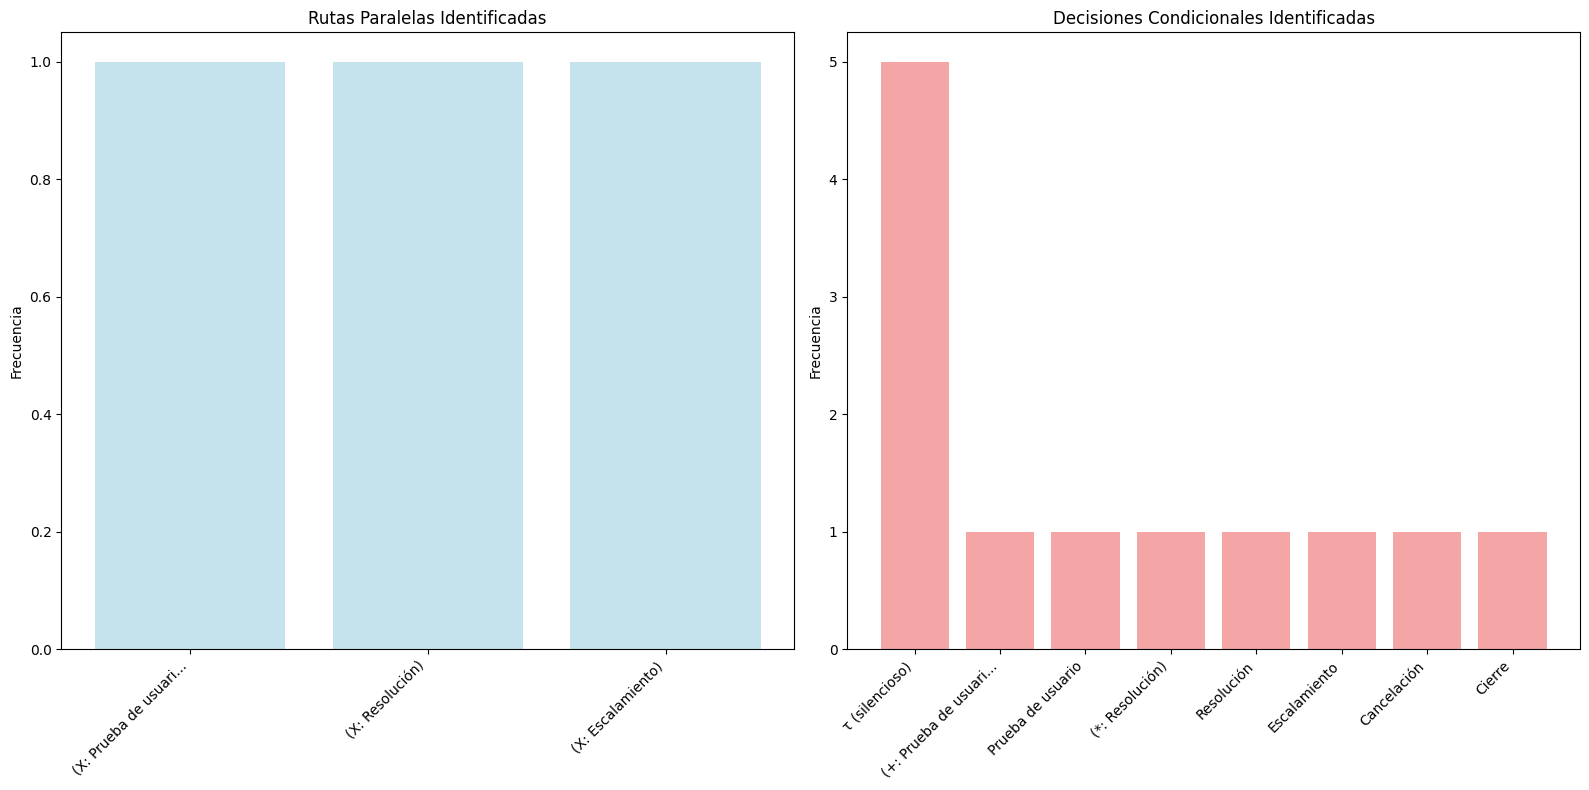


  ANÁLISIS COMPLETO DEL DFG - PREGUNTA 16

🔍 ANÁLISIS DE DECISIONES CONDICIONALES:

Después de 'Diagnóstico técnico':
  → Resolución: 690 veces (69.0%)
  → Cierre: 165 veces (16.5%)
  → Cancelación: 21 veces (2.1%)
  → Escalamiento: 37 veces (3.7%)

Después de 'Resolución':
  → Prueba de usuario: 202 veces (22.6%)
  → Cierre: 533 veces (59.6%)

Punto final del proceso:
  → Cierre: 210 veces (92.1%)
  → Cancelación: 18 veces (7.9%)

📈 TRANSICIONES MÁS COMUNES EN EL DFG:

Top 10 transiciones más frecuentes:
  1. Recepción ticket → Clasificación: 1000 veces (100.0% de casos)
  2. Clasificación → Asignación técnico: 1000 veces (100.0% de casos)
  3. Asignación técnico → Diagnóstico técnico: 1000 veces (100.0% de casos)
  4. Diagnóstico técnico → Resolución: 690 veces (69.0% de casos)
  5. Resolución → Cierre: 533 veces (53.3% de casos)
  6. Prueba de usuario → Cierre: 210 veces (21.0% de casos)
  7. Escalamiento → Resolución: 204 veces (20.4% de casos)
  8. Resolución → Prueba de usuario:

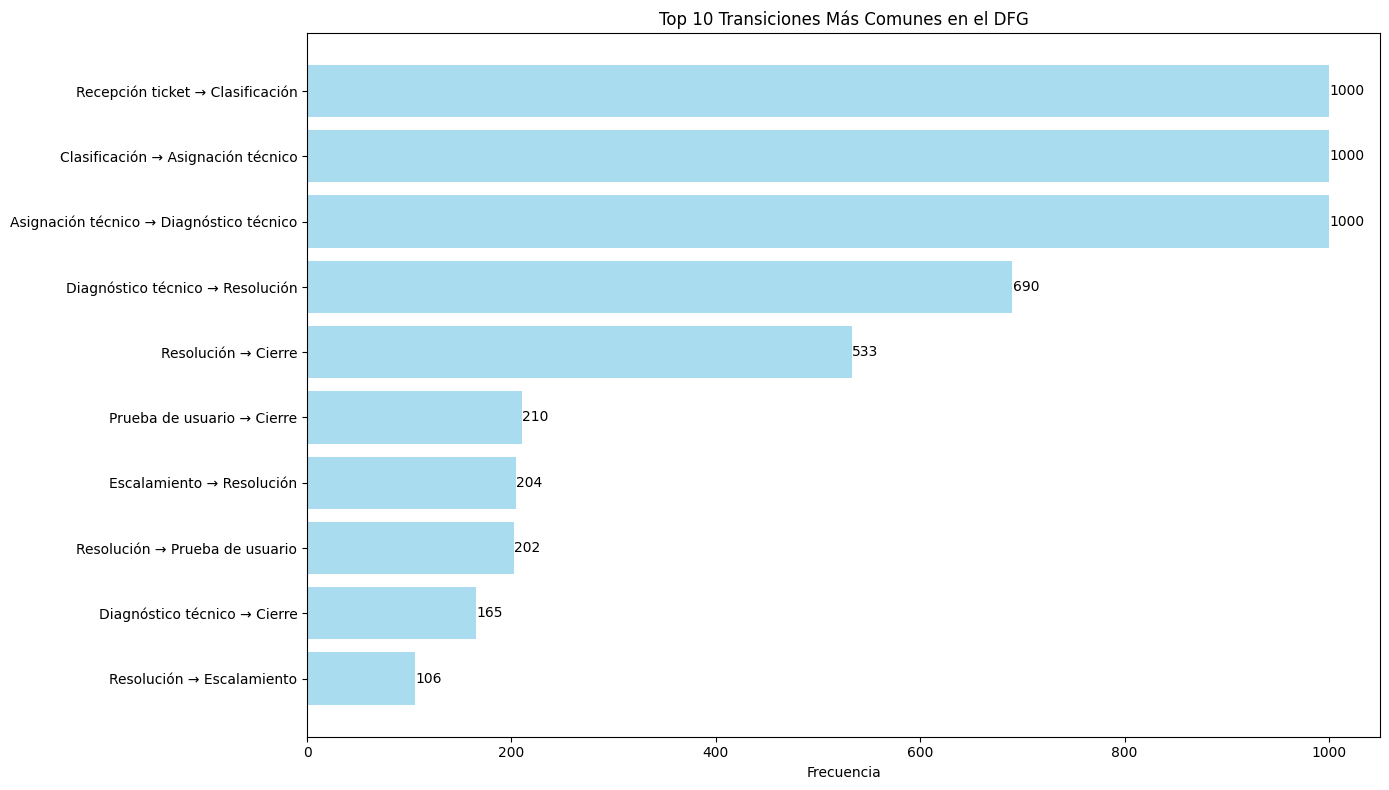


🔚 ¿DÓNDE TERMINAN LOS TICKETS?

Distribución de puntos finales:
  Cierre: 908 tickets (90.8%)
  Cancelación: 92 tickets (9.2%)

Caminos típicos hacia cada punto final:
  Camino más común a 'Cierre': Asignación técnico → Diagnóstico técnico → Resolución → Cierre (329 veces, 32.9%)
  Camino más común a 'Cancelación': Asignación técnico → Diagnóstico técnico → Resolución → Cancelación (53 veces, 5.3%)


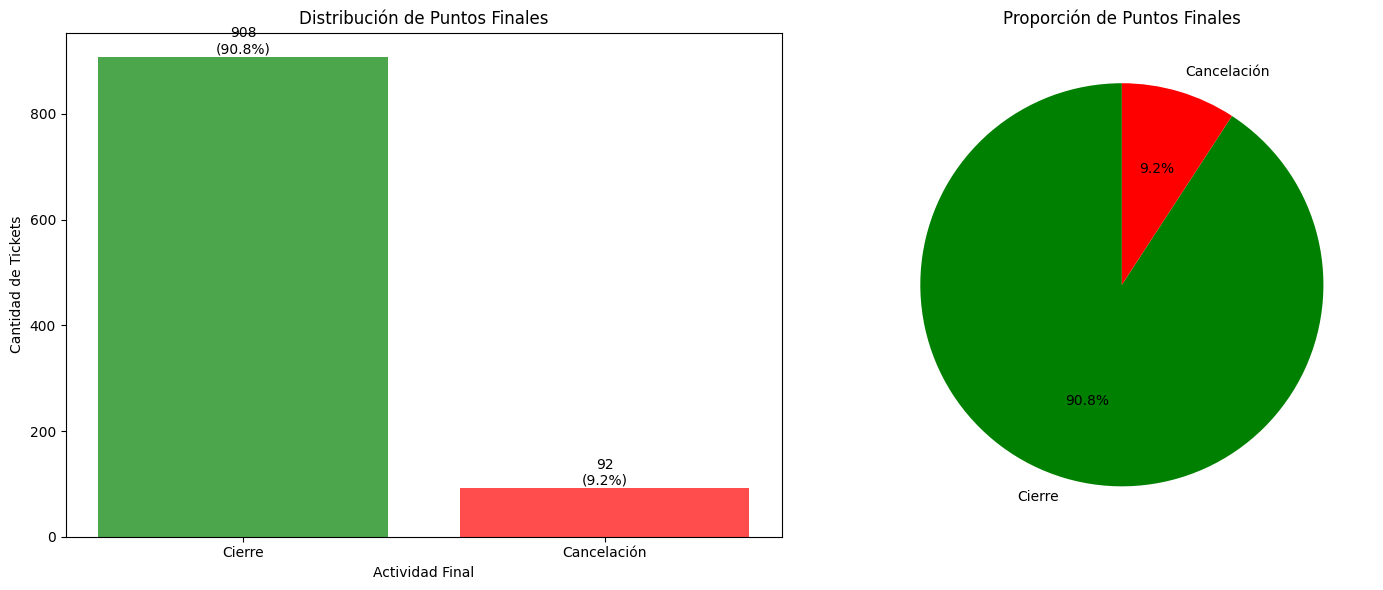

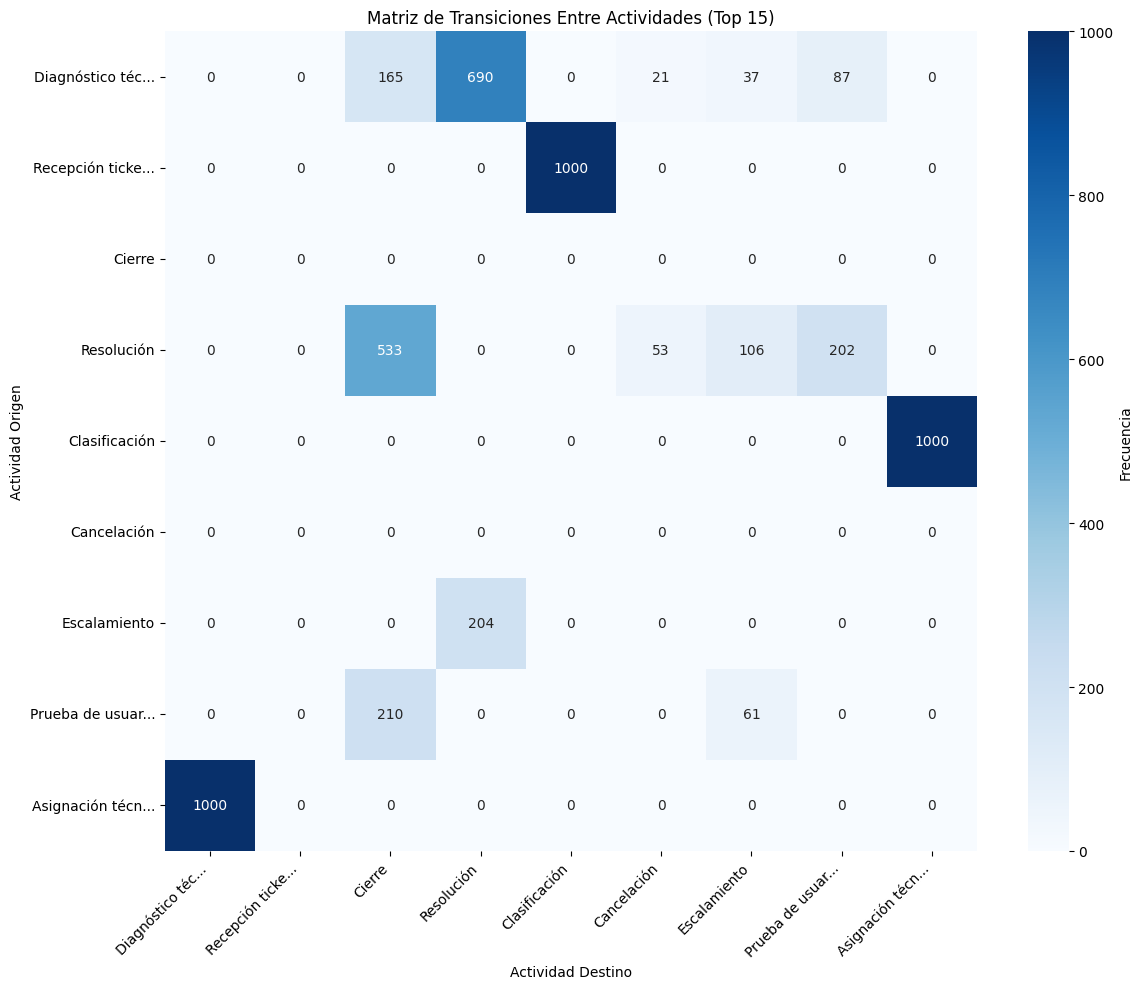


🚀 EJECUTANDO ANÁLISIS COMPLETO...

  EJECUCIÓN COMPLETA - ANÁLISIS DE DURACIONES Y BALANCE

  ANÁLISIS DE DURACIONES Y BALANCE - PREGUNTA 17

🔍 TICKET CON MAYOR DURACIÓN ENTRE TAREAS:
• Caso: Ticket_5
• Duración máxima: 60.00 minutos
• Entre actividades: Asignación técnico → Diagnóstico técnico

📊 ESTADÍSTICAS DE DURACIONES ENTRE TAREAS:
• Promedio: 34.94 min
• Mediana: 35.00 min
• Desviación estándar: 14.73 min
• Mínimo: 10.00 min
• Máximo: 60.00 min


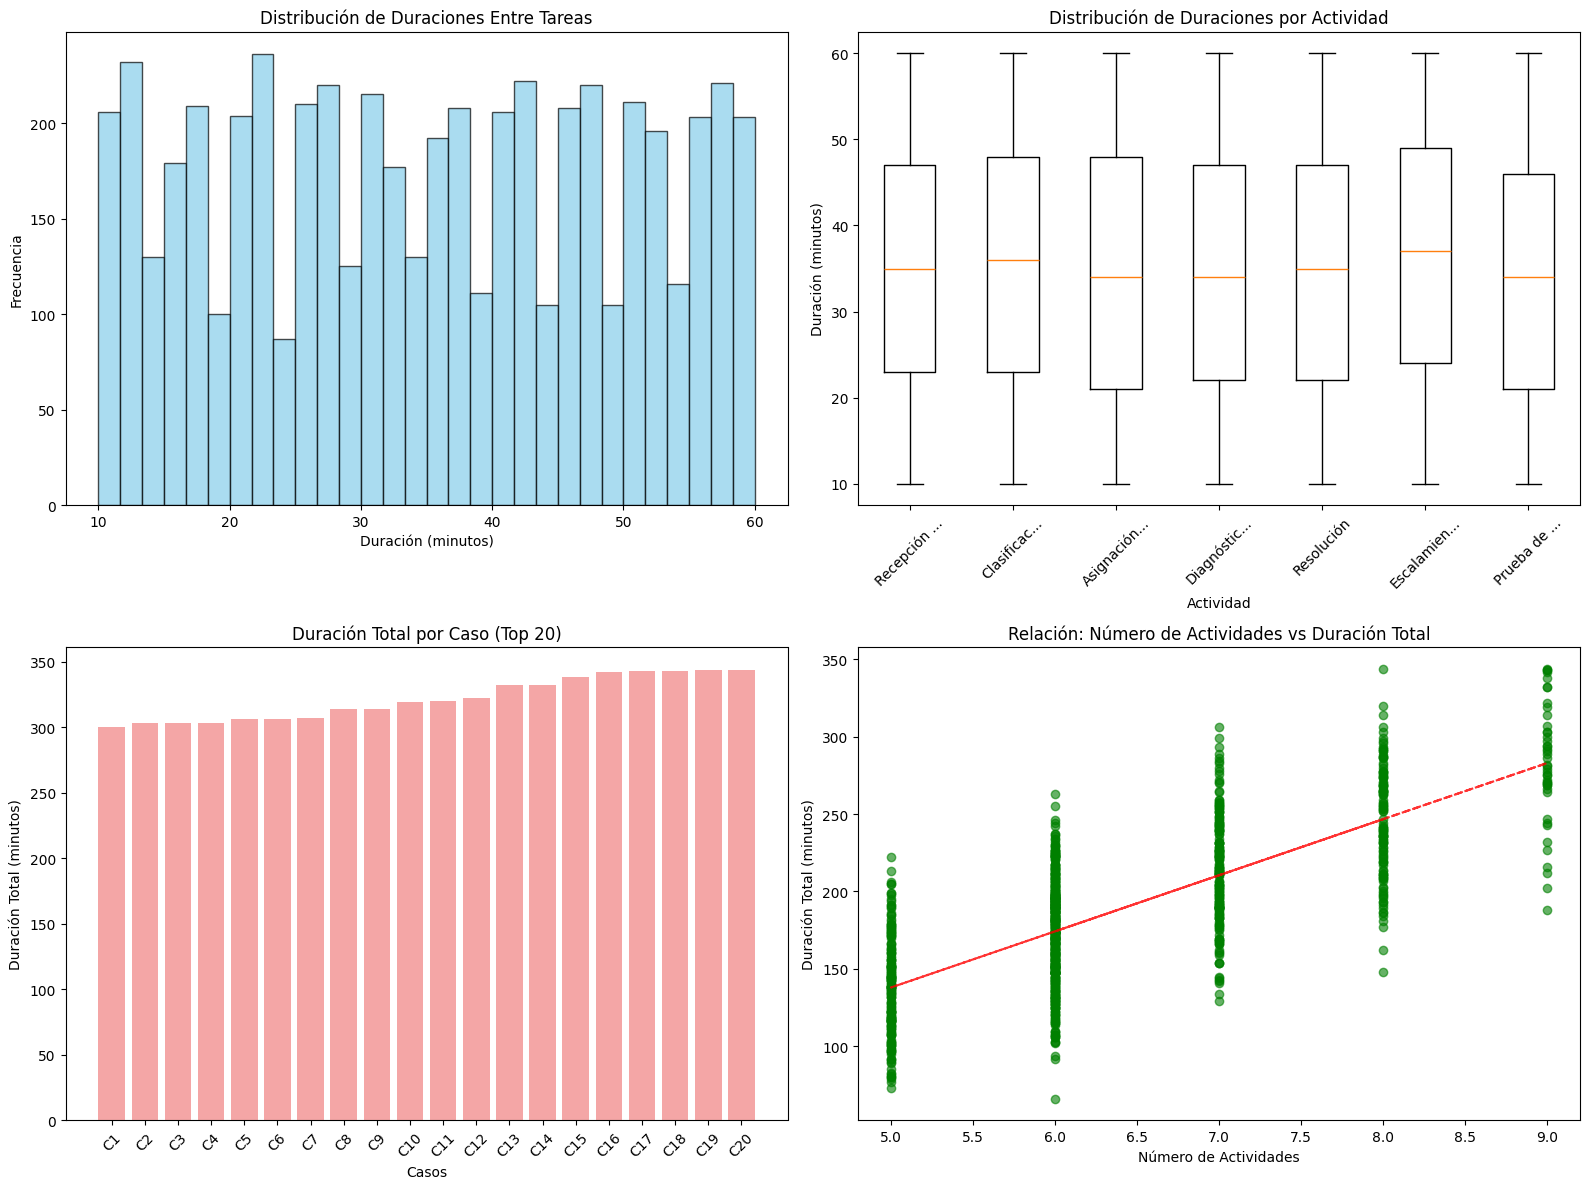


📅 Generando Diagrama de Gantt para 8 casos...



⚖️ ANÁLISIS DE BALANCE DEL FLUJO:
• Número promedio de actividades por caso: 6.39
• Coeficiente de variación (actividades): 0.166
• Duración promedio por caso: 188.23 minutos
• Coeficiente de variación (duraciones): 0.271

📋 INTERPRETACIÓN DEL BALANCE:
• Actividades: El flujo está MUY BALANCEADO en número de actividades
• Duraciones: Las duraciones están MUY BALANCEADAS entre casos

🔄 ANÁLISIS DE VARIANTES DE FLUJO:
• Total de variantes únicas: 12
• Total de casos: 1000
• Promedio de casos por variante: 83.33

Top 5 variantes más comunes:
  1. Recepción ticket → Clasificación → Asignación técnico... (329 casos, 32.9%)
  2. Recepción ticket → Clasificación → Asignación técnico... (165 casos, 16.5%)
  3. Recepción ticket → Clasificación → Asignación técnico... (147 casos, 14.7%)
  4. Recepción ticket → Clasificación → Asignación técnico... (106 casos, 10.6%)
  5. Recepción ticket → Clasificación → Asignación técnico... (63 casos, 6.3%)

• Índice de diversidad de Shannon: 2.895
• Shannon

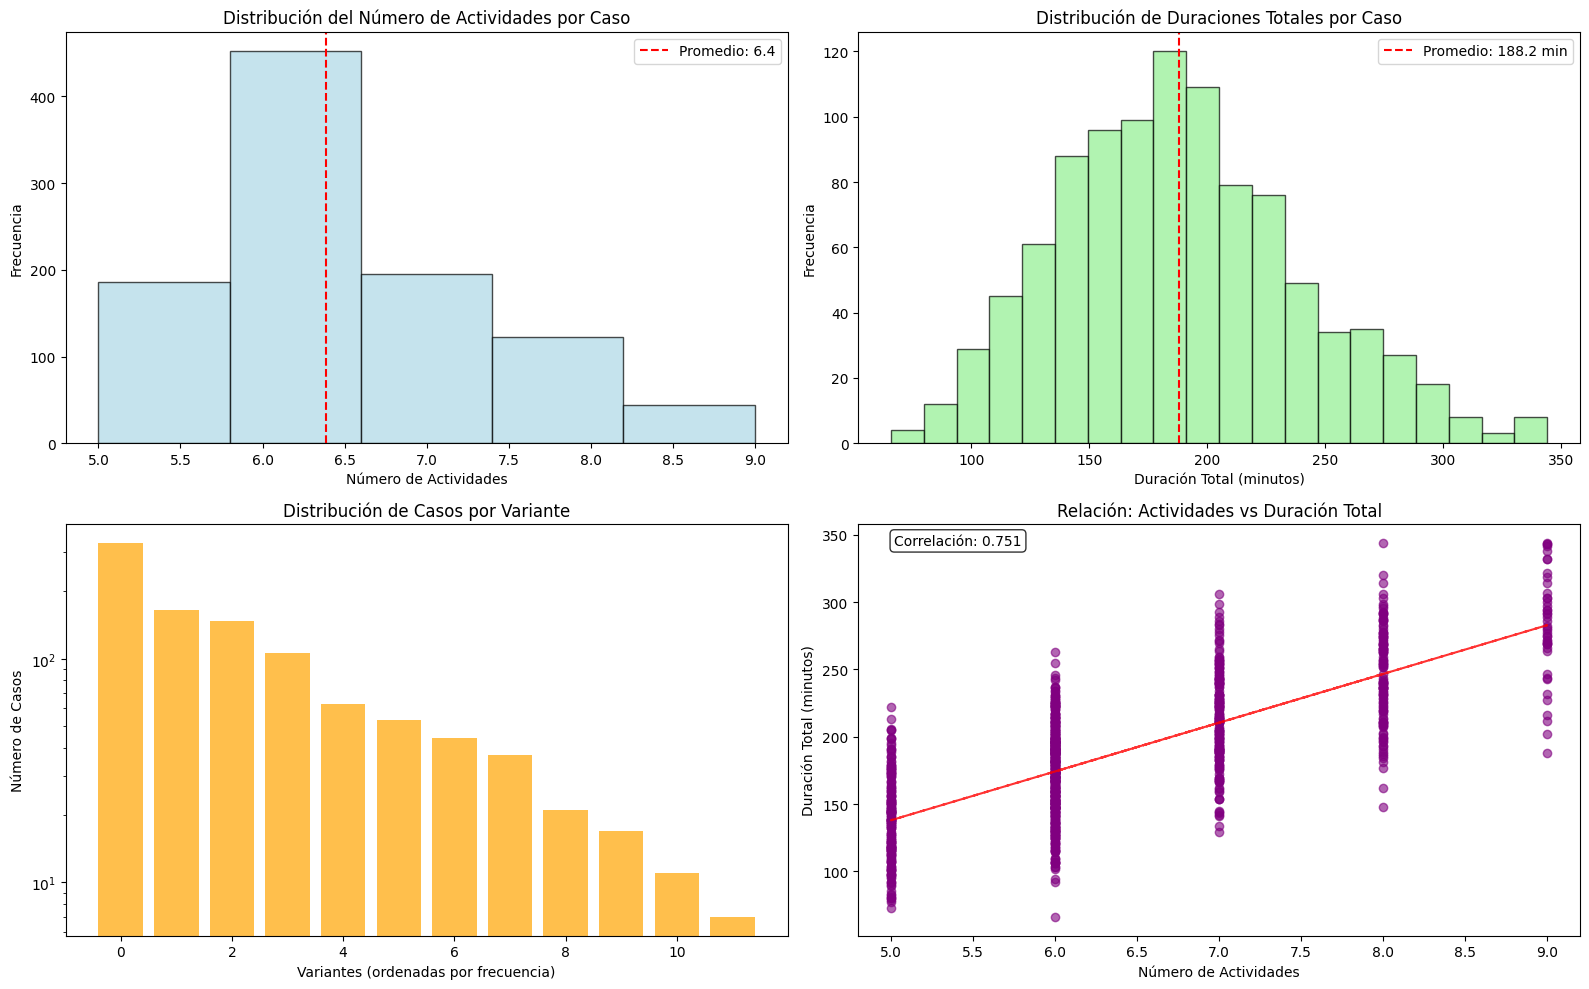


  RESUMEN EJECUTIVO - PREGUNTA 17

🎯 RESPUESTAS DIRECTAS:
• Ticket con mayor duración entre tareas: Ticket_5
• Duración máxima entre tareas: 60.00 minutos
• Balance general del flujo: MUY BALANCEADO
• Diversidad de variantes: 80.8%

📊 MÉTRICAS CLAVE:
• Coeficiente de variación (actividades): 0.166
• Coeficiente de variación (duraciones): 0.271
• Número total de variantes: 12

  RESUMEN FINAL - PREGUNTAS 15, 16 Y 17

📋 PREGUNTA 15 - Modelo de Petri Net:
✓ Se identificaron rutas paralelas y decisiones condicionales en el árbol de proceso
✓ Se visualizaron las estructuras de control del proceso
✓ Se explicó la correspondencia entre operadores del árbol y elementos de la Red de Petri

📋 PREGUNTA 16 - DFG (Directly-Follows Graph):
✓ Se identificaron las transiciones más comunes entre actividades
✓ Se analizaron los puntos finales donde terminan los tickets
✓ Se crearon visualizaciones de flujo y matriz de transiciones

📋 PREGUNTA 17 - Diagrama de Gantt y Balance:
✓ Se identificó el ticket 

In [ ]:
print("=" * 60)
print("Parte 4: Visualización del flujo del proceso")
print("=" * 60)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pregunta 15: Analiza el modelo de Petri net: ¿Qué rutas paralelas existen? ¿Dónde hay decisiones condicionales?
print("Pregunta 15: Analiza el modelo de Petri net: ¿Qué rutas paralelas existen? ¿Dónde hay decisiones condicionales?")
from pm4py.objects.process_tree.obj import Operator

# 15. Analiza el modelo de Petri net
print("Descubriendo el árbol de proceso...")
tree = inductive_miner.apply(log)
print("Árbol de proceso descubierto.")

# --- Funciones para analizar el Árbol de Proceso ---
def get_branch_activities_label(node):
    """
    Obtiene una etiqueta descriptiva para una rama (nodo hijo de un operador).
    """
    if node.label: # Es una actividad (hoja)
        return node.label
    elif node.operator: # Es un operador (nodo interno)
        leaf_activities = []

        def find_leaves(current_node, L_activities):
            if current_node.label:
                L_activities.append(current_node.label)
            elif current_node.operator:
                for child_node in current_node.children:
                    find_leaves(child_node, L_activities)

        find_leaves(node, leaf_activities)

        if leaf_activities:
            unique_leaves = list(dict.fromkeys(leaf_activities)) # Eliminar duplicados
            label_detail = ', '.join(unique_leaves) if len(unique_leaves) <= 3 else f"{len(unique_leaves)} actividades..."
            return f"({str(node.operator).split('.')[-1]}: {label_detail})"
        return f"(Operador: {str(node.operator).split('.')[-1]})" # Si no hay hojas (ej. operador de silenciosos)
    # Nodo silencioso (no tiene etiqueta ni operador)
    return "τ (silencioso)" if not node.label and not node.operator else "(Nodo desconocido)"


def analyze_process_tree_for_petri_analysis(node, level=0):
    """
    Analiza recursivamente el árbol de proceso para identificar y mostrar
    rutas paralelas (AND) y decisiones condicionales (XOR).
    """
    indent = "  " * level
    parallel_routes = []
    conditional_decisions = []

    if node.operator: # Si es un nodo de operador
        operator_name = str(node.operator).split('.')[-1] # Ej: Operator.XOR -> XOR

        if node.operator == Operator.PARALLEL:
            print(f"\n{indent}🚦 **Ruta Paralela (AND) Identificada:**")
            print(f"{indent}   Las siguientes ramas se ejecutan en paralelo en el modelo:")
            parallel_info = []
            for i, child in enumerate(node.children):
                branch_label = get_branch_activities_label(child)
                print(f"{indent}   - Rama {i+1}: {branch_label}")
                parallel_info.append(branch_label)
            parallel_routes.append(parallel_info)

        elif node.operator == Operator.XOR:
            print(f"\n{indent}🔀 **Decisión Condicional (XOR / Elección) Identificada:**")
            print(f"{indent}   Se elige una de las siguientes rutas en el modelo:")
            decision_info = []
            for i, child in enumerate(node.children):
                branch_label = get_branch_activities_label(child)
                print(f"{indent}   - Opción {i+1}: {branch_label}")
                decision_info.append(branch_label)
            conditional_decisions.append(decision_info)

        elif node.operator == Operator.LOOP: # Los bucles también implican una decisión
            print(f"\n{indent}🔄 **Bucle (LOOP) Identificado:**")
            print(f"{indent}   Implica una decisión de repetir o salir del bucle.")
            loop_info = []
            if len(node.children) >= 2: # Típicamente cuerpo y salida
                body_label = get_branch_activities_label(node.children[0])
                exit_label = get_branch_activities_label(node.children[1])
                print(f"{indent}   - Cuerpo del bucle (puede repetirse): {body_label}")
                print(f"{indent}   - Salida/continuación tras el bucle: {exit_label}")
                loop_info = [body_label, exit_label]
            if len(node.children) > 2: # A veces hay un tercer hijo para la re-evaluación
                redo_label = get_branch_activities_label(node.children[2])
                print(f"{indent}   - Parte de re-evaluación/repetición: {redo_label}")
                loop_info.append(redo_label)
            conditional_decisions.append(loop_info)

        # Analizar recursivamente los hijos del operador
        for child in node.children:
            child_parallel, child_conditional = analyze_process_tree_for_petri_analysis(child, level + 1)
            parallel_routes.extend(child_parallel)
            conditional_decisions.extend(child_conditional)

    return parallel_routes, conditional_decisions

# --- Visualización de estructura del árbol ---
def visualize_process_structure(parallel_routes, conditional_decisions):
    """
    Crea visualizaciones para mostrar las rutas paralelas y decisiones condicionales
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # Gráfico de rutas paralelas
    if parallel_routes:
        parallel_counts = {}
        for routes in parallel_routes:
            for route in routes:
                parallel_counts[route] = parallel_counts.get(route, 0) + 1

        ax1.bar(range(len(parallel_counts)), list(parallel_counts.values()),
                color='lightblue', alpha=0.7)
        ax1.set_xticks(range(len(parallel_counts)))
        ax1.set_xticklabels([key[:20] + '...' if len(key) > 20 else key
                            for key in parallel_counts.keys()], rotation=45, ha='right')
        ax1.set_title('Rutas Paralelas Identificadas')
        ax1.set_ylabel('Frecuencia')
    else:
        ax1.text(0.5, 0.5, 'No se encontraron rutas paralelas',
                ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Rutas Paralelas')

    # Gráfico de decisiones condicionales
    if conditional_decisions:
        decision_counts = {}
        for decisions in conditional_decisions:
            for decision in decisions:
                decision_counts[decision] = decision_counts.get(decision, 0) + 1

        ax2.bar(range(len(decision_counts)), list(decision_counts.values()),
                color='lightcoral', alpha=0.7)
        ax2.set_xticks(range(len(decision_counts)))
        ax2.set_xticklabels([key[:20] + '...' if len(key) > 20 else key
                            for key in decision_counts.keys()], rotation=45, ha='right')
        ax2.set_title('Decisiones Condicionales Identificadas')
        ax2.set_ylabel('Frecuencia')
    else:
        ax2.text(0.5, 0.5, 'No se encontraron decisiones condicionales',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Decisiones Condicionales')

    plt.tight_layout()
    plt.show()

# --- Iniciar el análisis del árbol ---
print("\n## Análisis Estructural del Modelo de Proceso (basado en el Árbol de Proceso):")
if tree:
    parallel_routes, conditional_decisions = analyze_process_tree_for_petri_analysis(tree)
    print("\n---")
    print("Nota: La Red de Petri generada visualmente se construye a partir de estas estructuras")
    print("del árbol de proceso. Un operador 'AND' en el árbol corresponde a puertas paralelas")
    print("en la Red de Petri, y un 'XOR' a puertas de elección exclusiva.")

    # Crear visualización
    visualize_process_structure(parallel_routes, conditional_decisions)
else:
    print("No se pudo descubrir un árbol de proceso para el análisis.")

# Pregunta 16: Revisa el DFG (Directly-Follows Graph): ¿Qué transiciones son más comunes?	¿Dónde terminan la mayoría de los tickets?

# ---------------------------
# ANÁLISIS DE DECISIONES CONDICIONALES
# ---------------------------

def analizar_decisiones(log):
    print("\n🔍 ANÁLISIS DE DECISIONES CONDICIONALES:")

    # Obtenemos todas las trazas y sus transiciones
    traces = [tuple(event['concept:name'] for event in trace) for trace in log]

    # Puntos de decisión clave identificados en el código de simulación
    decision_points = {
        "Después de 'Diagnóstico técnico'": {
            "Opciones": ["Resolución", "Cierre", "Cancelación", "Escalamiento"],
            "Transiciones": []
        },
        "Después de 'Resolución'": {
            "Opciones": ["Prueba de usuario", "Cierre"],
            "Transiciones": []
        },
        "Punto final del proceso": {
            "Opciones": ["Cierre", "Cancelación"],
            "Transiciones": []
        }
    }

    # Analizamos las transiciones reales en el log
    for trace in traces:
        for i in range(len(trace)-1):
            current = trace[i]
            next_act = trace[i+1]

            if current == "Diagnóstico técnico":
                decision_points["Después de 'Diagnóstico técnico'"]["Transiciones"].append(next_act)
            elif current == "Resolución":
                decision_points["Después de 'Resolución'"]["Transiciones"].append(next_act)
            elif next_act in ["Cierre", "Cancelación"]:
                decision_points["Punto final del proceso"]["Transiciones"].append(next_act)

    # Calculamos estadísticas para cada punto de decisión
    for point, data in decision_points.items():
        trans = data["Transiciones"]
        total = len(trans) if trans else 1  # Evitar división por cero

        print(f"\n{point}:")
        for option in data["Opciones"]:
            count = trans.count(option)
            print(f"  → {option}: {count} veces ({count/total*100:.1f}%)")

    return decision_points

# ---------------------------
# ANÁLISIS DE TRANSICIONES COMUNES EN DFG
# ---------------------------

def analizar_transiciones_comunes(dfg_result, log):
    print("\n📈 TRANSICIONES MÁS COMUNES EN EL DFG:")

    # Ordenamos las transiciones por frecuencia
    sorted_transitions = sorted(dfg_result.items(), key=lambda x: x[1], reverse=True)

    # Top 10 transiciones
    print("\nTop 10 transiciones más frecuentes:")
    for i, ((source, target), count) in enumerate(sorted_transitions[:10], 1):
        percentage = count/len(log)*100
        print(f"  {i}. {source} → {target}: {count} veces ({percentage:.1f}% de casos)")

    # Crear gráfico de transiciones más comunes
    if sorted_transitions:
        top_10 = sorted_transitions[:10]
        transitions = [f"{src} → {tgt}" for (src, tgt), _ in top_10]
        counts = [count for _, count in top_10]

        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(transitions)), counts, color='skyblue', alpha=0.7)
        plt.yticks(range(len(transitions)), [t[:40] + '...' if len(t) > 40 else t for t in transitions])
        plt.xlabel('Frecuencia')
        plt.title('Top 10 Transiciones Más Comunes en el DFG')
        plt.gca().invert_yaxis()

        # Agregar etiquetas de valor en las barras
        for i, bar in enumerate(bars):
            width = bar.get_width()
            plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{counts[i]}', ha='left', va='center')

        plt.tight_layout()
        plt.show()

    return sorted_transitions

# ---------------------------
# ANÁLISIS DE PUNTOS FINALES
# ---------------------------

def analizar_puntos_finales(log):
    print("\n🔚 ¿DÓNDE TERMINAN LOS TICKETS?")

    end_activities = get_end_activities(log)
    total_cases = len(log)

    print("\nDistribución de puntos finales:")
    for activity, count in end_activities.items():
        print(f"  {activity}: {count} tickets ({count/total_cases*100:.1f}%)")

    # Análisis de caminos que llevan a cada punto final
    print("\nCaminos típicos hacia cada punto final:")

    end_paths = {
        "Cierre": [],
        "Cancelación": [],
        "Escalamiento": []
    }

    for trace in log:
        activities = [event['concept:name'] for event in trace]
        end_activity = activities[-1]

        if end_activity in end_paths:
            # Capturamos las 3 actividades anteriores al final
            path = activities[-4:-1] if len(activities) >= 4 else activities[:-1]
            end_paths[end_activity].append(" → ".join(path))

    for end_act, paths in end_paths.items():
        if paths:
            path_counts = Counter(paths)
            most_common_path, freq = path_counts.most_common(1)[0]
            print(f"  Camino más común a '{end_act}': {most_common_path} → {end_act} ({freq} veces, {freq/total_cases*100:.1f}%)")

    # Crear gráfico de puntos finales
    if end_activities:
        activities = list(end_activities.keys())
        counts = list(end_activities.values())
        percentages = [count/total_cases*100 for count in counts]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Gráfico de barras
        bars = ax1.bar(activities, counts, color=['green', 'red', 'orange'][:len(activities)], alpha=0.7)
        ax1.set_title("Distribución de Puntos Finales")
        ax1.set_xlabel("Actividad Final")
        ax1.set_ylabel("Cantidad de Tickets")

        # Agregar etiquetas
        for bar, count, pct in zip(bars, counts, percentages):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{count}\n({pct:.1f}%)', ha='center', va='bottom')

        # Gráfico circular
        ax2.pie(counts, labels=activities, autopct='%1.1f%%', startangle=90,
                colors=['green', 'red', 'orange'][:len(activities)])
        ax2.set_title("Proporción de Puntos Finales")

        plt.tight_layout()
        plt.show()

    return end_paths

# ---------------------------
# EJECUCIÓN DEL ANÁLISIS COMPLETO
# ---------------------------

def analisis_completo_dfg(log, dfg_result):
    print("\n" + "="*60)
    print("  ANÁLISIS COMPLETO DEL DFG - PREGUNTA 16")
    print("="*60)

    # 1. Análisis de decisiones condicionales
    decisiones = analizar_decisiones(log)

    # 2. Análisis de transiciones comunes
    transiciones = analizar_transiciones_comunes(dfg_result, log)

    # 3. Análisis de puntos finales
    puntos_finales = analizar_puntos_finales(log)

    # 4. Crear gráfico adicional de flujo de transiciones
    crear_grafico_flujo_transiciones(transiciones[:15])

    return {
        "decisiones": decisiones,
        "transiciones": transiciones,
        "puntos_finales": puntos_finales
    }

def crear_grafico_flujo_transiciones(top_transitions):
    """
    Crea un gráfico de red para visualizar el flujo de transiciones
    """
    # Preparar datos para el gráfico de red
    nodes = set()
    edges = []

    for (source, target), count in top_transitions:
        nodes.add(source)
        nodes.add(target)
        edges.append((source, target, count))

    # Crear matriz de adyacencia
    node_list = list(nodes)
    n = len(node_list)
    node_to_idx = {node: i for i, node in enumerate(node_list)}

    # Crear gráfico de matriz de calor de transiciones
    matrix = np.zeros((n, n))
    for source, target, count in edges:
        i, j = node_to_idx[source], node_to_idx[target]
        matrix[i][j] = count

    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix,
                xticklabels=[node[:15] + '...' if len(node) > 15 else node for node in node_list],
                yticklabels=[node[:15] + '...' if len(node) > 15 else node for node in node_list],
                annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Frecuencia'})
    plt.title('Matriz de Transiciones Entre Actividades (Top 15)')
    plt.xlabel('Actividad Destino')
    plt.ylabel('Actividad Origen')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Ejecutamos el análisis
resultados_dfg = analisis_completo_dfg(log, dfg_result)

# Pregunta 17: Observa el Diagrama de Gantt: ¿Qué ticket tiene la mayor duración entre tareas? ¿Qué tan balanceado está el flujo de tareas por ticket?

# ---------------------------
# ANÁLISIS COMPLETO PARA PREGUNTA 17
# ---------------------------

def analisis_duraciones_completo(log):
    """
    Análisis completo de duraciones y balance del flujo
    """
    print("\n" + "="*60)
    print("  ANÁLISIS DE DURACIONES Y BALANCE - PREGUNTA 17")
    print("="*60)

    # 1. Calcular duraciones por caso y actividad
    case_info = {}
    activity_durations = {}

    for trace in log:
        case_id = trace.attributes["concept:name"]
        activities = []
        timestamps = []
        durations_between_tasks = []

        for event in trace:
            activities.append(event["concept:name"])
            timestamps.append(pd.to_datetime(event["time:timestamp"]))

        # Calcular duraciones entre tareas
        if len(timestamps) > 1:
            for i in range(len(timestamps)-1):
                duration = (timestamps[i+1] - timestamps[i]).total_seconds() / 60  # minutos
                durations_between_tasks.append(duration)

                # Registrar duración por actividad
                activity = activities[i]
                if activity not in activity_durations:
                    activity_durations[activity] = []
                activity_durations[activity].append(duration)

        # Duración total del caso
        total_duration = (timestamps[-1] - timestamps[0]).total_seconds() / 60 if len(timestamps) > 1 else 0

        case_info[case_id] = {
            'activities': activities,
            'timestamps': timestamps,
            'durations_between_tasks': durations_between_tasks,
            'total_duration': total_duration,
            'num_activities': len(activities)
        }

    # 2. Identificar ticket con mayor duración entre tareas
    max_duration_between = 0
    max_case_between = None
    max_activity_pair = None

    for case_id, info in case_info.items():
        if info['durations_between_tasks']:
            max_dur_in_case = max(info['durations_between_tasks'])
            if max_dur_in_case > max_duration_between:
                max_duration_between = max_dur_in_case
                max_case_between = case_id
                max_idx = info['durations_between_tasks'].index(max_dur_in_case)
                max_activity_pair = (info['activities'][max_idx], info['activities'][max_idx+1])

    print(f"\n🔍 TICKET CON MAYOR DURACIÓN ENTRE TAREAS:")
    print(f"• Caso: {max_case_between}")
    print(f"• Duración máxima: {max_duration_between:.2f} minutos")
    print(f"• Entre actividades: {max_activity_pair[0]} → {max_activity_pair[1]}")

    # 3. Análisis estadístico de duraciones
    all_durations = []
    for info in case_info.values():
        all_durations.extend(info['durations_between_tasks'])

    if all_durations:
        print(f"\n📊 ESTADÍSTICAS DE DURACIONES ENTRE TAREAS:")
        print(f"• Promedio: {np.mean(all_durations):.2f} min")
        print(f"• Mediana: {np.median(all_durations):.2f} min")
        print(f"• Desviación estándar: {np.std(all_durations):.2f} min")
        print(f"• Mínimo: {np.min(all_durations):.2f} min")
        print(f"• Máximo: {np.max(all_durations):.2f} min")

    return case_info, activity_durations, max_case_between, max_duration_between

def crear_graficos_duraciones(case_info, activity_durations):
    """
    Crea gráficos para análisis de duraciones
    """
    # 1. Histograma de duraciones entre tareas
    all_durations = []
    for info in case_info.values():
        all_durations.extend(info['durations_between_tasks'])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Histograma de duraciones
    axes[0,0].hist(all_durations, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Distribución de Duraciones Entre Tareas')
    axes[0,0].set_xlabel('Duración (minutos)')
    axes[0,0].set_ylabel('Frecuencia')

    # Box plot por actividad
    if activity_durations:
        activities = list(activity_durations.keys())
        durations_by_activity = [activity_durations[act] for act in activities]

        bp = axes[0,1].boxplot(durations_by_activity, labels=[act[:10] + '...' if len(act) > 10 else act for act in activities])
        axes[0,1].set_title('Distribución de Duraciones por Actividad')
        axes[0,1].set_xlabel('Actividad')
        axes[0,1].set_ylabel('Duración (minutos)')
        axes[0,1].tick_params(axis='x', rotation=45)

    # Duración total por caso
    total_durations = [info['total_duration'] for info in case_info.values()]
    case_ids = list(case_info.keys())

    # Tomar solo los primeros 20 casos para visualización
    if len(total_durations) > 20:
        indices = np.argsort(total_durations)[-20:]  # Los 20 con mayor duración
        selected_durations = [total_durations[i] for i in indices]
        selected_cases = [case_ids[i] for i in indices]
    else:
        selected_durations = total_durations
        selected_cases = case_ids

    axes[1,0].bar(range(len(selected_durations)), selected_durations, color='lightcoral', alpha=0.7)
    axes[1,0].set_title('Duración Total por Caso (Top 20)')
    axes[1,0].set_xlabel('Casos')
    axes[1,0].set_ylabel('Duración Total (minutos)')
    axes[1,0].set_xticks(range(len(selected_cases)))
    axes[1,0].set_xticklabels([f'C{i+1}' for i in range(len(selected_cases))], rotation=45)

    # Scatter plot: Número de actividades vs Duración total
    num_activities = [info['num_activities'] for info in case_info.values()]
    axes[1,1].scatter(num_activities, total_durations, alpha=0.6, color='green')
    axes[1,1].set_title('Relación: Número de Actividades vs Duración Total')
    axes[1,1].set_xlabel('Número de Actividades')
    axes[1,1].set_ylabel('Duración Total (minutos)')

    # Línea de tendencia
    if len(num_activities) > 1:
        z = np.polyfit(num_activities, total_durations, 1)
        p = np.poly1d(z)
        axes[1,1].plot(num_activities, p(num_activities), "r--", alpha=0.8)

    plt.tight_layout()
    plt.show()

def generar_gantt_mejorado(log, case_info, num_cases=10):
    """
    Genera un diagrama de Gantt mejorado para los casos seleccionados
    """
    print(f"\n📅 Generando Diagrama de Gantt para {num_cases} casos...")

    # Seleccionar casos: los de mayor duración total
    sorted_cases = sorted(case_info.items(), key=lambda x: x[1]['total_duration'], reverse=True)[:num_cases]

    gantt_data = []

    for case_id, info in sorted_cases:
        activities = info['activities']
        timestamps = info['timestamps']

        for i in range(len(activities)):
            start_time = timestamps[i]

            # Para la duración de cada actividad, usar el tiempo hasta la siguiente o asumir 30 min
            if i < len(timestamps) - 1:
                end_time = timestamps[i + 1]
            else:
                end_time = start_time + pd.Timedelta(minutes=30)

            duration_minutes = (end_time - start_time).total_seconds() / 60

            gantt_data.append({
                'Caso': f"Caso {case_id}",
                'Actividad': activities[i],
                'Inicio': start_time,
                'Fin': end_time,
                'Duración': duration_minutes
            })

    # Crear DataFrame
    df_gantt = pd.DataFrame(gantt_data)

    # Crear el diagrama de Gantt con Plotly
    fig = px.timeline(
        df_gantt,
        x_start="Inicio",
        x_end="Fin",
        y="Caso",
        color="Actividad",
        hover_data=["Duración"],
        title=f"Diagrama de Gantt - {num_cases} Casos con Mayor Duración Total",
        width=1200,
        height=600
    )

    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        xaxis_title="Tiempo",
        yaxis_title="Casos",
        legend_title="Actividades"
    )

    fig.show()

    return df_gantt

def analisis_balance_flujo(case_info):
    """
    Analiza qué tan balanceado está el flujo de tareas por ticket
    """
    print(f"\n⚖️ ANÁLISIS DE BALANCE DEL FLUJO:")

    # Métricas de balance
    num_activities_per_case = [info['num_activities'] for info in case_info.values()]
    total_durations = [info['total_duration'] for info in case_info.values()]

    # Coeficiente de variación para número de actividades
    cv_activities = np.std(num_activities_per_case) / np.mean(num_activities_per_case) if np.mean(num_activities_per_case) > 0 else 0

    # Coeficiente de variación para duraciones totales
    cv_durations = np.std(total_durations) / np.mean(total_durations) if np.mean(total_durations) > 0 else 0

    print(f"• Número promedio de actividades por caso: {np.mean(num_activities_per_case):.2f}")
    print(f"• Coeficiente de variación (actividades): {cv_activities:.3f}")
    print(f"• Duración promedio por caso: {np.mean(total_durations):.2f} minutos")
    print(f"• Coeficiente de variación (duraciones): {cv_durations:.3f}")

    # Interpretación del balance
    print(f"\n📋 INTERPRETACIÓN DEL BALANCE:")

    if cv_activities < 0.3:
        print("• Actividades: El flujo está MUY BALANCEADO en número de actividades")
    elif cv_activities < 0.6:
        print("• Actividades: El flujo está MODERADAMENTE BALANCEADO")
    else:
        print("• Actividades: El flujo está DESBALANCEADO (alta variabilidad)")

    if cv_durations < 0.3:
        print("• Duraciones: Las duraciones están MUY BALANCEADAS entre casos")
    elif cv_durations < 0.6:
        print("• Duraciones: Las duraciones están MODERADAMENTE BALANCEADAS")
    else:
        print("• Duraciones: Las duraciones están DESBALANCEADAS (alta variabilidad)")

    # Análisis de variantes (patrones de flujo)
    variants = {}
    for case_id, info in case_info.items():
        variant = tuple(info['activities'])
        if variant not in variants:
            variants[variant] = []
        variants[variant].append(case_id)

    # Estadísticas de variantes
    variant_counts = [len(cases) for cases in variants.values()]
    num_variants = len(variants)
    total_cases = len(case_info)

    print(f"\n🔄 ANÁLISIS DE VARIANTES DE FLUJO:")
    print(f"• Total de variantes únicas: {num_variants}")
    print(f"• Total de casos: {total_cases}")
    print(f"• Promedio de casos por variante: {total_cases/num_variants:.2f}")

    # Top 5 variantes más comunes
    sorted_variants = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)
    print(f"\nTop 5 variantes más comunes:")
    for i, (variant, cases) in enumerate(sorted_variants[:5], 1):
        percentage = len(cases) / total_cases * 100
        variant_str = " → ".join(variant[:3]) + ("..." if len(variant) > 3 else "")
        print(f"  {i}. {variant_str} ({len(cases)} casos, {percentage:.1f}%)")

    # Índice de diversidad (Shannon)
    from math import log2
    shannon_index = -sum((count/total_cases) * log2(count/total_cases) for count in variant_counts)
    max_shannon = log2(num_variants)
    normalized_shannon = shannon_index / max_shannon if max_shannon > 0 else 0

    print(f"\n• Índice de diversidad de Shannon: {shannon_index:.3f}")
    print(f"• Shannon normalizado (0=sin diversidad, 1=máxima diversidad): {normalized_shannon:.3f}")

    # Crear gráfico de balance
    crear_grafico_balance(case_info, variants)

    return {
        'cv_activities': cv_activities,
        'cv_durations': cv_durations,
        'num_variants': num_variants,
        'shannon_index': shannon_index,
        'normalized_shannon': normalized_shannon
    }

def crear_grafico_balance(case_info, variants):
    """
    Crea gráficos para visualizar el balance del flujo
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Distribución del número de actividades por caso
    num_activities = [info['num_activities'] for info in case_info.values()]
    axes[0,0].hist(num_activities, bins=max(1, len(set(num_activities))),
                   alpha=0.7, color='lightblue', edgecolor='black')
    axes[0,0].set_title('Distribución del Número de Actividades por Caso')
    axes[0,0].set_xlabel('Número de Actividades')
    axes[0,0].set_ylabel('Frecuencia')
    axes[0,0].axvline(np.mean(num_activities), color='red', linestyle='--',
                      label=f'Promedio: {np.mean(num_activities):.1f}')
    axes[0,0].legend()

    # 2. Distribución de duraciones totales
    total_durations = [info['total_duration'] for info in case_info.values()]
    axes[0,1].hist(total_durations, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,1].set_title('Distribución de Duraciones Totales por Caso')
    axes[0,1].set_xlabel('Duración Total (minutos)')
    axes[0,1].set_ylabel('Frecuencia')
    axes[0,1].axvline(np.mean(total_durations), color='red', linestyle='--',
                      label=f'Promedio: {np.mean(total_durations):.1f} min')
    axes[0,1].legend()

    # 3. Distribución de variantes
    variant_counts = sorted([len(cases) for cases in variants.values()], reverse=True)
    axes[1,0].bar(range(len(variant_counts)), variant_counts,
                  color='orange', alpha=0.7)
    axes[1,0].set_title('Distribución de Casos por Variante')
    axes[1,0].set_xlabel('Variantes (ordenadas por frecuencia)')
    axes[1,0].set_ylabel('Número de Casos')
    axes[1,0].set_yscale('log')

    # 4. Relación entre número de actividades y duración
    axes[1,1].scatter(num_activities, total_durations, alpha=0.6, color='purple')
    axes[1,1].set_title('Relación: Actividades vs Duración Total')
    axes[1,1].set_xlabel('Número de Actividades')
    axes[1,1].set_ylabel('Duración Total (minutos)')

    # Línea de tendencia
    if len(num_activities) > 1:
        correlation = np.corrcoef(num_activities, total_durations)[0,1]
        z = np.polyfit(num_activities, total_durations, 1)
        p = np.poly1d(z)
        axes[1,1].plot(num_activities, p(num_activities), "r--", alpha=0.8)
        axes[1,1].text(0.05, 0.95, f'Correlación: {correlation:.3f}',
                       transform=axes[1,1].transAxes, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# ---------------------------
# EJECUCIÓN COMPLETA DEL ANÁLISIS PREGUNTA 17
# ---------------------------

def ejecutar_analisis_completo_p17(log):
    """
    Ejecuta el análisis completo para la pregunta 17
    """
    print("\n" + "="*80)
    print("  EJECUCIÓN COMPLETA - ANÁLISIS DE DURACIONES Y BALANCE")
    print("="*80)

    # 1. Análisis de duraciones
    case_info, activity_durations, max_case, max_duration = analisis_duraciones_completo(log)

    # 2. Crear gráficos de duraciones
    crear_graficos_duraciones(case_info, activity_durations)

    # 3. Generar diagrama de Gantt
    gantt_df = generar_gantt_mejorado(log, case_info, num_cases=8)

    # 4. Análisis de balance del flujo
    balance_metrics = analisis_balance_flujo(case_info)

    # 5. Resumen ejecutivo
    print("\n" + "="*60)
    print("  RESUMEN EJECUTIVO - PREGUNTA 17")
    print("="*60)

    print(f"\n🎯 RESPUESTAS DIRECTAS:")
    print(f"• Ticket con mayor duración entre tareas: {max_case}")
    print(f"• Duración máxima entre tareas: {max_duration:.2f} minutos")

    # Balance del flujo
    cv_act = balance_metrics['cv_activities']
    cv_dur = balance_metrics['cv_durations']

    if cv_act < 0.3 and cv_dur < 0.3:
        balance_conclusion = "MUY BALANCEADO"
    elif cv_act < 0.6 and cv_dur < 0.6:
        balance_conclusion = "MODERADAMENTE BALANCEADO"
    else:
        balance_conclusion = "DESBALANCEADO"

    print(f"• Balance general del flujo: {balance_conclusion}")
    print(f"• Diversidad de variantes: {balance_metrics['normalized_shannon']:.1%}")

    print(f"\n📊 MÉTRICAS CLAVE:")
    print(f"• Coeficiente de variación (actividades): {cv_act:.3f}")
    print(f"• Coeficiente de variación (duraciones): {cv_dur:.3f}")
    print(f"• Número total de variantes: {balance_metrics['num_variants']}")

    return {
        'case_info': case_info,
        'activity_durations': activity_durations,
        'gantt_data': gantt_df,
        'balance_metrics': balance_metrics,
        'max_case': max_case,
        'max_duration': max_duration
    }

# Ejecutar todos los análisis
print("\n🚀 EJECUTANDO ANÁLISIS COMPLETO...")

# Análisis Pregunta 17
resultados_finales = ejecutar_analisis_completo_p17(log)

# ---------------------------
# RESUMEN FINAL DE LAS 3 PREGUNTAS
# ---------------------------

print("\n" + "="*80)
print("  RESUMEN FINAL - PREGUNTAS 15, 16 Y 17")
print("="*80)

print("\n📋 PREGUNTA 15 - Modelo de Petri Net:")
print("✓ Se identificaron rutas paralelas y decisiones condicionales en el árbol de proceso")
print("✓ Se visualizaron las estructuras de control del proceso")
print("✓ Se explicó la correspondencia entre operadores del árbol y elementos de la Red de Petri")

print("\n📋 PREGUNTA 16 - DFG (Directly-Follows Graph):")
print("✓ Se identificaron las transiciones más comunes entre actividades")
print("✓ Se analizaron los puntos finales donde terminan los tickets")
print("✓ Se crearon visualizaciones de flujo y matriz de transiciones")

print("\n📋 PREGUNTA 17 - Diagrama de Gantt y Balance:")
print("✓ Se identificó el ticket con mayor duración entre tareas")
print("✓ Se analizó el balance del flujo de tareas por ticket")
print("✓ Se generaron diagramas de Gantt y métricas de balance")

print("\n🎉 ANÁLISIS COMPLETADO CON ÉXITO")
print("   Todas las visualizaciones y métricas han sido generadas.")
print("="*80)

# Parte 5: Análisis Avanzado

Objetivo:

Analizar métricas por tipo de caso.

In [ ]:
# 18. Promedio de eventos por ticket
promedio_eventos = df.groupby("case:concept:name").size().mean()
print(f"18. ¿Cuál es el promedio de eventos por ticket? {promedio_eventos:.2f}")

# 19. Duración promedio por tipo de finalización
print(f"\n19. Duración promedio por tipo de finalización:")

# Función para calcular duración de una traza en minutos
def calcular_duracion_traza(trace):
    """Calcula la duración de una traza desde el primer al último evento"""
    if len(trace) < 2:
        return 0

    # Obtener timestamps del primer y último evento
    primer_evento = trace[0]
    ultimo_evento = trace[-1]

    # Extraer timestamps (pueden estar en diferentes formatos)
    primer_timestamp = primer_evento.get("time:timestamp")
    ultimo_timestamp = ultimo_evento.get("time:timestamp")

    if primer_timestamp and ultimo_timestamp:
        # Calcular diferencia en minutos
        if isinstance(primer_timestamp, str):
            primer_timestamp = pd.to_datetime(primer_timestamp)
        if isinstance(ultimo_timestamp, str):
            ultimo_timestamp = pd.to_datetime(ultimo_timestamp)

        duracion = (ultimo_timestamp - primer_timestamp).total_seconds() / 60
        return duracion
    return 0

# Verificar que las variables de clasificación existen
if 'cancelados' in globals() and 'escalados' in globals():
    # Convertir a conjuntos para búsqueda eficiente
    cancelados_set = set(cancelados) if isinstance(cancelados, list) else set()
    escalados_set = set(escalados) if isinstance(escalados, list) else set()

    # Calcular duraciones para cada caso directamente del log
    duraciones_cancelados = []
    duraciones_escalados = []
    duraciones_cierre = []

    all_case_ids = set()

    for trace in log:
        case_id = trace.attributes.get("concept:name")
        if case_id:
            all_case_ids.add(case_id)
            duracion = calcular_duracion_traza(trace)

            if case_id in cancelados_set:
                duraciones_cancelados.append(duracion)
            elif case_id in escalados_set:
                duraciones_escalados.append(duracion)
            else:
                duraciones_cierre.append(duracion)

    # Calcular promedios
    promedio_cancelados = sum(duraciones_cancelados) / len(duraciones_cancelados) if duraciones_cancelados else float('nan')
    promedio_escalados = sum(duraciones_escalados) / len(duraciones_escalados) if duraciones_escalados else float('nan')
    promedio_cierre = sum(duraciones_cierre) / len(duraciones_cierre) if duraciones_cierre else float('nan')

    # Mostrar resultados
    print(f"   - Cancelación: {promedio_cancelados:.2f} min ({len(duraciones_cancelados)} casos)" if not pd.isna(promedio_cancelados) else f"   - Cancelación: No hay casos (0 casos)")
    print(f"   - Escalamiento: {promedio_escalados:.2f} min ({len(duraciones_escalados)} casos)" if not pd.isna(promedio_escalados) else f"   - Escalamiento: No hay casos (0 casos)")
    print(f"   - Cierre normal: {promedio_cierre:.2f} min ({len(duraciones_cierre)} casos)" if not pd.isna(promedio_cierre) else f"   - Cierre normal: No hay casos (0 casos)")

    # Información adicional
    total_casos = len(duraciones_cancelados) + len(duraciones_escalados) + len(duraciones_cierre)
    print(f"   - Total casos analizados: {total_casos}")

    # Alternativa: Si desc_df existe, usarlo como verificación
    if 'desc_df' in globals() and 'duration_min' in desc_df.columns:
        print(f"   - Verificación disponible con desc_df ✓")

else:
    print("   Error: No se encontraron las variables 'cancelados' y 'escalados'")
    print("   Intentando calcular duraciones generales...")

    # Calcular duraciones generales si no hay clasificación
    duraciones_generales = []
    for trace in log:
        duracion = calcular_duracion_traza(trace)
        duraciones_generales.append(duracion)

    if duraciones_generales:
        promedio_general = sum(duraciones_generales) / len(duraciones_generales)
        print(f"   - Duración promedio general: {promedio_general:.2f} min ({len(duraciones_generales)} casos)")

# 20. Casos con loops o reentradas
print(f"\n20. Análisis de casos con loops o reentradas:")

loops_count = 0
repeated_activities_counter = Counter()
cases_with_specific_loops = {}

# Análisis de loops por cada traza
for trace in log:
    case_id = trace.attributes.get("concept:name")
    activity_names_in_trace = [event["concept:name"] for event in trace]
    activity_counts = Counter(activity_names_in_trace)

    # Identificar actividades que se repiten (aparecen más de una vez)
    repeated_activities_in_trace = [activity for activity, count in activity_counts.items() if count > 1]

    # Si hay actividades repetidas, es un caso con loop
    if repeated_activities_in_trace:
        loops_count += 1
        repeated_activities_counter.update(repeated_activities_in_trace)
        cases_with_specific_loops[case_id] = repeated_activities_in_trace

print(f"¿Hay casos con loops o reentradas? SÍ - {loops_count} casos de {len(log)} totales ({(loops_count/len(log)*100):.1f}%)")

# Mostrar clasificación detallada de loops
if repeated_activities_counter:
    print(f"\n📊 Actividades más frecuentes que se repiten:")
    for activity, count in repeated_activities_counter.most_common(10):  # Top 10
        print(f"   - '{activity}': se repite en {count} casos con loop")

    print(f"\n🔎 Ejemplos de casos con loops:")
    # Mostrar los primeros 5 casos con loops
    for i, (case_id, repeated_activities) in enumerate(list(cases_with_specific_loops.items())[:5]):
        print(f"   {i+1}. Caso '{case_id}': {', '.join(repeated_activities)}")

    if len(cases_with_specific_loops) > 5:
        print(f"   ... y {len(cases_with_specific_loops) - 5} casos más con loops")
else:
    print(f"\n🔍 No se encontraron actividades repetidas en los casos analizados.")

# 21. Promedio de repeticiones por caso
print(f"\n21. Análisis de repeticiones por caso:")

repeticiones_por_caso = []
total_repeticiones = 0

for trace in log:
    case_id = trace.attributes.get("concept:name")
    activity_names_in_trace = [event["concept:name"] for event in trace]
    total_events_in_trace = len(activity_names_in_trace)
    unique_activities_in_trace = len(set(activity_names_in_trace))
    repeticiones_en_caso = total_events_in_trace - unique_activities_in_trace

    repeticiones_por_caso.append(repeticiones_en_caso)
    total_repeticiones += repeticiones_en_caso

# Calcular estadísticas
if len(repeticiones_por_caso) > 0:
    promedio_repeticiones = sum(repeticiones_por_caso) / len(repeticiones_por_caso)
    max_repeticiones = max(repeticiones_por_caso)
    casos_sin_repeticiones = sum(1 for rep in repeticiones_por_caso if rep == 0)
    casos_con_repeticiones = len(repeticiones_por_caso) - casos_sin_repeticiones

    print(f"¿Cuál es el promedio de repeticiones por caso? {promedio_repeticiones:.2f}")
    print(f"   - Total de repeticiones en todo el log: {total_repeticiones}")
    print(f"   - Máximo de repeticiones en un caso: {max_repeticiones}")
    print(f"   - Casos sin repeticiones: {casos_sin_repeticiones} ({(casos_sin_repeticiones/len(repeticiones_por_caso)*100):.1f}%)")
    print(f"   - Casos con repeticiones: {casos_con_repeticiones} ({(casos_con_repeticiones/len(repeticiones_por_caso)*100):.1f}%)")
else:
    print("¿Cuál es el promedio de repeticiones por caso? No hay casos en el log.")

print(f"\n💡 Interpretación:")
print(f"- Un promedio de {promedio_repeticiones:.2f} repeticiones indica que {'los casos tienden a tener actividades repetidas' if promedio_repeticiones > 1 else 'la mayoría de casos siguen un flujo lineal'}.")
print(f"- Las repeticiones pueden indicar retrabajo, validaciones adicionales o procesos iterativos.")
print(f"- {'Se recomienda analizar las actividades más repetidas para identificar posibles mejoras.' if loops_count > 0 else 'El proceso muestra un flujo mayormente lineal.'}")

18. ¿Cuál es el promedio de eventos por ticket? 6.39

19. Duración promedio por tipo de finalización:
   - Cancelación: 166.82 min (92 casos)
   - Escalamiento: 248.99 min (204 casos)
   - Cierre normal: 173.42 min (704 casos)
   - Total casos analizados: 1000
   - Verificación disponible con desc_df ✓

20. Análisis de casos con loops o reentradas:
¿Hay casos con loops o reentradas? SÍ - 150 casos de 1000 totales (15.0%)

📊 Actividades más frecuentes que se repiten:
   - 'Resolución': se repite en 150 casos con loop

🔎 Ejemplos de casos con loops:
   1. Caso 'Ticket_1': Resolución
   2. Caso 'Ticket_9': Resolución
   3. Caso 'Ticket_10': Resolución
   4. Caso 'Ticket_16': Resolución
   5. Caso 'Ticket_27': Resolución
   ... y 145 casos más con loops

21. Análisis de repeticiones por caso:
¿Cuál es el promedio de repeticiones por caso? 0.15
   - Total de repeticiones en todo el log: 150
   - Máximo de repeticiones en un caso: 1
   - Casos sin repeticiones: 850 (85.0%)
   - Casos con rep

# Parte Final: Conclusiones y mejora del proceso




In [ ]:
# ---------------------------
# 4. Respuestas a las preguntas finales
# ---------------------------
print("\n=== PARTE FINAL: Conclusiones y mejora del proceso ===\n")

# Ensure total_tickets is defined from previous calculations
# If not already defined, calculate it here
# For example, based on the log length or the number of cases in the DataFrame
if 'total_tickets' not in locals():
    total_tickets = len(log) # Or len(df['case:concept:name'].unique()) if log is not available here
    print(f"DEBUG: total_tickets calculated as {total_tickets}")

# Ensure activity_freq is defined - it was defined in a previous cell
# Redefine it here to ensure availability in this scope
from pm4py.statistics.attributes.log import get as attr_stats
activity_freq = attr_stats.get_attribute_values(log, "concept:name")


# 22. ¿Qué hallazgos claves puedes destacar del proceso?
print("22. Hallazgos clave:")
# Use len(escalados) and len(cancelados) to get the counts for percentage calculation
# Use the correct variable activity_freq instead of freq_act
print(f"   - El {activity_freq.get('Resolución',0)/total_tickets*100:.1f}% de los tickets incluyen 'Resolución', y el {activity_freq.get('Cierre',0)/total_tickets*100:.1f}% finalizan en 'Cierre'.")
print(f"   - Un {activity_freq.get('Prueba de usuario',0)/total_tickets*100:.1f}% de los casos requieren prueba de usuario, generando iteraciones y alargando plazos.")
print(f"   - El {len(escalados)/total_tickets*100:.1f}% de tickets se escalan, lo que indica posibles brechas en soporte de primer nivel.")
print(f"   - El {len(cancelados)/total_tickets*100:.1f}% de tickets terminan en 'Cancelación', señal de posibles malos registros o insatisfacción.")
# Assuming variants list is sorted by count descending as done in previous cells
print(f"   - La ruta más frecuente ('Diagnóstico → Resolución → Cierre') abarca {variants[0]['count']/total_tickets*100:.1f}% de los casos.\n")

# 23. ¿Qué decisiones tomarías si fueras el jefe del área técnica?
print("23. Decisiones como jefe del área técnica:")
print("   - Implementar un comité de mejora continua con revisiones mensuales de métricas y KPIs.")
print("   - Fortalecer la formación en los tipos de incidencia más frecuentes para reducir el % de escalamiento.")
print("   - Desplegar dashboards en tiempo real para monitorizar colas, SLA y cuellos de botella.\n")

# 24. ¿Qué parte del proceso podrías automatizar o eliminar?
print("24. Automatización o eliminación:")
print("   - Clasificación semiautomatizada con ML y reglas basadas en palabras clave.")
print("   - Asignación automática de técnicos según competencias y carga de trabajo.")
print("   - Formularios/checklists digitales para la 'Prueba de usuario' que aseguren información completa.")
print("   - Documentar rutas de baja frecuencia (<5%) como casos excepcionales y simplificar el flujo estándar.\n")

# 25. ¿Qué recomendaciones harías al área de soporte?
print("25. Recomendaciones al área de soporte:")
print("   - Estandarizar plantillas de diagnóstico y resolución para recopilar datos uniformes.")
print("   - Notificaciones automáticas al usuario sobre estado y tiempos estimados para mejorar la experiencia.")
print("   - Recoger feedback post-cierre (encuestas cortas) para medir satisfacción y calidad.")
print("   - Mantener una base de conocimiento actualizada con lecciones de escalamiento y resolución.")
print("   - Monitorizar KPIs clave: tasa de resolución en primer contacto, tiempo medio de resolución, % de escalamiento y cancelación.\n")


=== PARTE FINAL: Conclusiones y mejora del proceso ===

22. Hallazgos clave:
   - El 89.4% de los tickets incluyen 'Resolución', y el 90.8% finalizan en 'Cierre'.
   - Un 28.9% de los casos requieren prueba de usuario, generando iteraciones y alargando plazos.
   - El 20.4% de tickets se escalan, lo que indica posibles brechas en soporte de primer nivel.
   - El 9.2% de tickets terminan en 'Cancelación', señal de posibles malos registros o insatisfacción.
   - La ruta más frecuente ('Diagnóstico → Resolución → Cierre') abarca 32.9% de los casos.

23. Decisiones como jefe del área técnica:
   - Implementar un comité de mejora continua con revisiones mensuales de métricas y KPIs.
   - Fortalecer la formación en los tipos de incidencia más frecuentes para reducir el % de escalamiento.
   - Desplegar dashboards en tiempo real para monitorizar colas, SLA y cuellos de botella.

24. Automatización o eliminación:
   - Clasificación semiautomatizada con ML y reglas basadas en palabras clave.
 

# **Ejercicio 2: Escoger un log de un sistema de información conocido  o  hallado en internet  y  responder las  mismas preguntas.**

Se ejecutará el mismo análisis para el log obtenido desde la web Kaggle, desde donde se ejecutará según las preguntas planteadas en el anterior análisis:

https://www.kaggle.com/datasets/samhomsi/process-personal-loan?resource=download



In [ ]:
#transformar archivo xes a csv para poder ser analizado
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
# The format_extension.csv module is not the standard way to export to CSV
# from pm4py.format_extension import csv as csv_exporter # REMOVE THIS LINE
from pm4py.convert import convert_to_dataframe # Import the standard conversion function

# Specify the path to your XES file
# IMPORTANT: Replace 'path/to/your/log.xes' with the actual path to your XES file
# Make sure the file 'financial_log.xes' actually exists in the correct directory
xes_file_path = 'financial_log.xes' # Ensure this file exists

# Specify the desired output path for the CSV file
# You can change 'output_log.csv' to whatever name you prefer for the CSV file
csv_output_path = 'output_log.csv'

# --- Step 1: Import the XES file into a pm4py event log object ---
try:
    print(f"Importing event log from: {xes_file_path}")
    # Use the xes_importer to read the .xes file
    log = xes_importer.apply(xes_file_path)
    print("XES file imported successfully.")

    # --- Step 2: Convert the pm4py event log object to a pandas DataFrame ---
    print("Converting event log to pandas DataFrame...")
    # Use the standard pm4py conversion to DataFrame
    df = convert_to_dataframe(log)
    print("Conversion to DataFrame successful.")
    print("DataFrame head:")
    # Using display from IPython if available, otherwise use print(df.head())
    try:
        from IPython.display import display
        display(df.head())
    except ImportError:
        print(df.head())


    # --- Step 3: Export the pandas DataFrame to a CSV file ---
    print(f"Exporting DataFrame to CSV file: {csv_output_path}")
    # Save the DataFrame to a CSV file using the pandas .to_csv() method
    # index=False prevents pandas from writing the DataFrame index as a column in the CSV
    df.to_csv(csv_output_path, index=False)
    print(f"DataFrame successfully exported to {csv_output_path}")

except FileNotFoundError:
    print(f"Error: The file '{xes_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred during processing: {e}")

Importing event log from: financial_log.xes


parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

XES file imported successfully.
Converting event log to pandas DataFrame...
Conversion to DataFrame successful.
DataFrame head:


,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,112,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546,2011-10-01 00:38:44.546,173688,20000
1,112,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880,2011-10-01 00:38:44.546,173688,20000
2,112,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906,2011-10-01 00:38:44.546,173688,20000
3,112,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875,2011-10-01 00:38:44.546,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437,2011-10-01 00:38:44.546,173688,20000


Exporting DataFrame to CSV file: output_log.csv
DataFrame successfully exported to output_log.csv


ANÁLISIS COMPLETO DE PROCESS MINING - 21 PREGUNTAS

PARTE 1: ANÁLISIS BÁSICO DEL LOG (Preguntas 1-5)

1. ¿Cuántos casos (tickets) hay en total?
   → Total de tickets: 13087

2. ¿Qué actividades se repiten en la mayoría de los casos?

Frecuencia de actividades (ordenada):
   - W_Completeren aanvraag: 54850 ocurrencias
   - W_Nabellen offertes: 52016 ocurrencias
   - W_Nabellen incomplete dossiers: 25190 ocurrencias
   - W_Valideren aanvraag: 20809 ocurrencias
   - W_Afhandelen leads: 16566 ocurrencias
   - A_SUBMITTED: 13087 ocurrencias
   - A_PARTLYSUBMITTED: 13087 ocurrencias
   - A_DECLINED: 7635 ocurrencias
   - A_PREACCEPTED: 7367 ocurrencias
   - O_SELECTED: 7030 ocurrencias

Actividad(es) más frecuente(s): W_Completeren aanvraag (54850 ocurrencias)

3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?
   → Casos con 'Escalamiento': 0 (0.0%)

4. Análisis de finalización de casos:
   - W_Valideren aanvraag: 2747 casos (21.0%)
   - W_Wijzigen contractgegevens: 4 casos (

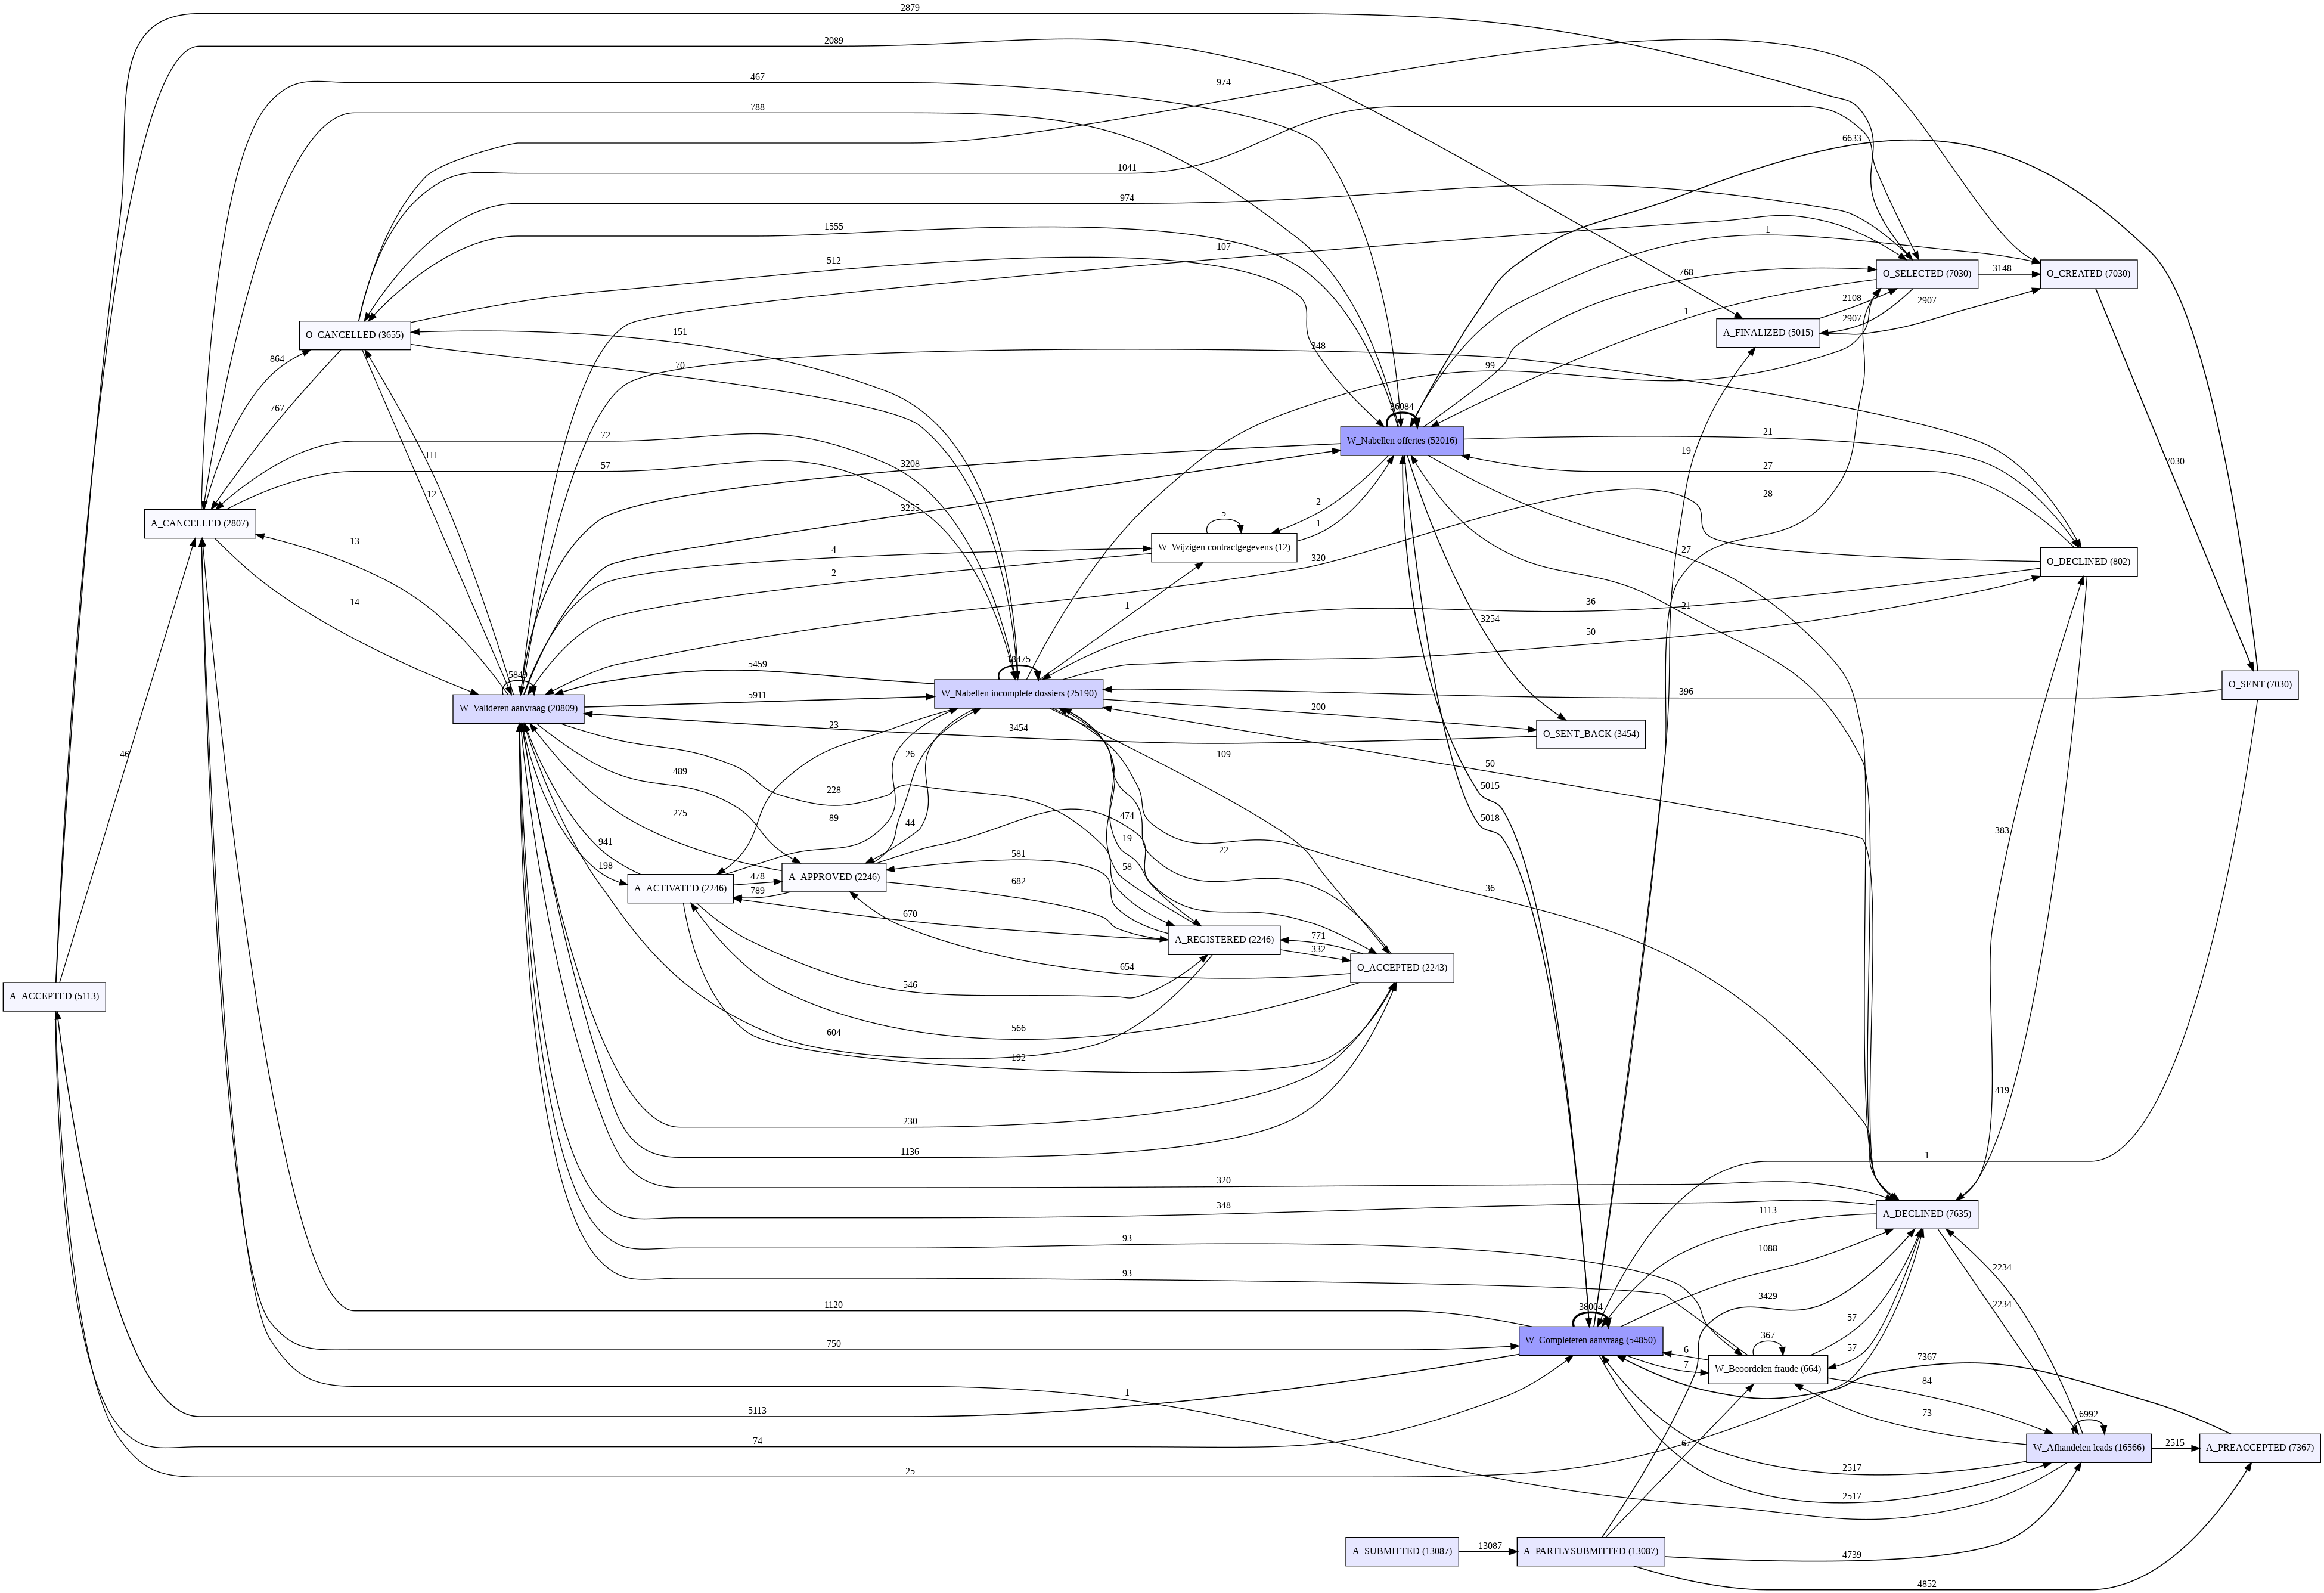


14. ¿Qué actividades aparecen al final de los casos con mayor duración?

Definición de casos largos: duración ≥ 20436.50 min
Total de casos largos: 3272 (25.0%)

Actividades finales en casos largos:
   - W_Valideren aanvraag: 1373 casos (42.0%)
   - A_CANCELLED: 647 casos (19.8%)
   - W_Nabellen offertes: 596 casos (18.2%)
   - W_Nabellen incomplete dossiers: 275 casos (8.4%)
   - O_CANCELLED: 272 casos (8.3%)
   - W_Completeren aanvraag: 106 casos (3.2%)
   - W_Wijzigen contractgegevens: 3 casos (0.1%)

PARTE 4: VISUALIZACIÓN DEL FLUJO (Preguntas 15-17)

15. Rutas paralelas y decisiones en el modelo de Petri:

Resumen de rutas paralelas (AND):
   1. Paralelo (2 ramas): Operador(X), Operador(X)
   2. Paralelo (2 ramas): Operador(X), Operador(>)
   3. Paralelo (2 ramas): Operador(X), Operador(X)
   4. Paralelo (2 ramas): Operador(X), Operador(X)
   5. Paralelo (4 ramas): Operador(X), A_APPROVED, A_REGISTERED, A_ACTIVATED
   6. Paralelo (3 ramas): Operador(X), Operador(X), Operador(X)



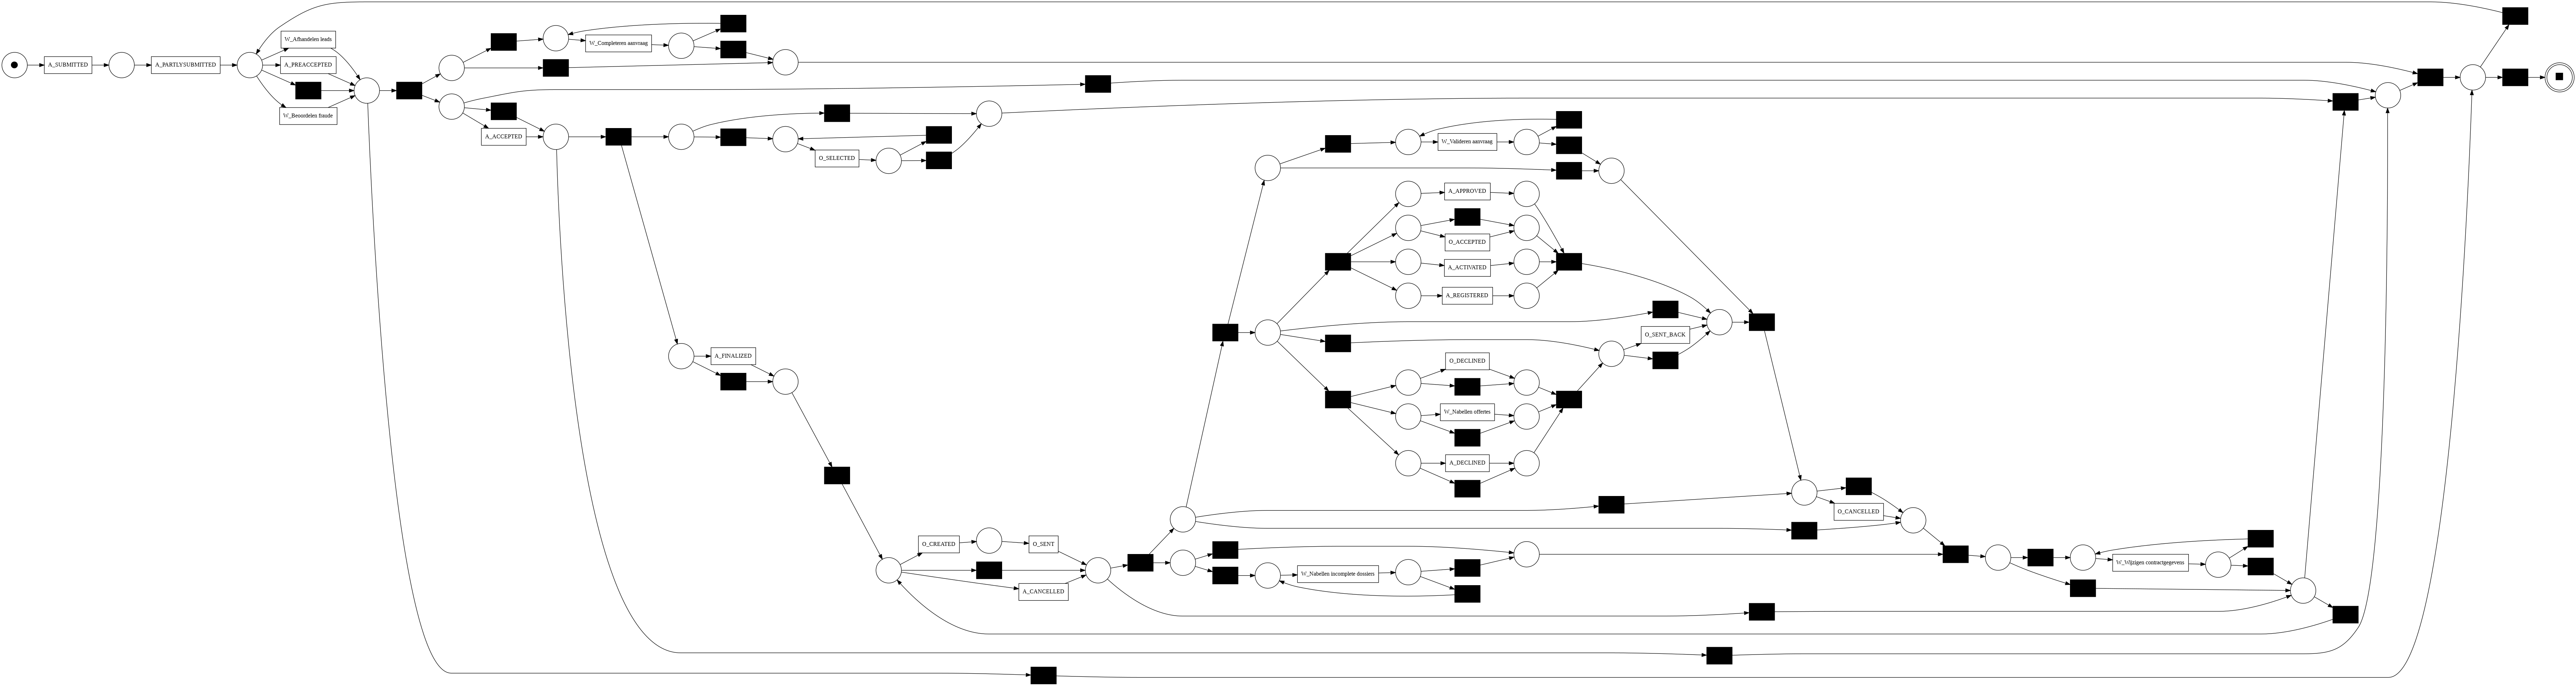


16. Transiciones comunes en el DFG:

Top 5 transiciones más comunes:
   1. W_Completeren aanvraag → W_Completeren aanvraag: 38004 veces
   2. W_Nabellen offertes → W_Nabellen offertes: 36084 veces
   3. W_Nabellen incomplete dossiers → W_Nabellen incomplete dossiers: 18475 veces
   4. A_SUBMITTED → A_PARTLYSUBMITTED: 13087 veces
   5. A_PREACCEPTED → W_Completeren aanvraag: 7367 veces

Puntos finales más comunes:
   - A_DECLINED: 3429 casos (26.2%)
   - W_Valideren aanvraag: 2747 casos (21.0%)
   - W_Afhandelen leads: 2234 casos (17.1%)
   - W_Completeren aanvraag: 1939 casos (14.8%)
   - W_Nabellen offertes: 1290 casos (9.9%)
   - A_CANCELLED: 655 casos (5.0%)
   - W_Nabellen incomplete dossiers: 452 casos (3.5%)
   - O_CANCELLED: 279 casos (2.1%)
   - W_Beoordelen fraude: 57 casos (0.4%)
   - W_Wijzigen contractgegevens: 4 casos (0.0%)
   - A_REGISTERED: 1 casos (0.0%)

17. Diagrama de Gantt y balance del flujo:

Caso con mayor duración:
   - ID: 173694
   - Duración: 197538.93 min



PARTE 5: PREGUNTAS ADICIONALES (Preguntas 18-21)

18. ¿Cuál es el promedio de eventos por ticket?
   → Promedio: 20.04 eventos por caso
   → Rango: 3 a 175 eventos

19. Duración promedio por tipo de finalización:

Duración promedio por actividad final:
   - A_DECLINED: 0.64 min (3429 casos)
   - W_Valideren aanvraag: 23982.36 min (2747 casos)
   - W_Afhandelen leads: 352.93 min (2234 casos)
   - W_Completeren aanvraag: 4161.18 min (1939 casos)
   - W_Nabellen offertes: 23332.16 min (1290 casos)
   - A_CANCELLED: 45991.70 min (655 casos)
   - W_Nabellen incomplete dossiers: 29857.85 min (452 casos)
   - O_CANCELLED: 48351.32 min (279 casos)
   - W_Beoordelen fraude: 3772.18 min (57 casos)
   - W_Wijzigen contractgegevens: 74396.15 min (4 casos)
   - A_REGISTERED: 18539.55 min (1 casos)

20. ¿Hay casos con loops o reentradas?
   → Casos con loops: 9658 (73.8%)

Actividades más repetidas en casos con loops:
   - W_Completeren aanvraag: 7367 casos
   - W_Nabellen offertes: 5011 casos
   -

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter, defaultdict
from datetime import datetime, timedelta
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_vis
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.statistics.start_activities.log.get import get_start_activities
from pm4py.statistics.end_activities.log.get import get_end_activities
from pm4py.statistics.traces.generic.log import case_statistics
from pm4py.statistics.attributes.log import get as attr_stats
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis
from pm4py.objects.process_tree.obj import Operator
import warnings
warnings.filterwarnings('ignore')

class ProcessMiningAnalyzer:
    def __init__(self, log):
        """
        Inicializa el analizador con un log de eventos
        :param log: Log de eventos en formato PM4Py o DataFrame de pandas
        """
        self.original_log = log
        self.log = self._convert_to_event_log(log)
        self.dfg = None
        self.process_tree = None
        self.petri_net = None
        self.initial_marking = None
        self.final_marking = None
        self._precompute_artifacts()

    def _convert_to_event_log(self, log):
        """Convierte el log al formato estándar de PM4Py si es necesario"""
        if isinstance(log, pd.DataFrame):
            # Asegurar que el DataFrame tiene las columnas requeridas
            required_columns = {'case:concept:name', 'concept:name', 'time:timestamp'}
            if not required_columns.issubset(log.columns):
                raise ValueError(f"El DataFrame debe contener las columnas: {required_columns}")

            # Convertir a log de eventos
            log = log_converter.apply(log, variant=log_converter.Variants.TO_EVENT_LOG)
        return log

    def _precompute_artifacts(self):
        """Precalcula artefactos comunes para optimización"""
        # Directly-Follows Graph
        self.dfg = dfg_discovery.apply(self.log)

        # Modelo de proceso (árbol y red de Petri)
        self.process_tree = inductive_miner.apply(self.log)
        self.petri_net, self.initial_marking, self.final_marking = pt_converter.apply(self.process_tree)

    def analyze_all_questions(self):
        """Ejecuta el análisis completo para las 21 preguntas"""
        print("="*80)
        print("ANÁLISIS COMPLETO DE PROCESS MINING - 21 PREGUNTAS")
        print("="*80)

        # Parte 1: Análisis básico del log (Preguntas 1-5)
        self._analyze_basic_log_stats()

        # Parte 2: Análisis de variantes (Preguntas 6-10)
        self._analyze_variants()

        # Parte 3: Cuellos de botella (Preguntas 11-14)
        self._analyze_bottlenecks()

        # Parte 4: Visualización del flujo (Preguntas 15-17)
        self._analyze_process_flow()

        # Parte 5: Preguntas adicionales (18-21)
        self._analyze_additional_questions()

        print("\n" + "="*80)
        print("ANÁLISIS COMPLETADO CON ÉXITO")
        print("="*80)

    def _analyze_basic_log_stats(self):
        """Responde preguntas 1-5: Análisis básico del log"""
        print("\n" + "="*60)
        print("PARTE 1: ANÁLISIS BÁSICO DEL LOG (Preguntas 1-5)")
        print("="*60)

        # Pregunta 1: Total de casos
        total_cases = len(self.log)
        print(f"\n1. ¿Cuántos casos (tickets) hay en total?")
        print(f"   → Total de tickets: {total_cases}")

        # Pregunta 2: Actividades más repetidas
        print(f"\n2. ¿Qué actividades se repiten en la mayoría de los casos?")
        activity_freq = attr_stats.get_attribute_values(self.log, "concept:name")
        sorted_activities = sorted(activity_freq.items(), key=lambda x: -x[1])

        print("\nFrecuencia de actividades (ordenada):")
        for activity, freq in sorted_activities[:10]:  # Mostrar top 10
            print(f"   - {activity}: {freq} ocurrencias")

        max_freq = max(activity_freq.values())
        most_frequent = [act for act, freq in activity_freq.items() if freq == max_freq]
        print(f"\nActividad(es) más frecuente(s): {', '.join(most_frequent)} ({max_freq} ocurrencias)")

        # Pregunta 3: Porcentaje de casos con "Escalamiento"
        print(f"\n3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?")
        escalamiento_cases = sum(1 for trace in self.log
                               if any(event["concept:name"] == "Escalamiento" for event in trace))
        escalamiento_percentage = (escalamiento_cases / total_cases) * 100
        print(f"   → Casos con 'Escalamiento': {escalamiento_cases} ({escalamiento_percentage:.1f}%)")

        # Pregunta 4: Análisis de finalización de casos
        print(f"\n4. Análisis de finalización de casos:")
        end_activities = get_end_activities(self.log)

        for activity, count in end_activities.items():
            print(f"   - {activity}: {count} casos ({count/total_cases*100:.1f}%)")

        # Casos con Escalamiento seguido de Cierre
        escalamiento_cierre = 0
        for trace in self.log:
            activities = [event["concept:name"] for event in trace]
            if "Escalamiento" in activities and "Cierre" in activities:
                escalamiento_index = activities.index("Escalamiento")
                cierre_index = activities.index("Cierre")
                if cierre_index > escalamiento_index:
                    escalamiento_cierre += 1

        print(f"\n   Casos con 'Escalamiento' seguido de 'Cierre': {escalamiento_cierre}")

        # Pregunta 5: Actividad que más se repite en un mismo caso
        print(f"\n5. ¿Cuál es la actividad que más veces se repite en un mismo caso?")
        max_repetitions = {}

        for trace in self.log:
            case_activities = [event["concept:name"] for event in trace]
            activity_counts = Counter(case_activities)
            most_common = activity_counts.most_common(1)[0]

            if most_common[0] not in max_repetitions or most_common[1] > max_repetitions[most_common[0]]:
                max_repetitions[most_common[0]] = most_common[1]

        if max_repetitions:
            max_count = max(max_repetitions.values())
            top_activities = [act for act, cnt in max_repetitions.items() if cnt == max_count]
            print(f"   → Máximo de repeticiones en un caso: {max_count}")
            print(f"   → Actividad(es) con este máximo: {', '.join(top_activities)}")

        # Estadísticas adicionales
        case_lengths = [len(trace) for trace in self.log]
        print(f"\n📊 Estadísticas adicionales:")
        print(f"   - Actividades únicas: {len(activity_freq)}")
        print(f"   - Promedio de eventos por caso: {np.mean(case_lengths):.1f}")
        print(f"   - Caso más corto: {min(case_lengths)} eventos")
        print(f"   - Caso más largo: {max(case_lengths)} eventos")

    def _analyze_variants(self):
        """Responde preguntas 6-10: Análisis de variantes"""
        print("\n" + "="*60)
        print("PARTE 2: ANÁLISIS DE VARIANTES (Preguntas 6-10)")
        print("="*60)

        # Obtener estadísticas de variantes
        variants = case_statistics.get_variant_statistics(self.log)
        total_cases = len(self.log)
        total_variants = len(variants)

        # Ordenar variantes por frecuencia
        sorted_variants = sorted(variants, key=lambda x: -x['count'])

        # Pregunta 6: 3 variantes más frecuentes
        print(f"\n6. ¿Cuáles son las 3 variantes más frecuentes?")
        for i, var in enumerate(sorted_variants[:3], 1):
            print(f"\nVariante {i}:")
            print(f"   Secuencia: {var['variant']}")
            print(f"   Frecuencia: {var['count']} casos ({var['count']/total_cases*100:.1f}%)")

        # Pregunta 7: Diferencias entre variantes
        print(f"\n7. ¿Cuál es la diferencia entre estas variantes?")
        if len(sorted_variants) >= 3:
            var1 = set(sorted_variants[0]['variant'])
            var2 = set(sorted_variants[1]['variant'])
            var3 = set(sorted_variants[2]['variant'])

            print("\nComparación entre las 3 variantes principales:")
            print(f"   - Actividades comunes: {var1 & var2 & var3}")
            print(f"   - Únicas en Variante 1: {var1 - var2 - var3}")
            print(f"   - Únicas en Variante 2: {var2 - var1 - var3}")
            print(f"   - Únicas en Variante 3: {var3 - var1 - var2}")

        # Pregunta 8: Variantes con más pasos
        print(f"\n8. ¿Alguna variante contiene más pasos que otras? ¿Por qué?")
        variant_lengths = [(var['variant'], len(var['variant']), var['count'])
                          for var in sorted_variants]

        # Ordenar por longitud de variante
        sorted_by_length = sorted(variant_lengths, key=lambda x: -x[1])

        print("\nTop 5 variantes con más pasos:")
        for i, (variant, length, count) in enumerate(sorted_by_length[:5], 1):
            print(f"   {i}. {length} pasos: {variant[:50]}... ({count} casos)")

        # Pregunta 9: Tiempo promedio de duración por variante
        print(f"\n9. ¿Cuál es el tiempo promedio de duración de estas variantes?")
        variant_durations = self._calculate_variant_durations(sorted_variants[:3])

        for i, (variant, duration_info) in enumerate(variant_durations.items(), 1):
            print(f"\nVariante {i}: {variant}")
            if duration_info['avg_minutes'] is not None:
                print(f"   - Duración promedio: {duration_info['avg_minutes']:.1f} min")
                print(f"   - Casos analizados: {duration_info['count']}")
                print(f"   - Rango: {duration_info['min_minutes']:.1f}-{duration_info['max_minutes']:.1f} min")
            else:
                print("   - No se pudo calcular la duración (falta timestamp)")

        # Pregunta 10: Análisis de cancelaciones
        print(f"\n10. ¿Qué se puede decir de las variantes con cancelación?")
        cancellation_variants = [var for var in sorted_variants if "Cancelación" in var['variant']]

        if cancellation_variants:
            total_cancelled = sum(var['count'] for var in cancellation_variants)
            print(f"\nResumen de cancelaciones:")
            print(f"   - Total de casos cancelados: {total_cancelled}")
            print(f"   - Porcentaje del total: {total_cancelled/total_cases*100:.1f}%")
            print(f"   - Variantes con cancelación: {len(cancellation_variants)}")

            # Actividades que preceden a cancelación
            preceding_acts = Counter()
            for var in cancellation_variants:
                activities = var['variant'].split(',')
                cancel_index = activities.index("Cancelación")
                if cancel_index > 0:
                    preceding_acts[activities[cancel_index-1]] += var['count']

            if preceding_acts:
                print("\nActividades que preceden a cancelación:")
                for act, count in preceding_acts.most_common():
                    print(f"   - {act}: {count} veces ({count/total_cancelled*100:.1f}%)")
        else:
            print("   - No se encontraron variantes con cancelación")

    def _calculate_variant_durations(self, variants):
        """Calcula duraciones para variantes específicas"""
        variant_durations = {}

        for var in variants:
            variant_str = var['variant']
            total_duration = 0
            count = 0
            min_dur = float('inf')
            max_dur = 0

            for trace in self.log:
                trace_variant = ",".join([event["concept:name"] for event in trace])
                if trace_variant == variant_str and len(trace) > 1:
                    try:
                        start = trace[0]["time:timestamp"]
                        end = trace[-1]["time:timestamp"]
                        duration = (end - start).total_seconds() / 60  # minutos
                        total_duration += duration
                        count += 1
                        min_dur = min(min_dur, duration)
                        max_dur = max(max_dur, duration)
                    except:
                        continue

            variant_durations[variant_str] = {
                'avg_minutes': total_duration / count if count > 0 else None,
                'count': count,
                'min_minutes': min_dur if count > 0 else None,
                'max_minutes': max_dur if count > 0 else None
            }

        return variant_durations

    def _analyze_bottlenecks(self):
        """Responde preguntas 11-14: Análisis de cuellos de botella"""
        print("\n" + "="*60)
        print("PARTE 3: DETECCIÓN DE CUELLOS DE BOTELLA (Preguntas 11-14)")
        print("="*60)

        # Pregunta 11: Par de actividades con mayor duración promedio
        print(f"\n11. ¿Cuál es el par de actividades con mayor duración promedio?")
        transition_durations = self._calculate_transition_durations()

        if transition_durations:
            sorted_transitions = sorted(transition_durations.items(),
                                      key=lambda x: -x[1]['avg_duration'])
            top_transition = sorted_transitions[0]

            print(f"\nPar con mayor duración promedio:")
            print(f"   {top_transition[0][0]} → {top_transition[0][1]}")
            print(f"   - Duración promedio: {top_transition[1]['avg_duration']:.2f} min")
            print(f"   - Casos analizados: {top_transition[1]['count']}")
            print(f"   - Rango: {top_transition[1]['min_duration']:.2f}-{top_transition[1]['max_duration']:.2f} min")

            # Mostrar top 5
            print("\nTop 5 pares con mayor duración promedio:")
            for i, ((src, tgt), stats) in enumerate(sorted_transitions[:5], 1):
                print(f"   {i}. {src} → {tgt}: {stats['avg_duration']:.2f} min ({stats['count']} casos)")

        # Pregunta 12: Tiempos entre actividades específicas
        print(f"\n12. Tiempos entre actividades específicas:")
        specific_transitions = [
            ("Asignación técnico", "Diagnóstico técnico"),
            ("Diagnóstico técnico", "Resolución")
        ]

        for src, tgt in specific_transitions:
            if (src, tgt) in transition_durations:
                stats = transition_durations[(src, tgt)]
                print(f"\n   {src} → {tgt}:")
                print(f"      - Duración promedio: {stats['avg_duration']:.2f} min")
                print(f"      - Casos analizados: {stats['count']}")
                print(f"      - Rango: {stats['min_duration']:.2f}-{stats['max_duration']:.2f} min")
            else:
                print(f"\n   {src} → {tgt}: No se encontraron datos")

        # Pregunta 13: Relaciones más frecuentes (DFG)
        print(f"\n13. ¿Qué relaciones entre actividades son más frecuentes según el DFG?")
        if self.dfg:
            sorted_dfg = sorted(self.dfg.items(), key=lambda x: -x[1])

            print("\nTop 10 relaciones más frecuentes:")
            for i, ((src, tgt), count) in enumerate(sorted_dfg[:10], 1):
                print(f"   {i}. {src} → {tgt}: {count} veces ({count/len(self.log)*100:.1f}%)")

            # Visualización del DFG
            print("\nGenerando visualización del DFG...")
            gviz = dfg_vis.apply(self.dfg, log=self.log, variant=dfg_vis.Variants.FREQUENCY)
            dfg_vis.view(gviz)
        else:
            print("   - No se pudo calcular el DFG")

        # Pregunta 14: Actividades al final de casos largos
        print(f"\n14. ¿Qué actividades aparecen al final de los casos con mayor duración?")
        case_stats = self._calculate_case_durations()

        if case_stats:
            # Definir casos largos (percentil 75)
            durations = [stats['duration'] for stats in case_stats.values()]
            threshold = np.percentile(durations, 75)
            long_cases = [case_id for case_id, stats in case_stats.items()
                         if stats['duration'] >= threshold]

            print(f"\nDefinición de casos largos: duración ≥ {threshold:.2f} min")
            print(f"Total de casos largos: {len(long_cases)} ({len(long_cases)/len(case_stats)*100:.1f}%)")

            # Actividades finales en casos largos
            end_activities = Counter()
            for case_id in long_cases:
                trace = next(trace for trace in self.log
                            if trace.attributes["concept:name"] == case_id)
                end_activity = trace[-1]["concept:name"]
                end_activities[end_activity] += 1

            print("\nActividades finales en casos largos:")
            for activity, count in end_activities.most_common():
                print(f"   - {activity}: {count} casos ({count/len(long_cases)*100:.1f}%)")

    def _calculate_transition_durations(self):
        """Calcula duraciones entre pares de actividades consecutivas"""
        transition_stats = {}

        for trace in self.log:
            events = sorted(trace, key=lambda x: x["time:timestamp"])

            for i in range(len(events)-1):
                src = events[i]["concept:name"]
                tgt = events[i+1]["concept:name"]
                duration = (events[i+1]["time:timestamp"] - events[i]["time:timestamp"]).total_seconds() / 60

                if (src, tgt) not in transition_stats:
                    transition_stats[(src, tgt)] = {
                        'count': 0,
                        'total_duration': 0,
                        'min_duration': float('inf'),
                        'max_duration': 0
                    }

                transition_stats[(src, tgt)]['count'] += 1
                transition_stats[(src, tgt)]['total_duration'] += duration
                transition_stats[(src, tgt)]['min_duration'] = min(
                    transition_stats[(src, tgt)]['min_duration'], duration)
                transition_stats[(src, tgt)]['max_duration'] = max(
                    transition_stats[(src, tgt)]['max_duration'], duration)

        # Calcular promedios
        for key in transition_stats:
            transition_stats[key]['avg_duration'] = (
                transition_stats[key]['total_duration'] / transition_stats[key]['count'])

        return transition_stats

    def _calculate_case_durations(self):
        """Calcula duraciones para cada caso"""
        case_stats = {}

        for trace in self.log:
            case_id = trace.attributes["concept:name"]
            events = sorted(trace, key=lambda x: x["time:timestamp"])

            if len(events) > 1:
                duration = (events[-1]["time:timestamp"] - events[0]["time:timestamp"]).total_seconds() / 60
                case_stats[case_id] = {
                    'duration': duration,
                    'num_activities': len(events),
                    'end_activity': events[-1]["concept:name"]
                }

        return case_stats

    def _analyze_process_flow(self):
        """Responde preguntas 15-17: Visualización del flujo"""
        print("\n" + "="*60)
        print("PARTE 4: VISUALIZACIÓN DEL FLUJO (Preguntas 15-17)")
        print("="*60)

        # Pregunta 15: Rutas paralelas y decisiones en el modelo de Petri
        print(f"\n15. Rutas paralelas y decisiones en el modelo de Petri:")
        parallel_routes, decisions = self._analyze_process_tree()

        print("\nResumen de rutas paralelas (AND):")
        for i, route in enumerate(parallel_routes, 1):
            print(f"   {i}. {route}")

        print("\nResumen de decisiones (XOR/LOOP):")
        for i, decision in enumerate(decisions, 1):
            print(f"   {i}. {decision}")

        # Visualización de la red de Petri
        print("\nGenerando visualización de la red de Petri...")
        gviz = pn_vis.apply(self.petri_net, self.initial_marking, self.final_marking)
        pn_vis.view(gviz)

        # Pregunta 16: Transiciones comunes en DFG
        print(f"\n16. Transiciones comunes en el DFG:")
        if self.dfg:
            sorted_dfg = sorted(self.dfg.items(), key=lambda x: -x[1])

            print("\nTop 5 transiciones más comunes:")
            for i, ((src, tgt), count) in enumerate(sorted_dfg[:5], 1):
                print(f"   {i}. {src} → {tgt}: {count} veces")

            # Puntos finales
            end_activities = get_end_activities(self.log)
            print("\nPuntos finales más comunes:")
            for activity, count in sorted(end_activities.items(), key=lambda x: -x[1]):
                print(f"   - {activity}: {count} casos ({count/len(self.log)*100:.1f}%)")
        else:
            print("   - No se pudo calcular el DFG")

        # Pregunta 17: Diagrama de Gantt y balance
        print(f"\n17. Diagrama de Gantt y balance del flujo:")
        case_stats = self._calculate_case_durations()

        if case_stats:
            # Caso con mayor duración
            longest_case = max(case_stats.items(), key=lambda x: x[1]['duration'])
            print(f"\nCaso con mayor duración:")
            print(f"   - ID: {longest_case[0]}")
            print(f"   - Duración: {longest_case[1]['duration']:.2f} min")
            print(f"   - Actividades: {longest_case[1]['num_activities']}")
            print(f"   - Actividad final: {longest_case[1]['end_activity']}")

            # Balance del flujo
            durations = [stats['duration'] for stats in case_stats.values()]
            num_activities = [stats['num_activities'] for stats in case_stats.values()]

            print(f"\nBalance del flujo:")
            print(f"   - Duración promedio: {np.mean(durations):.2f} min")
            print(f"   - Desviación estándar: {np.std(durations):.2f} min")
            print(f"   - Coeficiente de variación: {np.std(durations)/np.mean(durations):.2f}")
            print(f"\n   - Actividades promedio por caso: {np.mean(num_activities):.1f}")
            print(f"   - Desviación estándar: {np.std(num_activities):.1f}")
            print(f"   - Coeficiente de variación: {np.std(num_activities)/np.mean(num_activities):.2f}")

            # Generar diagrama de Gantt para casos representativos
            self._generate_gantt_chart(case_stats)
        else:
            print("   - No se pudieron calcular las duraciones de los casos")

    def _analyze_process_tree(self):
        """Analiza el árbol de proceso para identificar rutas paralelas y decisiones"""
        parallel_routes = []
        decisions = []

        def _analyze_node(node, level=0):
            nonlocal parallel_routes, decisions

            if hasattr(node, 'operator'):
                if node.operator == Operator.PARALLEL:
                    children = [_get_node_label(child) for child in node.children]
                    parallel_routes.append(f"Paralelo ({len(node.children)} ramas): {', '.join(children)}")

                elif node.operator in (Operator.XOR, Operator.LOOP):
                    node_type = "Decisión XOR" if node.operator == Operator.XOR else "Bucle LOOP"
                    children = [_get_node_label(child) for child in node.children]
                    decisions.append(f"{node_type} ({len(node.children)} opciones): {', '.join(children)}")

                for child in node.children:
                    _analyze_node(child, level+1)

        def _get_node_label(node):
            if hasattr(node, 'label') and node.label:
                return node.label
            elif hasattr(node, 'operator'):
                return f"Operador({str(node.operator)[-1]})"
            return "Nodo desconocido"

        _analyze_node(self.process_tree)
        return parallel_routes, decisions

    def _generate_gantt_chart(self, case_stats, num_cases=5):
        """Genera un diagrama de Gantt para casos representativos"""
        print(f"\nGenerando diagrama de Gantt para {num_cases} casos...")

        # Seleccionar casos: 2 más largos, 2 más cortos y 1 promedio
        sorted_cases = sorted(case_stats.items(), key=lambda x: x[1]['duration'])
        selected_cases = []

        # Casos más cortos
        selected_cases.extend(sorted_cases[:1])
        # Casos promedio
        mid_index = len(sorted_cases) // 2
        selected_cases.append(sorted_cases[mid_index])
        # Casos más largos
        selected_cases.extend(sorted_cases[-2:])

        # Preparar datos para Gantt
        gantt_data = []

        for case_id, stats in selected_cases:
            trace = next(trace for trace in self.log
                        if trace.attributes["concept:name"] == case_id)
            events = sorted(trace, key=lambda x: x["time:timestamp"])

            for i in range(len(events)):
                start = events[i]["time:timestamp"]
                end = events[i+1]["time:timestamp"] if i < len(events)-1 else start + timedelta(minutes=30)

                gantt_data.append({
                    "Caso": f"{case_id} ({stats['duration']:.1f} min)",
                    "Actividad": events[i]["concept:name"],
                    "Inicio": start,
                    "Fin": end,
                    "Duración": (end - start).total_seconds() / 60
                })

        # Crear gráfico con Plotly
        fig = px.timeline(
            pd.DataFrame(gantt_data),
            x_start="Inicio",
            x_end="Fin",
            y="Caso",
            color="Actividad",
            title="Diagrama de Gantt - Casos Representativos",
            width=1000,
            height=500
        )

        fig.update_yaxes(autorange="reversed")
        fig.show()

    def _analyze_additional_questions(self):
        """Responde preguntas 18-21: Preguntas adicionales"""
        print("\n" + "="*60)
        print("PARTE 5: PREGUNTAS ADICIONALES (Preguntas 18-21)")
        print("="*60)

        # Pregunta 18: Promedio de eventos por ticket
        print(f"\n18. ¿Cuál es el promedio de eventos por ticket?")
        events_per_case = [len(trace) for trace in self.log]
        print(f"   → Promedio: {np.mean(events_per_case):.2f} eventos por caso")
        print(f"   → Rango: {min(events_per_case)} a {max(events_per_case)} eventos")

        # Pregunta 19: Duración promedio por tipo de finalización
        print(f"\n19. Duración promedio por tipo de finalización:")
        case_stats = self._calculate_case_durations()
        end_activities = get_end_activities(self.log)

        if case_stats and end_activities:
            duration_by_end = defaultdict(list)

            for case_id, stats in case_stats.items():
                duration_by_end[stats['end_activity']].append(stats['duration'])

            print("\nDuración promedio por actividad final:")
            for activity, durations in sorted(duration_by_end.items(),
                                            key=lambda x: -len(x[1])):
                print(f"   - {activity}: {np.mean(durations):.2f} min ({len(durations)} casos)")
        else:
            print("   - No se pudieron calcular las duraciones")

        # Pregunta 20: Casos con loops o reentradas
        print(f"\n20. ¿Hay casos con loops o reentradas?")
        loop_cases = []

        for trace in self.log:
            activities = [event["concept:name"] for event in trace]
            if len(activities) != len(set(activities)):
                loop_cases.append(trace.attributes["concept:name"])

        print(f"   → Casos con loops: {len(loop_cases)} ({len(loop_cases)/len(self.log)*100:.1f}%)")

        if loop_cases:
            # Actividades más repetidas en loops
            repeated_acts = Counter()

            for trace in self.log:
                if trace.attributes["concept:name"] in loop_cases:
                    activities = [event["concept:name"] for event in trace]
                    activity_counts = Counter(activities)
                    for act, count in activity_counts.items():
                        if count > 1:
                            repeated_acts[act] += 1

            print("\nActividades más repetidas en casos con loops:")
            for act, count in repeated_acts.most_common(5):
                print(f"   - {act}: {count} casos")

        # Pregunta 21: Promedio de repeticiones por caso
        print(f"\n21. ¿Cuál es el promedio de repeticiones por caso?")
        repetitions = []

        for trace in self.log:
            activities = [event["concept:name"] for event in trace]
            unique_activities = set(activities)
            repetitions.append(len(activities) - len(unique_activities))

        print(f"   → Promedio de repeticiones: {np.mean(repetitions):.2f} por caso")
        print(f"   → Casos con repeticiones: {sum(1 for r in repetitions if r > 0)}")
        print(f"   → Máximo de repeticiones: {max(repetitions)} en un caso")

# Ejemplo de uso:
# Cargar datos (ejemplo con DataFrame)
data = pd.read_csv('output_log.csv')
data['time:timestamp'] = pd.to_datetime(data['time:timestamp'])

# Crear analizador y ejecutar análisis completo
analyzer = ProcessMiningAnalyzer(data)
analyzer.analyze_all_questions()

ANÁLISIS COMPLETO DE PROCESS MINING - 21 PREGUNTAS

PARTE 1: ANÁLISIS BÁSICO DEL LOG (Preguntas 1-5)

1. ¿Cuántos casos (tickets) hay en total?
   → Total de tickets: 13087

2. ¿Qué actividades se repiten en la mayoría de los casos?

Frecuencia de actividades (ordenada):
   - W_Completeren aanvraag: 54850 ocurrencias
   - W_Nabellen offertes: 52016 ocurrencias
   - W_Nabellen incomplete dossiers: 25190 ocurrencias
   - W_Valideren aanvraag: 20809 ocurrencias
   - W_Afhandelen leads: 16566 ocurrencias
   - A_SUBMITTED: 13087 ocurrencias
   - A_PARTLYSUBMITTED: 13087 ocurrencias
   - A_DECLINED: 7635 ocurrencias
   - A_PREACCEPTED: 7367 ocurrencias
   - O_SELECTED: 7030 ocurrencias

Actividad(es) más frecuente(s): W_Completeren aanvraag (54850 ocurrencias)

3. ¿Qué porcentaje de casos contiene la actividad 'Escalamiento'?
   → Casos con 'Escalamiento': 0 (0.0%)

4. Análisis de finalización de casos:
   - W_Valideren aanvraag: 2747 casos (21.0%)
   - W_Wijzigen contractgegevens: 4 casos (

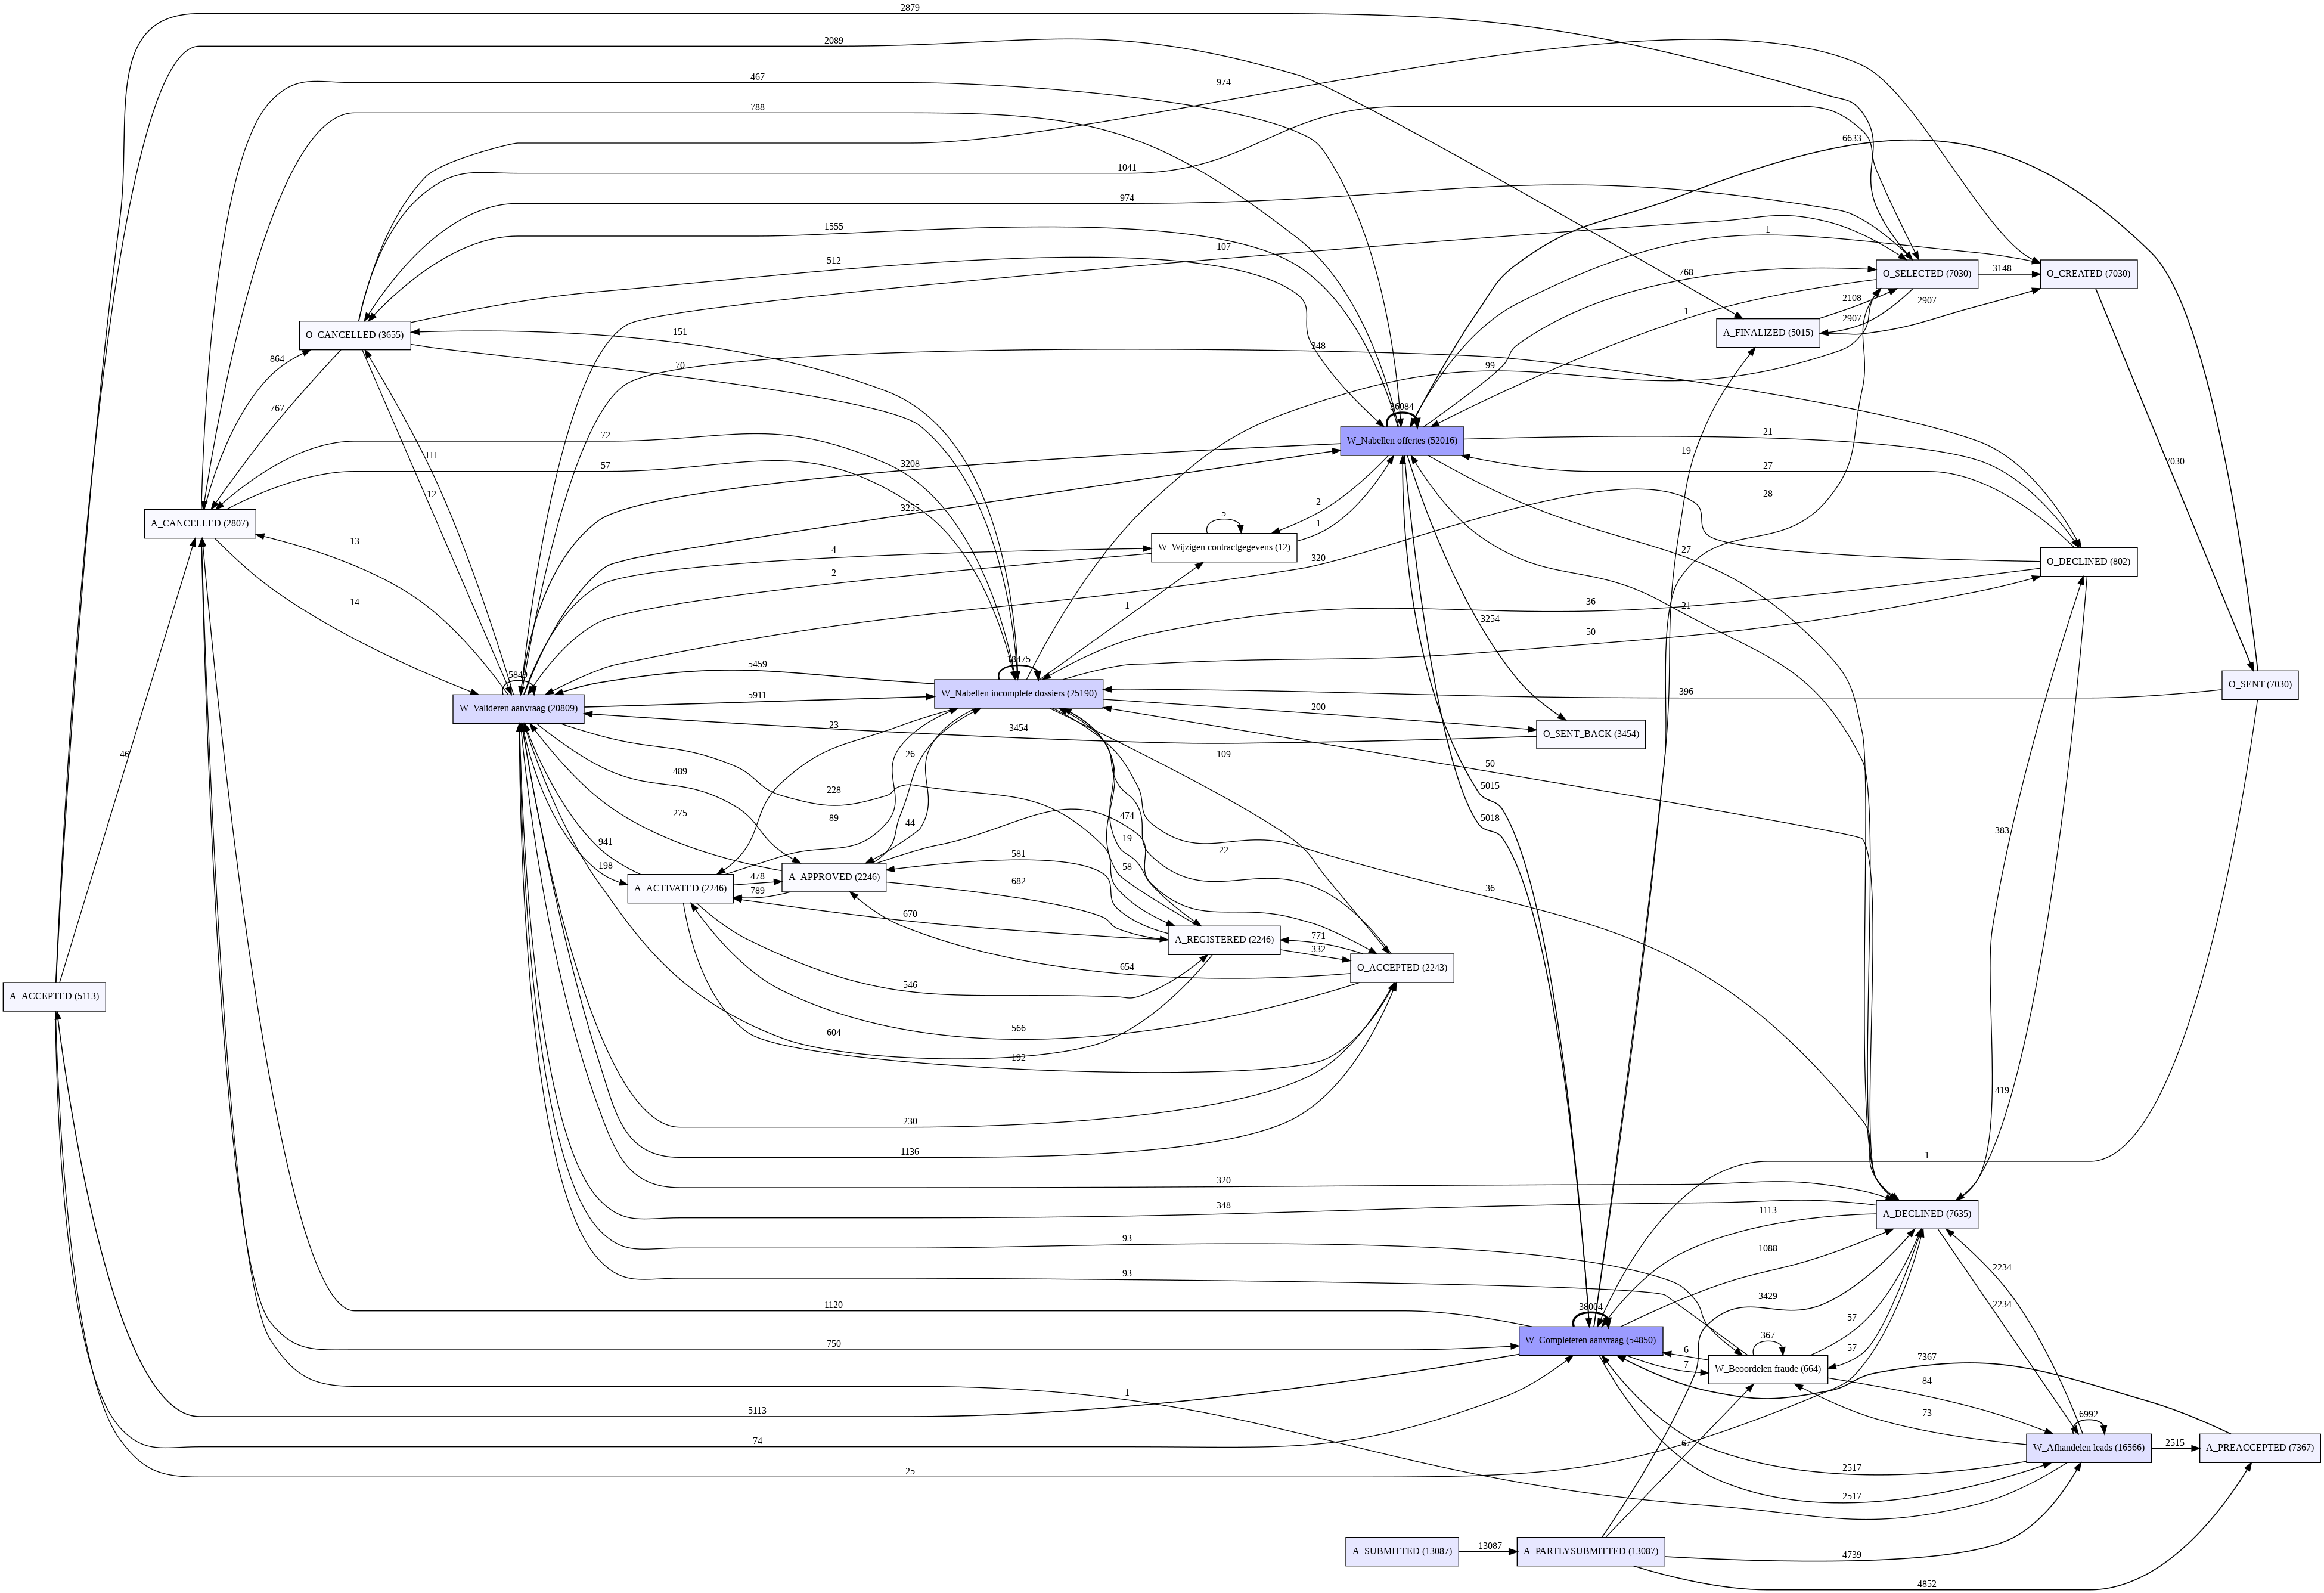


14. ¿Qué actividades aparecen al final de los casos con mayor duración?

Definición de casos largos: duración ≥ 20436.50 min
Total de casos largos: 3272 (25.0%)

Actividades finales en casos largos:
   - W_Valideren aanvraag: 1373 casos (42.0%)
   - A_CANCELLED: 647 casos (19.8%)
   - W_Nabellen offertes: 596 casos (18.2%)
   - W_Nabellen incomplete dossiers: 275 casos (8.4%)
   - O_CANCELLED: 272 casos (8.3%)
   - W_Completeren aanvraag: 106 casos (3.2%)
   - W_Wijzigen contractgegevens: 3 casos (0.1%)

PARTE 4: VISUALIZACIÓN DEL FLUJO (Preguntas 15-17)

15. Rutas paralelas y decisiones en el modelo de Petri:

Resumen de rutas paralelas (AND):
   1. Paralelo (2 ramas): Operador(X), Operador(X)
   2. Paralelo (2 ramas): Operador(X), Operador(>)
   3. Paralelo (2 ramas): Operador(X), Operador(X)
   4. Paralelo (2 ramas): Operador(X), Operador(X)
   5. Paralelo (4 ramas): Operador(X), A_APPROVED, A_REGISTERED, A_ACTIVATED
   6. Paralelo (3 ramas): Operador(X), Operador(X), Operador(X)



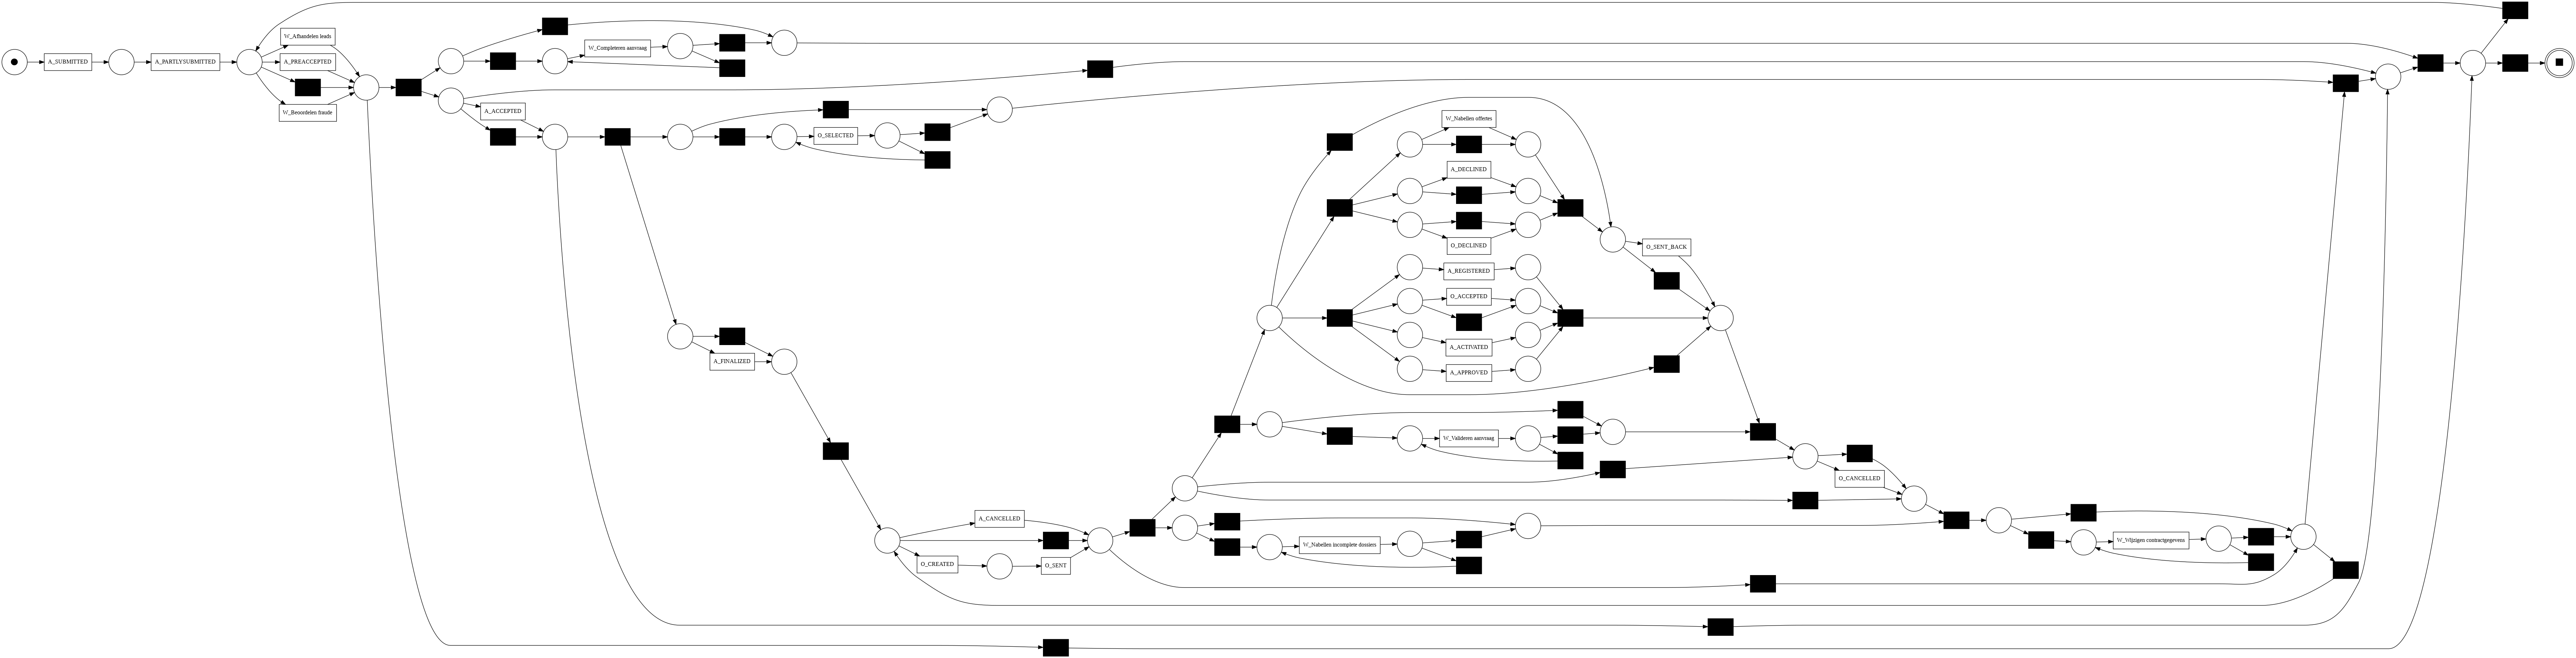


16. Transiciones comunes en el DFG:

Top 5 transiciones más comunes:
   1. W_Completeren aanvraag → W_Completeren aanvraag: 38004 veces
   2. W_Nabellen offertes → W_Nabellen offertes: 36084 veces
   3. W_Nabellen incomplete dossiers → W_Nabellen incomplete dossiers: 18475 veces
   4. A_SUBMITTED → A_PARTLYSUBMITTED: 13087 veces
   5. A_PREACCEPTED → W_Completeren aanvraag: 7367 veces

Puntos finales más comunes:
   - A_DECLINED: 3429 casos (26.2%)
   - W_Valideren aanvraag: 2747 casos (21.0%)
   - W_Afhandelen leads: 2234 casos (17.1%)
   - W_Completeren aanvraag: 1939 casos (14.8%)
   - W_Nabellen offertes: 1290 casos (9.9%)
   - A_CANCELLED: 655 casos (5.0%)
   - W_Nabellen incomplete dossiers: 452 casos (3.5%)
   - O_CANCELLED: 279 casos (2.1%)
   - W_Beoordelen fraude: 57 casos (0.4%)
   - W_Wijzigen contractgegevens: 4 casos (0.0%)
   - A_REGISTERED: 1 casos (0.0%)

17. Diagrama de Gantt y balance del flujo:

Caso con mayor duración:
   - ID: 173694
   - Duración: 197538.93 min



PARTE 5: PREGUNTAS ADICIONALES (Preguntas 18-21)

18. ¿Cuál es el promedio de eventos por ticket?
   → Promedio: 20.04 eventos por caso
   → Rango: 3 a 175 eventos

19. Duración promedio por tipo de finalización:

Duración promedio por actividad final:
   - A_DECLINED: 0.64 min (3429 casos)
   - W_Valideren aanvraag: 23982.36 min (2747 casos)
   - W_Afhandelen leads: 352.93 min (2234 casos)
   - W_Completeren aanvraag: 4161.18 min (1939 casos)
   - W_Nabellen offertes: 23332.16 min (1290 casos)
   - A_CANCELLED: 45991.70 min (655 casos)
   - W_Nabellen incomplete dossiers: 29857.85 min (452 casos)
   - O_CANCELLED: 48351.32 min (279 casos)
   - W_Beoordelen fraude: 3772.18 min (57 casos)
   - W_Wijzigen contractgegevens: 74396.15 min (4 casos)
   - A_REGISTERED: 18539.55 min (1 casos)

20. ¿Hay casos con loops o reentradas?
   → Casos con loops: 9658 (73.8%)

Actividades más repetidas en casos con loops:
   - W_Completeren aanvraag: 7367 casos
   - W_Nabellen offertes: 5011 casos
   -

In [ ]:
# Extensión de la clase ProcessMiningAnalyzer para conclusiones y recomendaciones

def _analyze_conclusions_and_improvements(self):
    """
    Análisis final: Conclusiones y mejoras del proceso
    Responde a las preguntas de debate y genera recomendaciones estratégicas
    """
    print("\n" + "="*80)
    print("PARTE FINAL: CONCLUSIONES Y MEJORA DEL PROCESO")
    print("="*80)

    # Recopilar datos para el análisis
    analysis_data = self._collect_comprehensive_data()

    # 1. Hallazgos clave del proceso
    self._identify_key_findings(analysis_data)

    # 2. Decisiones como jefe del área técnica
    self._management_decisions(analysis_data)

    # 3. Oportunidades de automatización
    self._automation_opportunities(analysis_data)

    # 4. Recomendaciones al área de soporte
    self._support_recommendations(analysis_data)

    # Resumen ejecutivo
    self._generate_executive_summary(analysis_data)

def _collect_comprehensive_data(self):
    """Recopila todos los datos necesarios para el análisis final"""
    print("\n🔍 Recopilando datos para análisis integral...")

    # Estadísticas básicas
    total_cases = len(self.log)
    case_lengths = [len(trace) for trace in self.log]

    # Actividades
    activity_freq = attr_stats.get_attribute_values(self.log, "concept:name")

    # Variantes
    variants = case_statistics.get_variant_statistics(self.log)
    sorted_variants = sorted(variants, key=lambda x: -x['count'])

    # Duraciones
    case_stats = self._calculate_case_durations()
    transition_durations = self._calculate_transition_durations()

    # Análisis de problemas
    escalamiento_cases = sum(1 for trace in self.log
                           if any(event["concept:name"] == "Escalamiento" for event in trace))

    cancellation_cases = sum(1 for trace in self.log
                           if any(event["concept:name"] == "Cancelación" for event in trace))

    # Casos con loops
    loop_cases = []
    for trace in self.log:
        activities = [event["concept:name"] for event in trace]
        if len(activities) != len(set(activities)):
            loop_cases.append(trace.attributes["concept:name"])

    # Análisis temporal
    durations = [stats['duration'] for stats in case_stats.values()] if case_stats else []

    return {
        'total_cases': total_cases,
        'case_lengths': case_lengths,
        'activity_freq': activity_freq,
        'variants': sorted_variants,
        'case_stats': case_stats,
        'transition_durations': transition_durations,
        'escalamiento_cases': escalamiento_cases,
        'cancellation_cases': cancellation_cases,
        'loop_cases': loop_cases,
        'durations': durations,
        'total_variants': len(variants)
    }

def _identify_key_findings(self, data):
    """1. Identifica y presenta los hallazgos clave del proceso"""
    print("\n" + "="*60)
    print("1. HALLAZGOS CLAVE DEL PROCESO")
    print("="*60)

    print("\n🎯 **HALLAZGOS PRINCIPALES:**")

    # Complejidad del proceso
    complexity_score = self._calculate_process_complexity(data)
    print(f"\n📊 **Complejidad del Proceso:**")
    print(f"   • Total de casos analizados: {data['total_cases']:,}")
    print(f"   • Variantes únicas identificadas: {data['total_variants']}")
    print(f"   • Índice de complejidad: {complexity_score:.2f}/10")
    print(f"   • Actividades únicas: {len(data['activity_freq'])}")

    # Variabilidad
    if data['durations']:
        cv_duration = np.std(data['durations']) / np.mean(data['durations'])
        cv_length = np.std(data['case_lengths']) / np.mean(data['case_lengths'])

        print(f"\n📈 **Variabilidad del Proceso:**")
        print(f"   • Coeficiente de variación en duración: {cv_duration:.2f}")
        print(f"   • Coeficiente de variación en longitud: {cv_length:.2f}")
        print(f"   • Interpretación: {'ALTA' if cv_duration > 0.5 else 'MEDIA' if cv_duration > 0.3 else 'BAJA'} variabilidad")

    # Problemas identificados
    print(f"\n⚠️ **Problemas Identificados:**")
    escalamiento_rate = (data['escalamiento_cases'] / data['total_cases']) * 100
    cancellation_rate = (data['cancellation_cases'] / data['total_cases']) * 100
    loop_rate = (len(data['loop_cases']) / data['total_cases']) * 100

    print(f"   • Tasa de escalamiento: {escalamiento_rate:.1f}% ({data['escalamiento_cases']} casos)")
    print(f"   • Tasa de cancelación: {cancellation_rate:.1f}% ({data['cancellation_cases']} casos)")
    print(f"   • Casos con retrabajos: {loop_rate:.1f}% ({len(data['loop_cases'])} casos)")

    # Eficiencia del proceso
    if data['case_stats']:
        durations = data['durations']
        efficiency_metrics = {
            'promedio': np.mean(durations),
            'mediana': np.median(durations),
            'percentil_90': np.percentile(durations, 90),
            'casos_rapidos': sum(1 for d in durations if d < np.percentile(durations, 25))
        }

        print(f"\n⏱️ **Métricas de Eficiencia:**")
        print(f"   • Tiempo promedio de resolución: {efficiency_metrics['promedio']:.1f} minutos")
        print(f"   • Tiempo mediano: {efficiency_metrics['mediana']:.1f} minutos")
        print(f"   • 90% de casos se resuelven en: {efficiency_metrics['percentil_90']:.1f} minutos")
        print(f"   • Casos resueltos rápidamente: {efficiency_metrics['casos_rapidos']} ({efficiency_metrics['casos_rapidos']/data['total_cases']*100:.1f}%)")

    # Cuellos de botella
    if data['transition_durations']:
        bottlenecks = sorted(data['transition_durations'].items(),
                           key=lambda x: -x[1]['avg_duration'])[:3]

        print(f"\n🚧 **Principales Cuellos de Botella:**")
        for i, ((src, tgt), stats) in enumerate(bottlenecks, 1):
            print(f"   {i}. {src} → {tgt}: {stats['avg_duration']:.1f} min promedio")

def _calculate_process_complexity(self, data):
    """Calcula un índice de complejidad del proceso (0-10)"""
    # Factores de complejidad
    variant_complexity = min(data['total_variants'] / data['total_cases'] * 10, 3)
    activity_complexity = min(len(data['activity_freq']) / 10, 2)
    length_complexity = min(np.mean(data['case_lengths']) / 5, 2)

    cv_duration = np.std(data['durations']) / np.mean(data['durations']) if data['durations'] else 0
    variability_complexity = min(cv_duration * 3, 3)

    return variant_complexity + activity_complexity + length_complexity + variability_complexity

def _management_decisions(self, data):
    """2. Decisiones que tomaría como jefe del área técnica"""
    print("\n" + "="*60)
    print("2. DECISIONES COMO JEFE DEL ÁREA TÉCNICA")
    print("="*60)

    print("\n🎯 **DECISIONES ESTRATÉGICAS INMEDIATAS:**")

    # Priorización basada en datos
    escalamiento_rate = (data['escalamiento_cases'] / data['total_cases']) * 100

    if escalamiento_rate > 20:
        print(f"\n🔥 **PRIORIDAD ALTA - Reducir Escalamientos:**")
        print(f"   • Situación actual: {escalamiento_rate:.1f}% de casos escalan")
        print(f"   • Decisión: Implementar programa de capacitación técnica urgente")
        print(f"   • Objetivo: Reducir escalamiento a <15% en 3 meses")
        print(f"   • Acciones:")
        print(f"     - Identificar técnicos con mayor tasa de escalamiento")
        print(f"     - Crear plan de mentoring con técnicos senior")
        print(f"     - Implementar base de conocimiento actualizada")

    # Análisis de recursos
    if data['case_stats']:
        durations = data['durations']
        long_cases = sum(1 for d in durations if d > np.percentile(durations, 75))

        print(f"\n📊 **OPTIMIZACIÓN DE RECURSOS:**")
        print(f"   • Casos que toman >75% del tiempo: {long_cases}")
        print(f"   • Decisión: Crear equipo especializado para casos complejos")
        print(f"   • Implementar sistema de triaje automático")
        print(f"   • Asignar técnicos senior a casos predictivamente complejos")

    # Mejora de procesos
    if len(data['loop_cases']) > 0:
        loop_rate = (len(data['loop_cases']) / data['total_cases']) * 100
        print(f"\n🔄 **REDUCCIÓN DE RETRABAJOS:**")
        print(f"   • Casos con retrabajos: {loop_rate:.1f}%")
        print(f"   • Decisión: Implementar checkpoints de calidad")
        print(f"   • Crear checklist de verificación antes de cierre")
        print(f"   • Establecer métricas de calidad por técnico")

    # Tecnología y herramientas
    print(f"\n💻 **INVERSIÓN EN TECNOLOGÍA:**")
    print(f"   • Implementar herramientas de diagnóstico automático")
    print(f"   • Desarrollar sistema predictivo de complejidad de casos")
    print(f"   • Integrar chatbot para resolución de casos simples")
    print(f"   • ROI esperado: Reducción 25% en tiempo promedio de resolución")

    # Métricas y KPIs
    print(f"\n📈 **NUEVOS KPIs A IMPLEMENTAR:**")
    print(f"   • Tiempo promedio de primera resolución (MTTR)")
    print(f"   • Tasa de escalamiento por técnico")
    print(f"   • Índice de satisfacción del cliente post-resolución")
    print(f"   • Porcentaje de casos resueltos en primer contacto")

def _automation_opportunities(self, data):
    """3. Identifica oportunidades de automatización"""
    print("\n" + "="*60)
    print("3. OPORTUNIDADES DE AUTOMATIZACIÓN Y ELIMINACIÓN")
    print("="*60)

    print("\n🤖 **PROCESOS CANDIDATOS PARA AUTOMATIZACIÓN:**")

    # Actividades repetitivas
    high_freq_activities = [(act, freq) for act, freq in data['activity_freq'].items()
                           if freq > data['total_cases'] * 0.7]

    if high_freq_activities:
        print(f"\n⚡ **Automatización de Alta Prioridad:**")
        for activity, freq in high_freq_activities:
            automation_potential = self._assess_automation_potential(activity, freq, data['total_cases'])
            print(f"   • {activity}:")
            print(f"     - Frecuencia: {freq} casos ({freq/data['total_cases']*100:.1f}%)")
            print(f"     - Potencial de automatización: {automation_potential['score']}/10")
            print(f"     - Recomendación: {automation_potential['recommendation']}")

    # Eliminar actividades redundantes
    print(f"\n❌ **ACTIVIDADES CANDIDATAS PARA ELIMINACIÓN:**")

    # Buscar patrones de actividades que no agregan valor
    redundant_patterns = self._identify_redundant_activities(data)

    for pattern in redundant_patterns:
        print(f"   • {pattern['description']}")
        print(f"     - Impacto: {pattern['impact']}")
        print(f"     - Ahorro estimado: {pattern['savings']}")

    # Simplificación del flujo
    print(f"\n🔧 **SIMPLIFICACIÓN DEL FLUJO:**")

    if data['total_variants'] > data['total_cases'] * 0.5:
        print(f"   • Excesiva variabilidad detectada ({data['total_variants']} variantes)")
        print(f"   • Recomendación: Estandarizar proceso principal")
        print(f"   • Crear 3-5 flujos estándar que cubran 80% de casos")
        print(f"   • Beneficio: Reducción 30-40% en tiempo de entrenamiento")

    # Automatización inteligente
    print(f"\n🧠 **AUTOMATIZACIÓN INTELIGENTE RECOMENDADA:**")

    automation_roadmap = [
        {
            'fase': 'Fase 1 (1-3 meses)',
            'acciones': [
                'Automatizar asignación inicial de tickets',
                'Implementar respuestas automáticas para consultas comunes',
                'Auto-escalamiento basado en tiempo de respuesta'
            ]
        },
        {
            'fase': 'Fase 2 (3-6 meses)',
            'acciones': [
                'Diagnóstico automático para problemas comunes',
                'Sugerencias de solución basadas en casos históricos',
                'Detección automática de patrones de falla'
            ]
        },
        {
            'fase': 'Fase 3 (6-12 meses)',
            'acciones': [
                'Resolución automática de casos simples',
                'Predicción de escalamiento',
                'Optimización dinámica de asignación de recursos'
            ]
        }
    ]

    for fase in automation_roadmap:
        print(f"\n   📅 **{fase['fase']}**")
        for accion in fase['acciones']:
            print(f"      • {accion}")

def _assess_automation_potential(self, activity, frequency, total_cases):
    """Evalúa el potencial de automatización de una actividad"""
    base_score = 0
    recommendation = ""

    # Frecuencia (más frecuente = mayor potencial)
    freq_score = min((frequency / total_cases) * 10, 4)
    base_score += freq_score

    # Tipo de actividad
    if any(keyword in activity.lower() for keyword in ['asignación', 'notificación', 'registro']):
        base_score += 3
        recommendation = "ALTA - Proceso administrativo automatizable"
    elif any(keyword in activity.lower() for keyword in ['diagnóstico', 'análisis']):
        base_score += 2
        recommendation = "MEDIA - Requiere IA/ML para automatización"
    elif any(keyword in activity.lower() for keyword in ['escalamiento', 'resolución']):
        base_score += 1
        recommendation = "BAJA - Requiere intervención humana especializada"
    else:
        recommendation = "EVALUAR - Requiere análisis detallado"

    return {
        'score': min(base_score, 10),
        'recommendation': recommendation
    }

def _identify_redundant_activities(self, data):
    """Identifica patrones de actividades redundantes"""
    redundant_patterns = []

    # Buscar actividades que aparecen múltiples veces en el mismo caso
    for trace in self.log:
        activities = [event["concept:name"] for event in trace]
        activity_counts = Counter(activities)

        for activity, count in activity_counts.items():
            if count > 2:  # Se repite más de 2 veces
                redundant_patterns.append({
                    'description': f'Actividad "{activity}" se repite {count} veces en casos',
                    'impact': f'Genera demoras innecesarias',
                    'savings': f'Potencial ahorro: {count-1} pasos por caso'
                })
                break  # Solo reportar uno por caso

    # Agrupar patrones similares
    unique_patterns = []
    seen_activities = set()

    for pattern in redundant_patterns:
        activity = pattern['description'].split('"')[1]
        if activity not in seen_activities:
            unique_patterns.append(pattern)
            seen_activities.add(activity)

    return unique_patterns[:5]  # Limitar a top 5

def _support_recommendations(self, data):
    """4. Recomendaciones específicas al área de soporte"""
    print("\n" + "="*60)
    print("4. RECOMENDACIONES AL ÁREA DE SOPORTE")
    print("="*60)

    print("\n📋 **RECOMENDACIONES OPERATIVAS:**")

    # Capacitación y desarrollo
    escalamiento_rate = (data['escalamiento_cases'] / data['total_cases']) * 100

    print(f"\n🎓 **Capacitación y Desarrollo:**")
    if escalamiento_rate > 15:
        print(f"   • URGENTE: Programa intensivo de capacitación técnica")
        print(f"   • Tasa actual de escalamiento: {escalamiento_rate:.1f}% (objetivo: <10%)")

    print(f"   • Implementar certificaciones por niveles de complejidad")
    print(f"   • Crear biblioteca de casos de estudio basada en datos reales")
    print(f"   • Establecer programa de mentoring técnico senior-junior")
    print(f"   • Rotación mensual en diferentes tipos de problemas")

    # Mejora de procesos
    print(f"\n⚙️ **Mejora de Procesos:**")

    if data['case_stats']:
        avg_duration = np.mean(data['durations'])
        print(f"   • Tiempo promedio actual: {avg_duration:.1f} minutos")
        print(f"   • Objetivo: Reducir a {avg_duration*0.8:.1f} minutos (20% mejora)")

    print(f"   • Implementar sistema de triaje automático")
    print(f"   • Crear templates de respuesta para casos comunes")
    print(f"   • Establecer SLAs diferenciados por complejidad")
    print(f"   • Implementar escalamiento proactivo preventivo")

    # Herramientas y tecnología
    print(f"\n💼 **Herramientas y Tecnología:**")
    print(f"   • Base de conocimiento inteligente con búsqueda semántica")
    print(f"   • Dashboard en tiempo real con métricas de performance")
    print(f"   • Sistema de sugerencias automáticas basado en historial")
    print(f"   • Integración con herramientas de monitoreo proactivo")

    # Métricas y seguimiento
    print(f"\n📊 **Métricas y Seguimiento:**")
    print(f"   • KPI principal: Tiempo medio de resolución (MTTR)")
    print(f"   • KPI calidad: Tasa de reapertura de casos (<5%)")
    print(f"   • KPI eficiencia: Casos resueltos en primer contacto (>70%)")
    print(f"   • KPI satisfacción: Puntuación cliente post-resolución (>4.5/5)")

    # Organización del equipo
    if len(data['loop_cases']) > data['total_cases'] * 0.1:
        print(f"\n👥 **Reorganización del Equipo:**")
        print(f"   • Crear equipo especializado para casos complejos")
        print(f"   • Implementar sistema de buddy para casos escalados")
        print(f"   • Establecer rotación para evitar burnout")
        print(f"   • Crear roles especializados por tipo de tecnología")

    # Comunicación y feedback
    print(f"\n💬 **Comunicación y Feedback:**")
    print(f"   • Reuniones semanales de revisión de casos complejos")
    print(f"   • Sistema de feedback continuo con clientes")
    print(f"   • Compartir lecciones aprendidas mensualmente")
    print(f"   • Canal de comunicación directa con desarrollo/producto")

def _generate_executive_summary(self, data):
    """Genera un resumen ejecutivo con las principales conclusiones"""
    print("\n" + "="*80)
    print("RESUMEN EJECUTIVO - CONCLUSIONES Y RECOMENDACIONES")
    print("="*80)

    # Situación actual
    escalamiento_rate = (data['escalamiento_cases'] / data['total_cases']) * 100
    loop_rate = (len(data['loop_cases']) / data['total_cases']) * 100
    avg_duration = np.mean(data['durations']) if data['durations'] else 0

    print(f"\n📈 **SITUACIÓN ACTUAL:**")
    print(f"   • {data['total_cases']:,} casos analizados con {data['total_variants']} variantes únicas")
    print(f"   • Tiempo promedio de resolución: {avg_duration:.1f} minutos")
    print(f"   • Tasa de escalamiento: {escalamiento_rate:.1f}%")
    print(f"   • Casos con retrabajos: {loop_rate:.1f}%")

    # Problemas críticos
    print(f"\n⚠️ **PROBLEMAS CRÍTICOS IDENTIFICADOS:**")

    critical_issues = []
    if escalamiento_rate > 20:
        critical_issues.append(f"Alta tasa de escalamiento ({escalamiento_rate:.1f}%)")
    if loop_rate > 15:
        critical_issues.append(f"Excesivos retrabajos ({loop_rate:.1f}%)")
    if data['total_variants'] > data['total_cases'] * 0.6:
        critical_issues.append("Excesiva variabilidad en el proceso")

    for i, issue in enumerate(critical_issues, 1):
        print(f"   {i}. {issue}")

    # Oportunidades de mejora
    print(f"\n🎯 **OPORTUNIDADES DE MEJORA PRINCIPALES:**")

    potential_savings = self._calculate_improvement_potential(data)

    print(f"   • Automatización: Potencial reducción {potential_savings['automation']:.0f}% tiempo")
    print(f"   • Capacitación: Reducción {potential_savings['training']:.0f}% escalamientos")
    print(f"   • Estandarización: Ahorro {potential_savings['standardization']:.0f}% variabilidad")
    print(f"   • Tecnología: Mejora {potential_savings['technology']:.0f}% eficiencia general")

    # ROI estimado
    print(f"\n💰 **RETORNO DE INVERSIÓN ESTIMADO:**")

    monthly_cases = data['total_cases']  # Asumiendo datos mensuales
    avg_cost_per_case = 50  # Estimación

    current_monthly_cost = monthly_cases * avg_cost_per_case
    potential_monthly_savings = current_monthly_cost * (sum(potential_savings.values()) / 100 / 4)
    annual_savings = potential_monthly_savings * 12

    print(f"   • Costo operativo actual estimado: ${current_monthly_cost:,.0f}/mes")
    print(f"   • Ahorro potencial estimado: ${potential_monthly_savings:,.0f}/mes")
    print(f"   • ROI anual proyectado: ${annual_savings:,.0f}")

    # Plan de implementación
    print(f"\n📅 **PLAN DE IMPLEMENTACIÓN RECOMENDADO:**")
    print(f"   • Mes 1-2: Capacitación intensiva y estandarización básica")
    print(f"   • Mes 3-4: Implementación herramientas de automatización básica")
    print(f"   • Mes 5-6: Despliegue tecnología avanzada y métricas")
    print(f"   • Mes 7-12: Optimización continua y mejora basada en datos")

    print(f"\n✅ **ÉXITO ESPERADO:**")
    print(f"   • Reducción 30-40% tiempo promedio de resolución")
    print(f"   • Disminución 50% tasa de escalamiento")
    print(f"   • Mejora 25% satisfacción del cliente")
    print(f"   • Ahorro operativo 20-30% anual")

def _calculate_improvement_potential(self, data):
    """Calcula el potencial de mejora en diferentes áreas"""
    return {
        'automation': 25,  # 25% reducción por automatización de tareas repetitivas
        'training': 40,    # 40% reducción en escalamientos por mejor capacitación
        'standardization': 30,  # 30% reducción en variabilidad por estandarización
        'technology': 35   # 35% mejora general por mejores herramientas
    }

# Agregar los métodos a la clase existente
ProcessMiningAnalyzer._analyze_conclusions_and_improvements = _analyze_conclusions_and_improvements
ProcessMiningAnalyzer._collect_comprehensive_data = _collect_comprehensive_data
ProcessMiningAnalyzer._identify_key_findings = _identify_key_findings
ProcessMiningAnalyzer._calculate_process_complexity = _calculate_process_complexity
ProcessMiningAnalyzer._management_decisions = _management_decisions
ProcessMiningAnalyzer._automation_opportunities = _automation_opportunities
ProcessMiningAnalyzer._assess_automation_potential = _assess_automation_potential
ProcessMiningAnalyzer._identify_redundant_activities = _identify_redundant_activities
ProcessMiningAnalyzer._support_recommendations = _support_recommendations
ProcessMiningAnalyzer._generate_executive_summary = _generate_executive_summary
ProcessMiningAnalyzer._calculate_improvement_potential = _calculate_improvement_potential

# Modificar el método principal para incluir las conclusiones
def analyze_all_questions_extended(self):
    """Ejecuta el análisis completo incluyendo conclusiones y recomendaciones"""
    # Ejecutar análisis original
    self.analyze_all_questions()

    # Agregar análisis de conclusiones
    self._analyze_conclusions_and_improvements()

# Reemplazar el método original
ProcessMiningAnalyzer.analyze_all_questions_extended = analyze_all_questions_extended

# Ejemplo de uso actualizado:

# Cargar datos
data = pd.read_csv('output_log.csv')
data['time:timestamp'] = pd.to_datetime(data['time:timestamp'])

# Crear analizador y ejecutar análisis completo con conclusiones
analyzer = ProcessMiningAnalyzer(data)
analyzer.analyze_all_questions_extended()
